# GridStress · Feature engineering, baselines, metrics


## Purpose and boundaries

The central question is **which feature families add stable, forecast-origin value over
calendar and weekly-persistence baselines?** This notebook extends the upstream EDA rather
than depending on variables left in its kernel. Each section states its purpose, inputs,
outputs and interpretation limit before the code.

Calendar harmonics describe a known clock. A trailing spectrum describes only observations
available by its origin. A fitted harmonic reconstruction is not a forecast. Control-state
features organize an input–state–output description; they do not establish a physical controller.
Out-of-fold (OOF) predictions are compared on identical complete target-day profiles.

**No source substitution.** The notebook reads one explicitly selected local file; it never
silently downloads or fabricates observations. Historical revisions and official-forecast
vintages remain separate from arithmetic event-time checks.
i


#### question → figure → candidate feature → availability audit → forward validation → decision

#### question, feature, proof

The table is the executable design contract. A candidate is not promoted because it
looks attractive in EDA. It must have a valid information timestamp, survive a
chronological fold, and improve the declared metric without destabilising a tail.

| Block | Question asked before coding | Method / engineering lens | Derived variables | Dynamic? | Validation and visual evidence |
|---|---|---|---|---|---|
| 0 | What exactly is known at D−1 12:00 Berlin time? | Event-time gate, valid time, issued time, vintage | origin, horizon, available-at | Dynamic | Contract timeline and leakage audit |
| 1 | Is 2019–2026 support regular and DST-honest? | Sampled-data audit | cadence, UTC offset, fold occurrence, 92/96/100-step day | Dynamic | Coverage, plausibility, DST identity |
| 2 | What is positive versus negative grid stress? | Frozen pre-2021 reference distribution | upper/lower level, negative, ramp, compound labels | Static thresholds | Tail prevalence, duration, severity |
| 3 | How long does the process remember itself? | ACF plus Durbin–Levinson PACF | candidate memory lags | Diagnostic | Training-only ACF/PACF with confidence band |
| 4 | Which input leads or follows residual load? | Calendar-adjusted cross-correlation and coherence | admissible historical lag hypotheses | Diagnostic | Load/VRE CCF and coherence |
| 5 | Which periods dominate? | FFT and Welch as discovery, not a model fit | peak period, power, resolution, agreement | Window-specific | FFT–Welch peak receipt |
| 6 | What amplitude and phase best fit declared periods? | Harmonic least squares | sine coefficient, cosine coefficient, amplitude, phase | Past-window diagnostic fit | Reconstruction and coefficient table |
| 7 | Does context modulate the daily wave? | Tensor products of six daily terms and four contexts | exactly 24 daily×weekly/annual products | Calendar-static | Algebra test and Gram audit |
| 8 | Is periodic strength changing at the origin? | Trailing 28-day FFT state | band energy, amplitude, entropy, reconstruction error | Past-only dynamic | Future-poison test and rolling spectrum |
| 9 | What is the sampled-data state of the system? | Input–state–output block diagram | ramps, slope, VRE share, volatility, stress memory | Past-only dynamic | Availability cutoff and state plot |
| 10 | Is a Laplace transfer function justified? | Control-theory scope check | none by default | Conceptual only | Explicit reason for discrete z/state view |
| 11 | Which scheduled disruptions repeat? | Holiday gates, counters, long-weekend geometry | holiday distance, Christmas/New Year, bridge day | Schedule-known | Calendar geometry plots |
| 12 | Which historical shocks are legitimate features? | Announcement-gated intervention clocks | step and log days-since COVID / invasion | Slow dynamic | Reporting slice versus promotion gate |
| 13 | Are official forecasts honest predictors? | Immutable archive qualification | residual forecast, component drivers, cancellation, lead age | Origin-specific | Gate blocks unversioned data |
| 14 | Which candidate features are redundant? | Correlation, normalized Gram, fold-local support | keep/drop reason, condition number | Fold-specific | Correlation/orthogonality receipt |
| 15 | Which representation transfers? | Raw clock, cyclic, Fourier, periodic spline race | winning temporal encoding | Fold-specific | Seven forward-fold deltas |
| 16 | What is the simplest defensible forecast? | Climatology, safe persistence, Ridge, shallow HGB | OOF residual-load prediction | Dynamic | Same folds and same keys |
| 17 | Can upper and lower stress be ranked separately? | Two logistic heads | upper-tail risk, lower/negative-tail risk | Dynamic | PR-AUC, Brier, log loss, calibration |
| 18 | Which family matters beyond the ladder order? | Local-day-block grouped permutation | ΔRMSE, ΔMAE, Δtail-MAE | Fold-specific | Median and fold spread |
| 19 | How does a linear prediction decompose? | Exact transformed Ridge contributions | signed and absolute family contribution | Per interval | Prediction reconstruction assertion |
| 20 | What survives every gate? | Feature-level promotion register | support, keep rate, importance, disposition | Evidence-updated | Full register and promotion receipt |
| 21 | How does physical state flow month by month? | Fixed-category Sankey movie | D−2 driver, expected motion, predicted tier, observed tier | Monthly | Conserved interval-hours |
| 22 | How does model reasoning flow month by month? | Attribution Sankey movie | dominant family, direction, predicted tier, observed tier | Monthly | Conserved interval-hours |
| 23 | Can another researcher reproduce it? | Machine-readable receipt | hashes, folds, thresholds, gates, tables, figures | Static record | Final assertions and optional exports |

Signal terminology is deliberately strict: FFT/Welch discover spectral content;
harmonic regression estimates signed coefficients; rolling FFT creates a past-only
state. A continuous-time Laplace model is not fabricated from observational market
data. Control theory is used to define inputs, state, output, delays and feedback
eligibility.


## 0. Setup and run controls

**Before running:** select the project's Python kernel, then edit `SMARD_CSV_PATH` below or
set `GRIDSTRESS_SMARD_CSV` to your selected extract. The prefilled path is the file you
selected in this conversation; a filename alone does not certify its data or units.

Dependencies: Python 3.11+, pandas 2.2+, NumPy, SciPy, Matplotlib, scikit-learn and Jupyter.
The ACF/PACF implementation uses NumPy and does not require `statsmodels`. Install dependencies
once in your project environment, not inside an analysis cell:

```python
%pip install "pandas>=2.2" numpy scipy matplotlib scikit-learn nbformat nbclient ipykernel
```

| Setting | Default | Meaning |
|---|---|---|
| `GRIDSTRESS_SMARD_CSV` | selected local path | Explicit input; no search across old repositories |
| `GRIDSTRESS_SMOKE_TEST` | `0` | `1` runs the last two declared folds with bounded training; no promotion |
| `GRIDSTRESS_RENDER_MOVIES` | `1` in full mode, `0` in smoke mode | Render fresh monthly JSHTML movies; static views remain available |
| `GRIDSTRESS_EXPORT_OUTPUTS` | `0` | Opt-in CSV, PNG, HTML and full JSON exports |
| `GRIDSTRESS_OUTPUT_DIR` | `./outputs/gridstress_feature_engineering` | A unique run subdirectory prevents overwrites |
| `GRIDSTRESS_SOURCE_UNIT` | inferred only from declared supported schema | Explicit `MW` or `MWh_per_interval` override after checking metadata |
| `GRIDSTRESS_SOURCE_TIMEZONE` | unset | Required only for verified naive timestamp sources |

**Run order:** Restart Kernel → Run All. Stop at the first failure. Do not run plots after
an upstream gate fails, and do not paste isolated function internals into global cells.
Exports never modify the source CSV. Timestamp storage is explicitly normalized to UTC
nanoseconds for pandas 2/3 compatibility; Berlin local time is used only for calendar geometry.


### Environment, configuration and common utilities · 1/3

Configure first. Definitions in this section do not read data. The printed interpreter identifies the actual notebook kernel.

In [1]:
# -----------------------------------------------------------------
# Dependencies and reproducible environment
# -----------------------------------------------------------------
from __future__ import annotations

import hashlib
import json
import math
import os
import platform
import warnings
import sys
import importlib.metadata
from functools import lru_cache
from collections import OrderedDict
from datetime import date, datetime, time as clock_time, timedelta
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, Rectangle
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import SplineTransformer, StandardScaler
from scipy.signal import coherence

try:
    from IPython.display import display
except ImportError:

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
    def display(value: object) -> None:
        if isinstance(value, pd.DataFrame):
            print(value.head(20).to_string(index=False))
        elif isinstance(value, pd.Series):
            print(value.head(20).to_string())
        else:
            print(value)

TZ_NAME = "Europe/Berlin"
BERLIN = ZoneInfo(TZ_NAME)
UTC = ZoneInfo("UTC")
FORECAST_ORIGIN_LOCAL_HOUR = 12
EXPECTED_QUARTER_HOUR_STEPS = {92, 96, 100}
RANDOM_SEED = 42
DATA_PUBLICATION_LATENCY = pd.Timedelta(hours=1)
SMOKE_TEST = os.environ.get("GRIDSTRESS_SMOKE_TEST", "0") == "1"
EXPORT_OUTPUTS = os.environ.get("GRIDSTRESS_EXPORT_OUTPUTS", "0") == "1"
VALIDATION_FIXTURE = os.environ.get("GRIDSTRESS_VALIDATION_FIXTURE", "0") == "1"
RENDER_MOVIES = os.environ.get("GRIDSTRESS_RENDER_MOVIES", "0" if SMOKE_TEST else "1") == "1"
# This is the path selected in this conversation, NOT a claim of source authority.
SMARD_CSV_PATH = Path.home() / "UniProjects/Team-CapStone/gridstress-v2/research/data/smard_hourly_2019_2026-09-10.csv"
OUTPUT_DIRECTORY = Path(os.environ.get("GRIDSTRESS_OUTPUT_DIR", str(Path.cwd() / "outputs" / "gridstress_feature_engineering"))).expanduser()
RUN_ID = datetime.now(UTC).strftime("%Y%m%dT%H%M%S%fZ")
RUN_OUTPUT_DIRECTORY = OUTPUT_DIRECTORY / RUN_ID
if VALIDATION_FIXTURE:
    print("SOFTWARE VALIDATION FIXTURE — NOT REAL SMARD OBSERVATIONS; no scientific promotion.")
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_rows", 18)
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)

COLORS = {
    "ink": "#17365D", "blue": "#2C6EBA", "teal": "#4AA3A5",
    "gold": "#D9A53A", "orange": "#E95D0F", "coral": "#E76F51",
    "purple": "#9274B8", "muted": "#707B8C", "grid": "#E3E8EF",
    "pale": "#F4F7FA", "cream": "#F7F3E7", "blocked": "#AEB8C5",
}
plt.rcParams.update({
    "figure.figsize": (12, 6.4), "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": COLORS["grid"],
    "axes.labelcolor": COLORS["ink"], "xtick.color": COLORS["muted"],
    "ytick.color": COLORS["muted"], "text.color": COLORS["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": COLORS["grid"], "grid.alpha": 0.55,
    "axes.titleweight": "bold", "figure.max_open_warning": 0,
})
FIGURE_REGISTRY: list[dict] = []

### Environment, configuration and common utilities · 2/3

Configure first. Definitions in this section do not read data. The printed interpreter identifies the actual notebook kernel.

In [2]:
# -----------------------------------------------------------------
# Time semantics and forecast-origin integrity
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def finish_figure(fig: plt.Figure, figure_id: str, question: str) -> None:
    """Display one figure; close its live handle; export only when explicitly enabled."""
    fig.tight_layout()
    if VALIDATION_FIXTURE:
        fig.text(0.5, 0.995, "SOFTWARE TEST FIXTURE — NOT SMARD RESULTS",
                 ha="center", va="top", fontsize=10, weight="bold")
        fig.tight_layout(rect=(0, 0, 1, .96))
    record = {"figure_id": figure_id, "question": question,
              "data_mode": "SYNTHETIC_VALIDATION_FIXTURE" if VALIDATION_FIXTURE else "REAL_INPUT"}
    if EXPORT_OUTPUTS:
        directory = RUN_OUTPUT_DIRECTORY / "figures"
        directory.mkdir(parents=True, exist_ok=True)
        target = directory / f"{figure_id}.png"
        if target.exists():
            raise FileExistsError(f"Refusing to overwrite this run's figure: {target}")
        fig.savefig(target, dpi=150, bbox_inches="tight")
        record.update(path=str(target), sha256=sha256_file(target))
    FIGURE_REGISTRY.append(record)
    plt.show()
    plt.close(fig)


# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(2**20), b""):
            digest.update(block)
    return digest.hexdigest()

def json_safe(value: object) -> object:
    """Produce strict JSON: unknown/nonfinite values are null, never NaN literals."""
    if isinstance(value, dict):
        return {(" | ".join(map(str, key)) if isinstance(key, tuple) else str(key)): json_safe(item)
                for key, item in value.items()}
    if isinstance(value, (list, tuple, set, np.ndarray)):
        return [json_safe(item) for item in value]
    if value is None or value is pd.NA or value is pd.NaT:
        return None
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    if isinstance(value, (int, np.integer)):
        return int(value)
    if isinstance(value, (float, np.floating)):
        return float(value) if np.isfinite(value) else None
    if isinstance(value, (pd.Timestamp, datetime, date, Path)):
        return str(value)
    return value

print(f"Python {platform.python_version()} · pandas {pd.__version__} · numpy {np.__version__}")
print("Run mode:", "SMOKE_TEST" if SMOKE_TEST else "FULL_RESEARCH")
print("Interpreter:", sys.executable)
print("Requested data:", os.environ.get("GRIDSTRESS_SMARD_CSV", str(SMARD_CSV_PATH)))
print("Render movies:", RENDER_MOVIES, "| Export files:", EXPORT_OUTPUTS)

Python 3.11.15 · pandas 3.0.5 · numpy 2.4.6
Run mode: FULL_RESEARCH
Interpreter: /Users/hari/UniProjects/Team-CapStone/gridstress-v2/.venv/bin/python
Requested data: /Users/hari/UniProjects/Team-CapStone/gridstress-v2/research/data/smard_hourly_2019_2026-09-10.csv
Render movies: True | Export files: False


### Environment, configuration and common utilities · 3/3

Configure first. Definitions in this section do not read data. The printed interpreter identifies the actual notebook kernel.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [3]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def utc_series(values: object, label: str = "timestamps") -> pd.Series:
    """Canonical UTC nanoseconds for joins; reject unknown dates rather than drop them."""
    series = values.copy() if isinstance(values, pd.Series) else pd.Series(values)
    result = pd.to_datetime(series, utc=True, errors="coerce", format="mixed")
    if result.isna().any():
        raise ValueError(f"{label}: {int(result.isna().sum())} missing or unparseable timestamps.")
    return result.dt.as_unit("ns")


def merge_feature_block(frame: pd.DataFrame, block: pd.DataFrame,
                        key: str = "forecast_origin_utc") -> pd.DataFrame:
    """Replace only this block's columns, avoiding _x/_y suffixes on a cell rerun."""
    if frame.columns.has_duplicates or block.columns.has_duplicates:
        raise ValueError("Feature inputs must have unique column names.")
    if key not in frame or key not in block or block[key].duplicated().any():
        raise ValueError(f"Feature block must have one row per {key}.")
    overlap = [name for name in block if name != key and name in frame]
    result = frame.drop(columns=overlap).merge(block, on=key, how="left", validate="many_to_one", sort=False)
    if len(result) != len(frame):
        raise AssertionError("Feature join changed target population size.")
    return result



# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def rolling_mad(values: pd.Series, window: str, min_periods: int) -> pd.Series:
    """Unscaled median(|x - median(x)|), using the SAME trailing window twice."""
    def median_absolute_deviation(array: np.ndarray) -> float:
        finite = array[np.isfinite(array)]
        if len(finite) < min_periods:
            return np.nan
        return float(np.median(np.abs(finite - np.median(finite))))
    return values.rolling(window, min_periods=min_periods).apply(median_absolute_deviation, raw=True)

### Key assumptions

SMARD timestamps identify physical UTC intervals; Berlin-local conversion is used only after that
identity is established. Historical measurements are treated as finalized one hour after event time
for this notebook's conservative availability audit. Replace that latency with a source-backed value
if a versioned publication log becomes available. No feature is assumed revision-safe merely because
it exists in today's file.


**Important qualifications.** The one-hour publication latency is a declared research assumption,
not verified per-row release metadata. The seven declared OOF folds end in 2024: observations
in 2025–2026 may appear in coverage and state diagnostics but are not quietly added to the scored
population. A future requested end date is an envelope, not evidence of future observations.
The nine-date nationwide holiday calendar is the retained study convention; it does not encode
regional holidays or exceptional one-off additions. External intervention release timestamps
are retained research assumptions, not independently verified point-in-time facts.


## 1. Forecast-origin contract

One row means one future target interval. Its prediction is issued at **D-1 12:00 Europe/Berlin**
for the next Berlin-local day. UTC is the storage and join key; local time is used only for calendar
semantics and day boundaries. A spring/fall DST day therefore contains 92/100 quarter-hours rather
than being coerced to 96. Random splitting is prohibited.


### Declare origin and fold contracts

Inspect the stated units, time range and support before interpreting the resulting table or figure.

In [4]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
PREDICTION_CONTRACT = pd.DataFrame([
    {"field": "forecast_origin", "definition": "D-1 12:00 Europe/Berlin"},
    {"field": "target_window", "definition": "all intervals in next Berlin-local day"},
    {"field": "regression_target", "definition": "residual_load_mw"},
    {"field": "classification_target", "definition": "broad any-stress plus separate upper and lower/negative tail heads"},
    {"field": "validation_unit", "definition": "complete forecast-origin / local-day profile"},
    {"field": "DST", "definition": "preserve 92, 96, 100 quarter-hours"},
    {"field": "split_policy", "definition": "expanding time folds + eight-day gap; never random"},
    {"field": "availability_rule", "definition": "available_at_utc <= forecast_origin_utc"},
])
display(PREDICTION_CONTRACT)

fold_specification = pd.DataFrame([
    ("F1", "2021-06-30", "2021-07-09", "2021-12-31"),
    ("F2", "2021-12-31", "2022-01-09", "2022-06-30"),
    ("F3", "2022-06-30", "2022-07-09", "2022-12-31"),
    ("F4", "2022-12-31", "2023-01-09", "2023-06-30"),
    ("F5", "2023-06-30", "2023-07-09", "2023-12-31"),
    ("F6", "2023-12-31", "2024-01-09", "2024-06-30"),
    ("F7", "2024-06-30", "2024-07-09", "2024-12-31"),
], columns=["fold_id", "train_end_local", "valid_start_local", "valid_end_local"])
for column in ["train_end_local", "valid_start_local", "valid_end_local"]:
    fold_specification[column] = pd.to_datetime(fold_specification[column])
fold_specification["gap_days"] = (
    fold_specification["valid_start_local"] - fold_specification["train_end_local"]
).dt.days - 1
assert (fold_specification["gap_days"] == 8).all()
display(fold_specification)

,field,definition
0,forecast_origin,D-1 12:00 Europe/Berlin
1,target_window,all intervals in next Berlin-local day
2,regression_target,residual_load_mw
3,classification_target,broad any-stress plus separate upper and lower...
4,validation_unit,complete forecast-origin / local-day profile
5,DST,"preserve 92, 96, 100 quarter-hours"
6,split_policy,expanding time folds + eight-day gap; never ra...
7,availability_rule,available_at_utc <= forecast_origin_utc


,fold_id,train_end_local,valid_start_local,valid_end_local,gap_days
0,F1,2021-06-30,2021-07-09,2021-12-31,8
1,F2,2021-12-31,2022-01-09,2022-06-30,8
2,F3,2022-06-30,2022-07-09,2022-12-31,8
3,F4,2022-12-31,2023-01-09,2023-06-30,8
4,F5,2023-06-30,2023-07-09,2023-12-31,8
5,F6,2023-12-31,2024-01-09,2024-06-30,8
6,F7,2024-06-30,2024-07-09,2024-12-31,8


### Visualize the information timeline

Inspect the stated units, time range and support before interpreting the resulting table or figure.

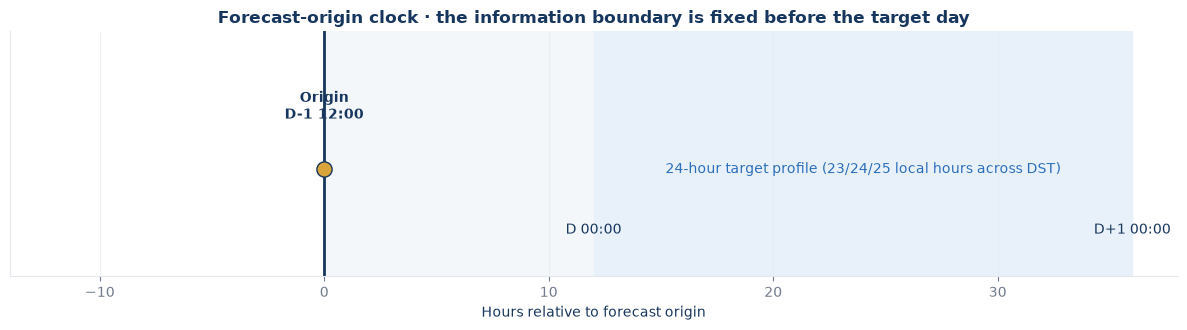

In [5]:
# -----------------------------------------------------------------
# Time semantics and forecast-origin integrity
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.axvspan(0, 12, color=COLORS["pale"], alpha=1.0, label="historical data continues to arrive")
ax.axvspan(12, 36, color="#E8F1FA", alpha=1.0, label="forecasted local day")
ax.axvline(0, color=COLORS["ink"], linewidth=2)
ax.scatter([0], [0.55], s=120, color=COLORS["gold"], edgecolor=COLORS["ink"], zorder=3)
ax.text(0, 0.7, "Origin\nD-1 12:00", ha="center", va="bottom", fontweight="bold")
ax.text(12, 0.34, "D 00:00", ha="center")
ax.text(36, 0.34, "D+1 00:00", ha="center")
ax.annotate("24-hour target profile (23/24/25 local hours across DST)",
            xy=(24, 0.55), ha="center", va="center", color=COLORS["blue"])
ax.set(xlim=(-14, 38), ylim=(0.2, 1.0), xlabel="Hours relative to forecast origin", yticks=[])
ax.set_title("Forecast-origin clock · the information boundary is fixed before the target day")
finish_figure(fig, "forecast_origin_clock", "When must every feature be known?")

## 2. Block 1 — Trusted SMARD data foundation (2019–2026)

### Question

**What part of the 2019–2026 record is genuinely observed and trustworthy enough to support
temporal feature discovery?**

The requested research window is the half-open **Europe/Berlin calendar interval**
`2019-01-01 00:00 ≤ local time < 2027-01-01 00:00`, converted once to unambiguous UTC boundaries.
The actual source endpoint is reported rather than padded: if 2026 is partial, later months remain
**not observed**, not zero and not synthetic. Physical intervals are stored in canonical UTC;
Europe/Berlin local time is derived for calendar meaning and DST-aware daily support.

Before proposing a feature, this block asks for four pieces of evidence:

1. Are timestamps unique, ordered, and on a defensible 15- or 60-minute cadence?
2. Where are timestamps or physical values genuinely missing?
3. How closely does the source residual agree with the project's transparent accounting definition?
4. Do the series look physically plausible on one bounded, uninterrupted seven-day window?

No interpolation, forward filling, live API call, or synthetic fallback is allowed. **No harmonic,
lag, holiday, weather, or event feature is engineered in this block.** Human-readable columns from
the attached SMARD chart-data schema and canonical `_mw` columns are admitted as MW; any other schema
must declare `GRIDSTRESS_SOURCE_UNIT=MW` or `MWh_per_interval` explicitly.


### Resolve and normalize one source · 1/2

Input: the selected CSV and its declared schema. Output: sorted, unique UTC observations and a schema/unit audit. No source values are silently repaired.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [6]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def resolve_smard_csv() -> Path:
    """Use the declared file only. Never search sibling repositories or fabricate data."""
    configured = os.environ.get("GRIDSTRESS_SMARD_CSV")
    selected = Path(configured).expanduser() if configured else SMARD_CSV_PATH.expanduser()
    selected = selected.resolve()
    if not selected.is_file():
        raise FileNotFoundError(
            f"SMARD input is not a readable file: {selected}\n"
            "Set SMARD_CSV_PATH in Setup, or GRIDSTRESS_SMARD_CSV in the kernel environment. "
            "No network download, cross-repository auto-selection or synthetic fallback occurs.")
    return selected

### Resolve and normalize one source · 2/2

Input: the selected CSV and its declared schema. Output: sorted, unique UTC observations and a schema/unit audit. No source values are silently repaired.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [7]:
# -----------------------------------------------------------------
# Dependencies and reproducible environment
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def normalized_label(value: object) -> str:
    return "".join(character for character in str(value).lower() if character.isalnum())


def normalize_smard_schema(raw_frame: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Normalize known SMARD schemas while preserving source and identity residuals."""
    frame = raw_frame.copy()
    lookup: dict[str, str] = {}
    for column in frame.columns:
        key = normalized_label(column)
        if key in lookup:
            raise ValueError(f"Ambiguous normalized column label: {column!r} and {lookup[key]!r}")
        lookup[key] = column


# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
    def pick(*aliases: str) -> str | None:
        return next(
            (lookup[normalized_label(alias)] for alias in aliases
             if normalized_label(alias) in lookup),
            None,
        )

    timestamp_column = pick(
        "event_time_utc", "timestamp_utc", "timestamp", "datetime", "date_time", "Unnamed: 0"
    )
    if timestamp_column is None:
        raise ValueError("No timestamp column found; expected timestamp_utc or event_time_utc.")

    source_mapping = {
        "load_mw": pick("load_mw", "Grid Load", "grid_load", "load"),
        "wind_onshore_mw": pick("wind_onshore_mw", "Wind Onshore", "wind_onshore"),
        "wind_offshore_mw": pick("wind_offshore_mw", "Wind Offshore", "wind_offshore"),
        "solar_mw": pick("solar_mw", "Solar", "solar_generation"),
        "residual_load_source_mw": pick(
            "residual_load_source_mw", "residual_load_smard_mw", "Residual Load (SMARD)",
            "residual_load_mw", "Residual Load", "residual_load"
        ),
    }
    primitive_columns = [
        "load_mw", "wind_onshore_mw", "wind_offshore_mw", "solar_mw"
    ]
    missing_primitives = [name for name in primitive_columns if source_mapping[name] is None]
    if missing_primitives:
        raise ValueError(f"Missing primitive SMARD columns: {missing_primitives}")

    timestamp_name_is_utc = "utc" in normalized_label(timestamp_column)
    timestamp_text = frame[timestamp_column].dropna().astype(str).str.strip()
    timestamp_values_have_offsets = bool(
        len(timestamp_text)
        and timestamp_text.str.contains(r"(?:Z|[+-]\d{2}:?\d{2})$", regex=True).all()
    )
    source_timezone = os.environ.get("GRIDSTRESS_SOURCE_TIMEZONE")
    if timestamp_name_is_utc or timestamp_values_have_offsets:
        parsed_timestamp = pd.to_datetime(
            frame[timestamp_column], utc=True, errors="coerce", format="mixed"
        )
        timestamp_semantics = (
            "column explicitly labelled UTC" if timestamp_name_is_utc
            else "every timestamp carries an explicit UTC offset"
        )
    elif source_timezone:
        naive_timestamp = pd.to_datetime(
            frame[timestamp_column], errors="coerce", format="mixed"
        )
        try:
            parsed_timestamp = (
                naive_timestamp.dt.tz_localize(
                    source_timezone, ambiguous="raise", nonexistent="raise"
                ).dt.tz_convert("UTC")
            )
        except (TypeError, ValueError) as error:
            raise ValueError(
                "Could not localize the naive timestamp column safely. Supply offset-bearing "
                "timestamps or repair DST ambiguity upstream."
            ) from error
        timestamp_semantics = f"naive source explicitly localized from {source_timezone}"
    else:
        raise ValueError(
            f"Timestamp column {timestamp_column!r} is neither UTC-labelled nor offset-bearing. "
            "Set GRIDSTRESS_SOURCE_TIMEZONE only after verifying its source timezone."
        )

    # pandas 3 may parse strings to microseconds. Normalize once so joins,
    # equality tests and downstream kernels share an explicit resolution.
    parsed_timestamp = parsed_timestamp.dt.as_unit("ns")
    invalid_timestamps = int(parsed_timestamp.isna().sum())
    duplicate_timestamps = int(parsed_timestamp.dropna().duplicated(keep=False).sum())
    if invalid_timestamps:
        raise ValueError(f"Input contains {invalid_timestamps} invalid timestamps; repair upstream.")
    if duplicate_timestamps:
        raise ValueError(
            f"Input contains {duplicate_timestamps} rows on duplicated UTC timestamps; repair upstream."
        )

    ordered_timestamps = parsed_timestamp.sort_values().reset_index(drop=True)
    source_delta_minutes = ordered_timestamps.diff().dt.total_seconds().div(60).dropna()
    positive_source_deltas = source_delta_minutes.loc[source_delta_minutes > 0]
    if positive_source_deltas.empty:
        raise ValueError("At least two distinct timestamps are required to infer source cadence.")
    source_cadence_value = float(positive_source_deltas.mode().iloc[0])
    if not np.isclose(source_cadence_value, round(source_cadence_value), rtol=0, atol=1e-9):
        raise ValueError(f"Source cadence is not a whole minute: {source_cadence_value}")
    source_cadence_minutes = int(round(source_cadence_value))
    if source_cadence_minutes not in {15, 60}:
        raise ValueError(
            f"Expected 15- or 60-minute source cadence; modal cadence is {source_cadence_minutes}."
        )
    aligned_to_grid = (
        parsed_timestamp.dt.second.eq(0)
        & parsed_timestamp.dt.microsecond.eq(0)
        & parsed_timestamp.dt.nanosecond.eq(0)
        & parsed_timestamp.dt.minute.mod(source_cadence_minutes).eq(0)
    )
    if not aligned_to_grid.all():
        raise ValueError(
            f"Source timestamps are not aligned to the UTC {source_cadence_minutes}-minute grid."
        )

    configured_unit = os.environ.get("GRIDSTRESS_SOURCE_UNIT")
    verified_human_mw_columns = {"Grid Load", "Wind Onshore", "Wind Offshore", "Solar"}
    primitive_source_columns = {source_mapping[name] for name in primitive_columns}
    canonical_mw_columns = all(
        normalized_label(source_mapping[name]).endswith("mw") for name in primitive_columns
    )
    if configured_unit:
        source_unit = configured_unit
        unit_evidence = "GRIDSTRESS_SOURCE_UNIT"
    elif primitive_source_columns == verified_human_mw_columns:
        source_unit = "MW"
        unit_evidence = "declared human-readable SMARD chart schema; verify against extract metadata"
    elif canonical_mw_columns:
        source_unit = "MW"
        unit_evidence = "canonical _mw column names"
    else:
        raise ValueError(
            "Source unit is not explicit. Set GRIDSTRESS_SOURCE_UNIT to MW or MWh_per_interval."
        )
    if source_unit not in {"MW", "MWh_per_interval"}:
        raise ValueError("GRIDSTRESS_SOURCE_UNIT must be MW or MWh_per_interval.")
    unit_conversion_to_mw = 1.0 if source_unit == "MW" else 60.0 / source_cadence_minutes

    normalized = pd.DataFrame({"event_time_utc": parsed_timestamp})
    numeric_coercion_failures: dict[str, int] = {}
    for canonical, source in source_mapping.items():
        if source is None:
            normalized[canonical] = np.nan
            numeric_coercion_failures[canonical] = 0
            continue
        converted = pd.to_numeric(frame[source], errors="coerce")
        numeric_coercion_failures[canonical] = int(
            frame[source].notna().sum() - converted.notna().sum()
        )
        nonfinite = converted.notna() & ~np.isfinite(converted)
        if nonfinite.any():
            raise ValueError(
                f"Column {source!r} contains {int(nonfinite.sum())} non-finite numeric values."
            )
        normalized[canonical] = converted * unit_conversion_to_mw

    negative_counts = {
        column: int((normalized[column] < 0).sum()) for column in primitive_columns
    }
    if any(negative_counts.values()):
        raise ValueError(f"Negative primitive power values found: {negative_counts}")

    normalized["residual_load_identity_mw"] = (
        normalized["load_mw"]
        - normalized["wind_onshore_mw"]
        - normalized["wind_offshore_mw"]
        - normalized["solar_mw"]
    )
    # The transparent project accounting definition is the analysis target. The source

# -----------------------------------------------------------------
# Validation and scientific safeguards
# -----------------------------------------------------------------
    # residual remains separate so disagreement can be audited rather than hidden.
    normalized["residual_load_mw"] = normalized["residual_load_identity_mw"]
    normalized = normalized.sort_values("event_time_utc").reset_index(drop=True)

    audit = {
        "raw_rows": int(len(frame)),
        "timestamp_column": timestamp_column,
        "timestamp_semantics": timestamp_semantics,
        "source_mapping": source_mapping,
        "source_unit": source_unit,
        "unit_evidence": unit_evidence,
        "unit_conversion_to_mw": unit_conversion_to_mw,
        "source_cadence_minutes": source_cadence_minutes,
        "source_residual_provenance": (
            "explicit SMARD-labelled source series"
            if source_mapping["residual_load_source_mw"] is not None
            and normalized_label(source_mapping["residual_load_source_mw"]) == "residualloadsmard"
            else "unverified source residual column"
            if source_mapping["residual_load_source_mw"] is not None
            else "unavailable"
        ),
        "invalid_timestamp_rows": invalid_timestamps,
        "duplicate_timestamp_rows": duplicate_timestamps,
        "numeric_coercion_failures": numeric_coercion_failures,
        "negative_primitive_counts": negative_counts,
    }
    return normalized, audit

### Apply the calendar envelope and infer cadence

Requested coverage and observed support are reported separately. A missing interval is not the same as a timestamp off the cadence grid.

In [8]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
WINDOW_START_LOCAL = pd.Timestamp("2019-01-01", tz=BERLIN)
WINDOW_END_LOCAL_EXCLUSIVE = pd.Timestamp("2027-01-01", tz=BERLIN)
WINDOW_START_UTC = WINDOW_START_LOCAL.tz_convert("UTC")
WINDOW_END_UTC_EXCLUSIVE = WINDOW_END_LOCAL_EXCLUSIVE.tz_convert("UTC")

DATA_PATH = resolve_smard_csv()
raw = pd.read_csv(DATA_PATH)
normalized_observations, input_schema_audit = normalize_smard_schema(raw)

window_mask = normalized_observations["event_time_utc"].between(
    WINDOW_START_UTC,
    WINDOW_END_UTC_EXCLUSIVE,
    inclusive="left",
)
observations = normalized_observations.loc[window_mask].copy().reset_index(drop=True)
rows_outside_window = int((~window_mask).sum())
if len(observations) < 2:
    raise ValueError(
        "The requested 2019–2026 Berlin-local calendar window contains fewer than two observations; "
        "cadence cannot be inferred."
    )

delta_minutes = (
    observations["event_time_utc"].diff().dt.total_seconds().div(60).dropna()
)
positive_delta_minutes = delta_minutes.loc[delta_minutes > 0]
if positive_delta_minutes.empty:
    raise ValueError("No positive timestamp deltas remain after sorting.")
CADENCE_MINUTES = int(round(float(positive_delta_minutes.mode().iloc[0])))
if CADENCE_MINUTES not in {15, 60}:
    raise ValueError(
        f"Expected a 15- or 60-minute cadence; modal cadence is {CADENCE_MINUTES} minutes."
    )
if CADENCE_MINUTES != input_schema_audit["source_cadence_minutes"]:
    raise ValueError("Cadence changed after applying the research window; inspect the source.")
PERIODS_PER_HOUR = 60 // CADENCE_MINUTES
cadence_delta = pd.Timedelta(minutes=CADENCE_MINUTES)

actual_data_start_utc = observations["event_time_utc"].min()
actual_data_end_utc = observations["event_time_utc"].max()
expected_envelope = pd.date_range(
    actual_data_start_utc,
    actual_data_end_utc,
    freq=f"{CADENCE_MINUTES}min",
)
observed_index = pd.DatetimeIndex(observations["event_time_utc"])
missing_interval_count = int(len(expected_envelope.difference(observed_index)))
delta_as_cadence_units = positive_delta_minutes / CADENCE_MINUTES
irregular_delta_count = int(
    (~np.isclose(delta_as_cadence_units, np.round(delta_as_cadence_units))).sum()
)

observations["event_time_local"] = observations["event_time_utc"].dt.tz_convert(TZ_NAME)
observations["target_date_local"] = pd.to_datetime(
    observations["event_time_local"].dt.date
)
DATA_MODE = "SYNTHETIC_VALIDATION_FIXTURE" if VALIDATION_FIXTURE else "REAL_INPUT"

print("Reading:", DATA_PATH)
print("Requested local calendar window:", WINDOW_START_LOCAL, "→", WINDOW_END_LOCAL_EXCLUSIVE, "(exclusive)")
print("Equivalent UTC boundaries:      ", WINDOW_START_UTC, "→", WINDOW_END_UTC_EXCLUSIVE)
print("Actual UTC support:  ", actual_data_start_utc, "→", actual_data_end_utc)
print(
    "Rows:", f"{len(observations):,}",
    "· cadence:", f"{CADENCE_MINUTES} minutes",
    "· missing physical intervals inside actual envelope:", missing_interval_count,
)
print("Rows outside requested window excluded:", rows_outside_window)
print(
    "Source unit:", input_schema_audit["source_unit"],
    "→ MW factor", input_schema_audit["unit_conversion_to_mw"],
    "· evidence:", input_schema_audit["unit_evidence"],
)
year_2026_start = pd.Timestamp("2026-01-01", tz=BERLIN).tz_convert("UTC")
year_2026_expected = pd.date_range(year_2026_start, WINDOW_END_UTC_EXCLUSIVE,
                                  freq=f"{CADENCE_MINUTES}min", inclusive="left").as_unit("ns")
year_2026_observed = observed_index[(observed_index >= year_2026_start) & (observed_index < WINDOW_END_UTC_EXCLUSIVE)]
year_2026_missing = len(year_2026_expected.difference(year_2026_observed))
coverage_status_2026 = "not observed" if len(year_2026_observed) == 0 else ("complete timestamps" if year_2026_missing == 0 else "partial timestamps")
print("2026 status:", coverage_status_2026, "— value completeness is audited separately below")

Reading: /Users/hari/UniProjects/Team-CapStone/gridstress-v2/research/data/smard_hourly_2019_2026-09-10.csv
Requested local calendar window: 2019-01-01 00:00:00+01:00 → 2027-01-01 00:00:00+01:00 (exclusive)
Equivalent UTC boundaries:       2018-12-31 23:00:00+00:00 → 2026-12-31 23:00:00+00:00
Actual UTC support:   2018-12-31 23:00:00+00:00 → 2026-09-09 21:00:00+00:00
Rows: 67,415 · cadence: 60 minutes · missing physical intervals inside actual envelope: 0
Rows outside requested window excluded: 0
Source unit: MW → MW factor 1.0 · evidence: declared human-readable SMARD chart schema; verify against extract metadata
2026 status: partial timestamps — value completeness is audited separately below


### Audit time support and physical accounting · 1/4

UTC defines physical durations; Berlin dates define forecast profiles. Completeness requires the exact expected grid and finite primitive values.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [9]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def expected_local_day_steps(day: date, cadence_minutes: int) -> int:
    start = pd.Timestamp(datetime.combine(day, clock_time(0), tzinfo=BERLIN))
    end = pd.Timestamp(datetime.combine(day + timedelta(days=1), clock_time(0), tzinfo=BERLIN))
    elapsed_minutes = (
        end.tz_convert("UTC") - start.tz_convert("UTC")
    ).total_seconds() / 60
    return int(round(elapsed_minutes / cadence_minutes))


def expected_utc_grid(day: date, cadence_minutes: int) -> pd.DatetimeIndex:
    start = pd.Timestamp(datetime.combine(day, clock_time(0), tzinfo=BERLIN)).tz_convert("UTC")
    end = pd.Timestamp(datetime.combine(day + timedelta(days=1), clock_time(0), tzinfo=BERLIN)).tz_convert("UTC")
    return pd.date_range(start, end, freq=f"{cadence_minutes}min", inclusive="left").as_unit("ns")



# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def exact_time_lag(values: pd.Series, times: pd.Series, hours: int) -> np.ndarray:
    """Exact UTC lookup. A missing t-h stays missing; duplicate keys are rejected."""
    index = pd.DatetimeIndex(utc_series(times, "lag timestamps"))
    if index.has_duplicates or len(values) != len(index):
        raise ValueError("Exact time lags require aligned values and unique timestamps.")
    if hours <= 0:
        raise ValueError("Lag duration must be positive.")
    lookup = pd.Series(np.asarray(values), index=index)
    return lookup.reindex(index - pd.Timedelta(hours=hours)).to_numpy()


def exact_time_delta(values: pd.Series, times: pd.Series, hours: int = 1) -> np.ndarray:
    current = np.asarray(values, dtype=float).reshape(-1)
    previous = np.asarray(exact_time_lag(values, times, hours), dtype=float).reshape(-1)
    return current - previous



# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def local_profile_lag(values: pd.Series, times: pd.Series, days: int) -> np.ndarray:
    utc_times = pd.DatetimeIndex(pd.to_datetime(times, utc=True))
    local_times = utc_times.tz_convert(TZ_NAME)
    local_dates = pd.to_datetime(local_times.date)
    minute_of_day = local_times.hour * 60 + local_times.minute
    keys = pd.DataFrame({"local_date": local_dates, "minute_of_day": minute_of_day})
    keys["occurrence"] = keys.groupby(["local_date", "minute_of_day"]).cumcount()
    lookup = pd.Series(list(values), index=pd.MultiIndex.from_frame(keys))
    requested = keys.copy()
    requested["local_date"] = requested["local_date"] - pd.to_timedelta(days, unit="D")
    return lookup.reindex(pd.MultiIndex.from_frame(requested)).to_numpy()

### Audit time support and physical accounting · 2/4

UTC defines physical durations; Berlin dates define forecast profiles. Completeness requires the exact expected grid and finite primitive values.

In [10]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
identity = observations["residual_load_identity_mw"]
identity_gap = (
    observations["residual_load_source_mw"] - observations["residual_load_identity_mw"]
).abs()
identity_comparison = identity_gap.dropna()

required_values = [
    "load_mw", "wind_onshore_mw", "wind_offshore_mw", "solar_mw", "residual_load_mw"
]
support_rows = []
local_date_start = observations["event_time_local"].min().date()
local_date_end = observations["event_time_local"].max().date()
all_local_dates = pd.date_range(local_date_start, local_date_end, freq="D")
for target_day in all_local_dates:
    group = observations.loc[observations["target_date_local"].eq(target_day)]
    expected_grid = expected_utc_grid(target_day.date(), CADENCE_MINUTES)
    observed_grid = pd.DatetimeIndex(group["event_time_utc"].sort_values()).as_unit("ns")
    exact_grid = observed_grid.equals(expected_grid)
    joint_valid_steps = int(group[required_values].notna().all(axis=1).sum())
    support_rows.append({
        "target_date_local": pd.Timestamp(target_day),
        "observed_steps": int(len(observed_grid)),
        "joint_valid_steps": joint_valid_steps,
        "expected_steps": int(len(expected_grid)),
        "timestamp_coverage": len(observed_grid) / len(expected_grid),
        "joint_valid_coverage": joint_valid_steps / len(expected_grid),
        "exact_utc_grid": bool(exact_grid),
        "complete_day": bool(exact_grid and joint_valid_steps == len(expected_grid)),
    })
daily_support = pd.DataFrame(support_rows)
eligible_target_dates = set(
    daily_support.loc[daily_support["complete_day"], "target_date_local"]
)

### Audit time support and physical accounting · 3/4

UTC defines physical durations; Berlin dates define forecast profiles. Completeness requires the exact expected grid and finite primitive values.

In [11]:
# -----------------------------------------------------------------
# Time semantics and forecast-origin integrity
# -----------------------------------------------------------------
monthly_rows = []
for year in range(2019, 2027):
    for month in range(1, 13):
        month_start_local = pd.Timestamp(year=year, month=month, day=1, tz=BERLIN)
        month_end_local = month_start_local + pd.DateOffset(months=1)
        month_start_utc = month_start_local.tz_convert("UTC")
        month_end_utc = month_end_local.tz_convert("UTC")
        expected_month_grid = pd.date_range(
            month_start_utc,
            month_end_utc,
            freq=f"{CADENCE_MINUTES}min",
            inclusive="left",
        )
        month_group = observations.loc[
            observations["event_time_local"].dt.year.eq(year)
            & observations["event_time_local"].dt.month.eq(month)
        ]
        month_observed_grid = pd.DatetimeIndex(month_group["event_time_utc"])
        on_grid_mask = month_group["event_time_utc"].isin(expected_month_grid)
        observed_steps = int(len(expected_month_grid.intersection(month_observed_grid)))
        source_rows_in_month = int(len(month_group))
        extra_timestamp_steps = int(len(month_observed_grid.difference(expected_month_grid)))
        joint_valid_steps = int(
            (on_grid_mask & month_group[required_values].notna().all(axis=1)).sum()
        )
        overlaps_actual_envelope = (
            month_end_utc > actual_data_start_utc
            and month_start_utc <= actual_data_end_utc
        )
        if not overlaps_actual_envelope:
            coverage_status = "not observed"
            timestamp_coverage = np.nan
            joint_valid_coverage = np.nan
            missing_timestamp_steps = np.nan
            missing_joint_valid_steps = np.nan
        else:
            timestamp_coverage = observed_steps / len(expected_month_grid)
            joint_valid_coverage = joint_valid_steps / len(expected_month_grid)
            missing_timestamp_steps = int(len(expected_month_grid) - observed_steps)
            missing_joint_valid_steps = int(len(expected_month_grid) - joint_valid_steps)
            if observed_steps == 0:
                coverage_status = "gap"
            elif observed_steps < len(expected_month_grid) or joint_valid_steps < len(expected_month_grid):
                coverage_status = "partial"
            else:
                coverage_status = "observed"
        monthly_rows.append({
            "year": year,
            "month": month,
            "expected_steps": int(len(expected_month_grid)),
            "source_rows_in_month": source_rows_in_month,
            "observed_steps": observed_steps,
            "joint_valid_steps": joint_valid_steps,
            "missing_timestamp_steps": missing_timestamp_steps,
            "missing_joint_valid_steps": missing_joint_valid_steps,
            "extra_timestamp_steps": extra_timestamp_steps,
            "timestamp_coverage": timestamp_coverage,
            "joint_valid_coverage": joint_valid_coverage,
            "coverage_status": coverage_status,
        })
monthly_coverage = pd.DataFrame(monthly_rows)

### Audit time support and physical accounting · 4/4

UTC defines physical durations; Berlin dates define forecast profiles. Completeness requires the exact expected grid and finite primitive values.

In [12]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
identity_available = not identity_comparison.empty
identity_comparison_share = float(identity_comparison.size / len(observations))
identity_comparison_start = (
    observations.loc[identity_gap.notna(), "event_time_utc"].min() if identity_available else pd.NaT
)
identity_comparison_end = (
    observations.loc[identity_gap.notna(), "event_time_utc"].max() if identity_available else pd.NaT
)
identity_median_gap = float(identity_comparison.median()) if identity_available else np.nan
identity_p95_gap = float(identity_comparison.quantile(0.95)) if identity_available else np.nan
identity_max_gap = float(identity_comparison.max()) if identity_available else np.nan

data_quality = pd.DataFrame([
    {"check": "Unique UTC timestamps", "value": observations["event_time_utc"].is_unique,
     "status": "PASS" if observations["event_time_utc"].is_unique else "FAIL"},
    {"check": "Monotonic UTC timestamps", "value": observations["event_time_utc"].is_monotonic_increasing,
     "status": "PASS" if observations["event_time_utc"].is_monotonic_increasing else "FAIL"},
    {"check": "Cadence", "value": f"{CADENCE_MINUTES} minutes", "status": "PASS"},
    {"check": "Source unit admitted", "value": input_schema_audit["source_unit"], "status": "PASS"},
    {"check": "Missing physical intervals inside actual envelope", "value": missing_interval_count,
     "status": "REVIEW" if missing_interval_count else "PASS"},
    {"check": "Irregular non-cadence timestamp deltas", "value": irregular_delta_count,
     "status": "PASS" if irregular_delta_count == 0 else "FAIL"},
    {"check": "Source residual comparison rows", "value": int(len(identity_comparison)),
     "status": "INFORMATIONAL" if identity_available else "UNAVAILABLE"},
    {"check": "Source residual comparison coverage", "value": identity_comparison_share,
     "status": "INFORMATIONAL" if identity_available else "UNAVAILABLE"},
    {"check": "Accounting-definition median absolute gap (MW)", "value": identity_median_gap,
     "status": "INFORMATIONAL" if identity_available else "UNAVAILABLE"},
    {"check": "Accounting-definition P95 absolute gap (MW)", "value": identity_p95_gap,
     "status": "INFORMATIONAL" if identity_available else "UNAVAILABLE"},
    {"check": "Accounting-definition maximum absolute gap (MW)", "value": identity_max_gap,
     "status": "INFORMATIONAL" if identity_available else "UNAVAILABLE"},
])

data_foundation_summary = pd.DataFrame([
    {"item": "Requested local start (inclusive)", "value": WINDOW_START_LOCAL},
    {"item": "Requested local end (exclusive)", "value": WINDOW_END_LOCAL_EXCLUSIVE},
    {"item": "UTC boundary start", "value": WINDOW_START_UTC},
    {"item": "UTC boundary end (exclusive)", "value": WINDOW_END_UTC_EXCLUSIVE},
    {"item": "Actual observed UTC start", "value": actual_data_start_utc},
    {"item": "Actual observed UTC end", "value": actual_data_end_utc},
    {"item": "Observed source rows", "value": int(len(observations))},
    {"item": "Cadence (minutes)", "value": CADENCE_MINUTES},
    {"item": "Source unit", "value": input_schema_audit["source_unit"]},
    {"item": "Unit evidence", "value": input_schema_audit["unit_evidence"]},
    {"item": "Missing physical intervals in actual envelope", "value": missing_interval_count},
    {"item": "Complete Berlin-local days", "value": int(daily_support["complete_day"].sum())},
    {"item": "Incomplete Berlin-local days", "value": int((~daily_support["complete_day"]).sum())},
    {"item": "Source residual provenance", "value": input_schema_audit["source_residual_provenance"]},
    {"item": "Source residual comparison rows", "value": int(len(identity_comparison))},
    {"item": "Source residual comparison start", "value": identity_comparison_start},
    {"item": "Source residual comparison end", "value": identity_comparison_end},
])

quality_rows = []
for column in [
    "load_mw", "wind_onshore_mw", "wind_offshore_mw", "solar_mw",
    "residual_load_source_mw", "residual_load_identity_mw", "residual_load_mw",
]:
    series = observations[column]
    quality_rows.append({
        "column": column,
        "unit": "MW",
        "non_missing": int(series.notna().sum()),
        "missing": int(series.isna().sum()),
        "missing_share_pct": 100 * float(series.isna().mean()),
        "minimum": float(series.min()) if series.notna().any() else np.nan,
        "median": float(series.median()) if series.notna().any() else np.nan,
        "maximum": float(series.max()) if series.notna().any() else np.nan,
    })
column_quality = pd.DataFrame(quality_rows)

display(data_foundation_summary)
display(data_quality)
display(column_quality.round({"missing_share_pct": 3, "minimum": 1, "median": 1, "maximum": 1}))

incomplete_day_preview = daily_support.loc[
    ~daily_support["complete_day"],
    ["target_date_local", "observed_steps", "joint_valid_steps", "expected_steps",
     "timestamp_coverage", "joint_valid_coverage"],
].head(8)
if not incomplete_day_preview.empty:
    print("Bounded preview of incomplete local days (first 8):")
    display(incomplete_day_preview)

,item,value
0,Requested local start (inclusive),2019-01-01 00:00:00+01:00
1,Requested local end (exclusive),2027-01-01 00:00:00+01:00
2,UTC boundary start,2018-12-31 23:00:00+00:00
3,UTC boundary end (exclusive),2026-12-31 23:00:00+00:00
4,Actual observed UTC start,2018-12-31 23:00:00+00:00
5,Actual observed UTC end,2026-09-09 21:00:00+00:00
6,Observed source rows,67415
7,Cadence (minutes),60
8,Source unit,MW
9,Unit evidence,declared human-readable SMARD chart schema; ve...


,check,value,status
0,Unique UTC timestamps,True,PASS
1,Monotonic UTC timestamps,True,PASS
2,Cadence,60 minutes,PASS
3,Source unit admitted,MW,PASS
4,Missing physical intervals inside actual envelope,0,PASS
5,Irregular non-cadence timestamp deltas,0,PASS
6,Source residual comparison rows,67415,INFORMATIONAL
7,Source residual comparison coverage,1.0,INFORMATIONAL
8,Accounting-definition median absolute gap (MW),0.0,INFORMATIONAL
9,Accounting-definition P95 absolute gap (MW),0.01,INFORMATIONAL


,column,unit,non_missing,missing,missing_share_pct,minimum,median,maximum
0,load_mw,MW,67415,0,0.0,30902.8,54456.2,81319.5
1,wind_onshore_mw,MW,67415,0,0.0,46.5,9246.2,48499.5
2,wind_offshore_mw,MW,67415,0,0.0,0.0,2658.0,8448.3
3,solar_mw,MW,67415,0,0.0,0.0,237.5,58055.5
4,residual_load_source_mw,MW,67415,0,0.0,-15561.6,33914.2,74638.8
5,residual_load_identity_mw,MW,67415,0,0.0,-15561.6,33914.2,74638.8
6,residual_load_mw,MW,67415,0,0.0,-15561.6,33914.2,74638.8


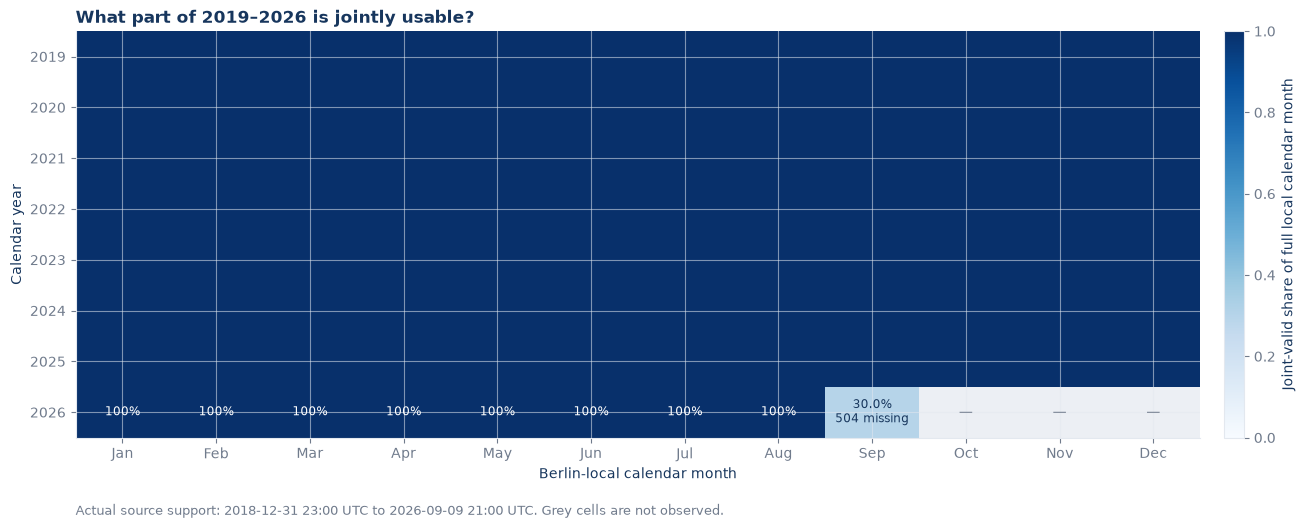

In [13]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------
### Question: where is the 2019–2026 record complete enough for temporal comparisons?

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def format_coverage_label(value: float, missing_steps: int) -> str:
    if missing_steps == 0 and np.isclose(value, 1.0):
        return "100%"
    percentage = 100 * value
    formatted = f"{percentage:.2f}%" if percentage >= 99 else f"{percentage:.1f}%"
    noun = "missing" if missing_steps == 1 else "missing"
    return f"{formatted}\n{missing_steps:,} {noun}"


coverage_matrix = (
    monthly_coverage.pivot(index="year", columns="month", values="joint_valid_coverage")
    .reindex(index=range(2019, 2027), columns=range(1, 13))
)
masked_coverage = np.ma.masked_invalid(coverage_matrix.to_numpy(dtype=float))
coverage_cmap = plt.get_cmap("Blues").copy()
coverage_cmap.set_bad("#ECEFF4")

fig, ax = plt.subplots(figsize=(13.2, 5.4))
image = ax.imshow(masked_coverage, aspect="auto", vmin=0, vmax=1, cmap=coverage_cmap)
ax.set_title("What part of 2019–2026 is jointly usable?", loc="left")
ax.set_xlabel("Berlin-local calendar month")
ax.set_ylabel("Calendar year")
ax.set_xticks(range(12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_yticks(range(8), [str(year) for year in range(2019, 2027)])

for row_index, year in enumerate(range(2019, 2027)):
    for column_index, month in enumerate(range(1, 13)):
        value = coverage_matrix.loc[year, month]
        coverage_row = monthly_coverage.loc[
            monthly_coverage["year"].eq(year) & monthly_coverage["month"].eq(month)
        ].iloc[0]
        if pd.isna(value):
            if year == 2026:
                ax.text(column_index, row_index, "—", ha="center", va="center", color=COLORS["muted"])
        elif int(coverage_row["missing_joint_valid_steps"]) > 0 or year == 2026:
            ax.text(
                column_index,
                row_index,
                format_coverage_label(
                    float(value), int(coverage_row["missing_joint_valid_steps"])
                ),
                ha="center",
                va="center",
                fontsize=8.5,
                color="white" if value > 0.62 else COLORS["ink"],
            )

colorbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
colorbar.set_label("Joint-valid share of full local calendar month")
ax.text(
    0,
    -0.19,
    f"Actual source support: {actual_data_start_utc:%Y-%m-%d %H:%M UTC} to "
    f"{actual_data_end_utc:%Y-%m-%d %H:%M UTC}. Grey cells are not observed.",
    transform=ax.transAxes,
    color=COLORS["muted"],
    fontsize=9.5,
)
finish_figure(
    fig,
    "data_foundation_coverage",
    "Where is the 2019–2026 record complete enough for temporal comparisons?",
)

### Inspect a continuous physical-data window

Inspect the stated units, time range and support before interpreting the resulting table or figure.

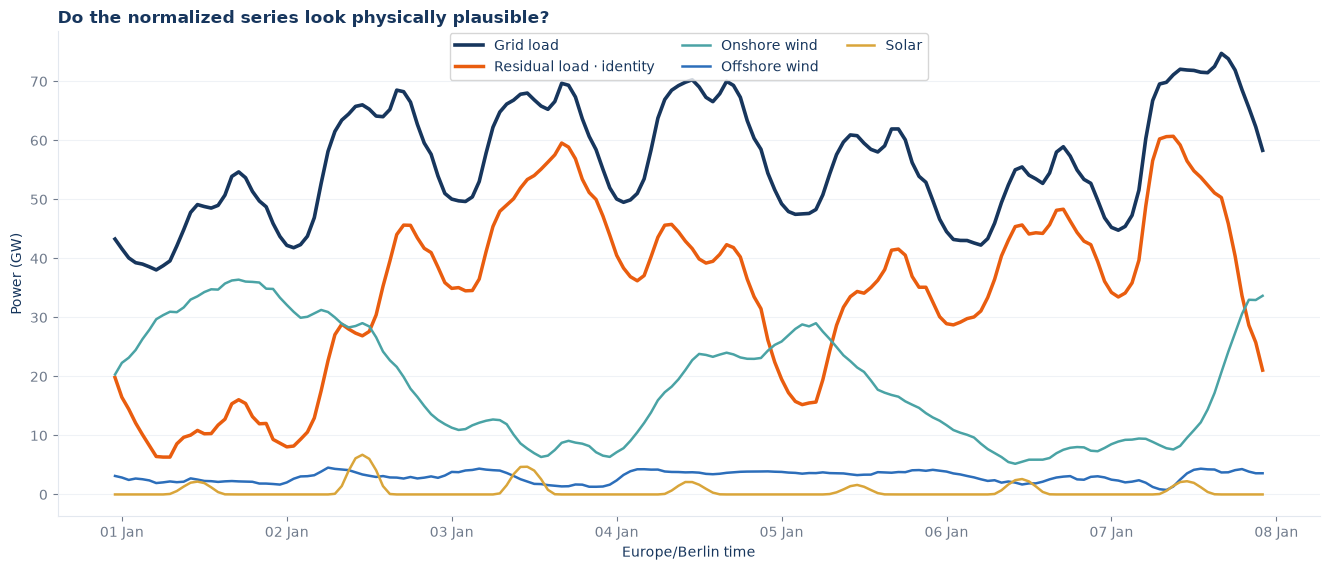

Physical preview uses 168 uninterrupted intervals; table bounded to 8 rows.


,event_time_utc,event_time_local,load_mw,wind_onshore_mw,wind_offshore_mw,solar_mw,residual_load_mw
0,2018-12-31 23:00:00+00:00,2019-01-01 00:00:00+01:00,43273.75,20314.25,3134.00,0.0,19825.50
1,2019-01-01 00:00:00+00:00,2019-01-01 01:00:00+01:00,41631.25,22297.25,2868.25,0.0,16465.75
2,2019-01-01 01:00:00+00:00,2019-01-01 02:00:00+01:00,40085.00,23168.50,2460.25,0.0,14456.25
3,2019-01-01 02:00:00+00:00,2019-01-01 03:00:00+01:00,39269.75,24471.75,2696.50,0.0,12101.50
4,2019-01-01 03:00:00+00:00,2019-01-01 04:00:00+01:00,39032.75,26320.50,2578.00,0.0,10134.25
5,2019-01-01 04:00:00+00:00,2019-01-01 05:00:00+01:00,38570.50,27898.00,2377.25,0.0,8295.25
6,2019-01-01 05:00:00+00:00,2019-01-01 06:00:00+01:00,38047.50,29688.75,1930.00,0.0,6428.75
7,2019-01-01 06:00:00+00:00,2019-01-01 07:00:00+01:00,38756.00,30381.00,2045.00,0.0,6330.00


In [14]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
# Question: do the normalized physical series look plausible on a bounded continuous window?
complete_physical_row = observations[required_values].notna().all(axis=1)
continues_previous = observations["event_time_utc"].diff().eq(cadence_delta)
run_break = (~complete_physical_row) | (~continues_previous)
run_id = run_break.cumsum()
valid_run_lengths = run_id.loc[complete_physical_row].value_counts()
if valid_run_lengths.empty:
    raise ValueError("No jointly valid physical interval is available for the preview.")
longest_run_id = valid_run_lengths.idxmax()
maximum_preview_points = 7 * 24 * PERIODS_PER_HOUR
physical_preview = observations.loc[
    complete_physical_row & run_id.eq(longest_run_id)
].head(maximum_preview_points).copy()
if len(physical_preview) < maximum_preview_points:
    raise ValueError("No uninterrupted jointly valid seven-day segment is available for preview.")

preview_local_time = physical_preview["event_time_local"]
fig, ax = plt.subplots(figsize=(13.4, 5.8))
series_style = [
    ("load_mw", "Grid load", COLORS["ink"], 2.6),
    ("residual_load_mw", "Residual load · identity", COLORS["orange"], 2.5),
    ("wind_onshore_mw", "Onshore wind", COLORS["teal"], 1.8),
    ("wind_offshore_mw", "Offshore wind", COLORS["blue"], 1.8),
    ("solar_mw", "Solar", COLORS["gold"], 1.8),
]
for column, label, color, width in series_style:
    ax.plot(
        preview_local_time,
        physical_preview[column] / 1_000,
        label=label,
        color=color,
        linewidth=width,
    )
ax.set_title("Do the normalized series look physically plausible?", loc="left")
ax.set_xlabel("Europe/Berlin time")
ax.set_ylabel("Power (GW)")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.01))
ax.grid(axis="x", visible=False)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
finish_figure(
    fig,
    "data_foundation_physical_trace",
    "Do load, wind, solar, and residual load look physically plausible on a continuous week?",
)

preview_table = physical_preview.loc[:, [
    "event_time_utc", "event_time_local", "load_mw", "wind_onshore_mw",
    "wind_offshore_mw", "solar_mw", "residual_load_mw",
]].head(8)
print(f"Physical preview uses {len(physical_preview):,} uninterrupted intervals; table bounded to 8 rows.")
display(preview_table)

### Check daylight-saving profiles and the residual identity

Inspect the stated units, time range and support before interpreting the resulting table or figure.

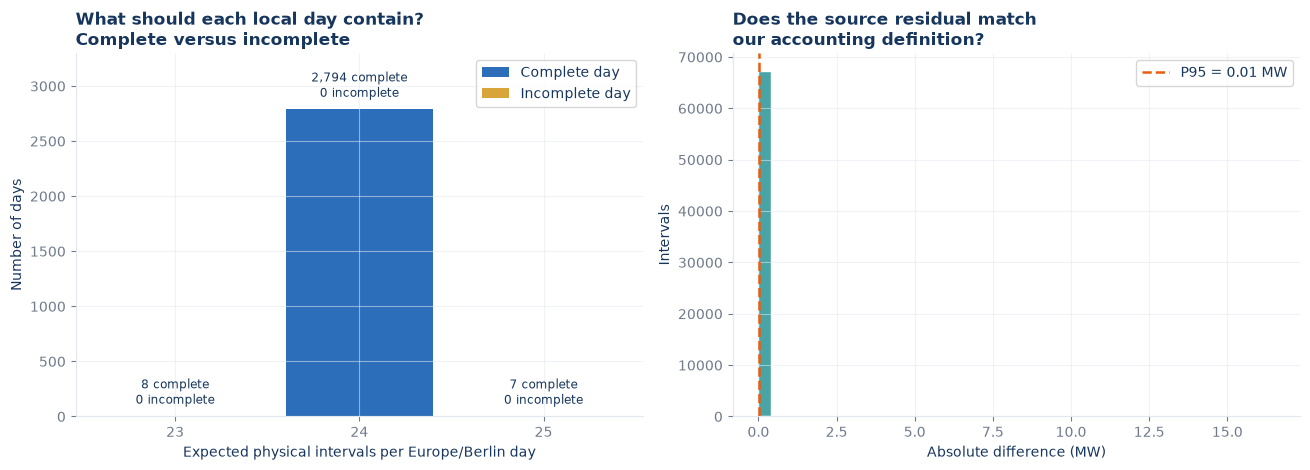

In [15]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
# Question: are DST day lengths and the residual-load identity represented honestly?
step_counts = (
    daily_support.groupby(["expected_steps", "complete_day"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[True, False], fill_value=0)
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))
axes[0].bar(
    step_counts.index.astype(str),
    step_counts[True],
    color=COLORS["blue"],
    label="Complete day",
)
axes[0].bar(
    step_counts.index.astype(str),
    step_counts[False],
    bottom=step_counts[True],
    color=COLORS["gold"],
    label="Incomplete day",
)
axes[0].set_title("What should each local day contain?\nComplete versus incomplete", loc="left")
axes[0].set_xlabel("Expected physical intervals per Europe/Berlin day")
axes[0].set_ylabel("Number of days")
axes[0].legend()
maximum_day_count = float(step_counts.sum(axis=1).max())
axes[0].set_ylim(0, maximum_day_count * 1.18)
for position, expected_steps in enumerate(step_counts.index):
    complete_count = int(step_counts.loc[expected_steps, True])
    incomplete_count = int(step_counts.loc[expected_steps, False])
    axes[0].text(
        position,
        complete_count + incomplete_count + max(3, maximum_day_count * 0.025),
        f"{complete_count:,} complete\n{incomplete_count:,} incomplete",
        ha="center",
        va="bottom",
        fontsize=8.5,
        color=COLORS["ink"],
    )

identity_plot_mode = (
    "unavailable" if not identity_available
    else "numerical_precision" if identity_max_gap < 1e-6
    else "distribution"
)
if identity_plot_mode == "distribution":
    axes[1].hist(
        identity_comparison,
        bins=40,
        color=COLORS["teal"],
        edgecolor="white",
    )
    axes[1].axvline(
        identity_p95_gap,
        color=COLORS["orange"],
        linestyle="--",
        linewidth=1.8,
        label=f"P95 = {identity_p95_gap:,.2f} MW",
    )
    axes[1].legend()
elif identity_plot_mode == "numerical_precision":
    axes[1].text(
        0.5,
        0.5,
        f"Agreement is within numerical precision\n{len(identity_comparison):,} compared intervals",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
        color=COLORS["ink"],
        fontsize=11,
    )
    axes[1].set_xticks([])
    axes[1].set_yticks([])
else:
    axes[1].text(
        0.5,
        0.5,
        "Source residual unavailable\ncomparison not fabricated",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
        color=COLORS["muted"],
    )
axes[1].set_title("Does the source residual match\nour accounting definition?", loc="left")
if identity_plot_mode == "numerical_precision":
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")
else:
    axes[1].set_xlabel("Absolute difference (MW)")
    axes[1].set_ylabel("Intervals")
finish_figure(
    fig,
    "data_and_dst_audit",
    "Are DST day lengths and the residual-load accounting definition represented honestly?",
)

### Evidence → feature decision

| Evidence from Block 1 | Implication | Feature decision |
|---|---|---|
| Physical intervals are identified in UTC | A timestamp must represent one unambiguous grid interval | Keep `event_time_utc` as the canonical key; it is structural, not a predictor |
| Berlin-local days can contain 23, 24 or 25 hours | Human calendar effects and physical lags are different concepts | Derive civil-clock features locally; calculate physical windows in UTC |
| Missing timestamps and measurements are visible | Filling would invent evidence and distort spectral estimates | Keep gaps missing; reject incomplete spectral windows |
| Residual load is reconstructed from load, wind and solar | Component relations are partly mechanical | Model the transparent identity target; label component association accordingly |
| 2026 may end before December | It is not a complete comparison year | Report the endpoint; never create future rows or call missing months zero |

### Rule for every next block

Each family follows: **question → EDA evidence → repeatability → representation → forecast honesty →
decision**. Recurring calendar states may be candidates. Sparse scheduled events need support tests.
Named shocks begin as intervention/adaptation terms or robustness slices. Target-defined states,
centered windows, full-series FFT coefficients, and retrospectively discovered boundaries are blocked.

**Block 1 decision:** the foundation is fit for feature materialization. The sequel now tests whether
the upstream hypotheses survive the origin boundary and chronological folds.


## 3. Stress-label design

Labels are outcomes, never predictors. Thresholds are frozen from a required early reference window
ending 2020-12-31. If that pre-validation reference is unavailable, execution fails rather than
borrowing outcomes from a validation period. The interval labels are
deliberately multi-label: high, low, negative, extreme ramp-up, and extreme ramp-down. Compound means a level-tail state and a ramp-tail state occur together; nested low + negative labels do not count as two independent mechanisms.
Daily labels aggregate `any`, onset, count, longest run, duration, severity, and exceedance area—never
the arbitrary first interval of the day. These labels define operational stress for model evaluation;
they are not causal claims.


### Freeze labels and define scored target days · 1/3

The pre-2021 reference freezes study labels. Only complete observed target days with exact one-hour ramps enter scoring. Labels are outcomes, never direct model inputs.

In [16]:
# -----------------------------------------------------------------
# Dependencies and reproducible environment
# -----------------------------------------------------------------
reference_cutoff_exclusive = pd.Timestamp("2021-01-01", tz=BERLIN).tz_convert("UTC")
reference = observations.loc[
    (observations["event_time_utc"] < reference_cutoff_exclusive)
    & observations["target_date_local"].isin(eligible_target_dates)
    & observations["residual_load_mw"].notna()
].copy()
minimum_reference_rows = 365 * 24 * PERIODS_PER_HOUR
if len(reference) < minimum_reference_rows:
    raise ValueError(
        "The frozen pre-2021 stress-label reference is unavailable. "
        "Do not estimate thresholds from validation outcomes."
    )
reference["ramp_1h_mw"] = exact_time_delta(
    reference["residual_load_mw"], reference["event_time_utc"], hours=1
)
reference_ramp_complete = reference.groupby("target_date_local")["ramp_1h_mw"].apply(
    lambda values: bool(values.notna().all())
)
reference = reference.loc[
    reference["target_date_local"].isin(
        set(reference_ramp_complete.loc[reference_ramp_complete].index)
    )
].copy()
if len(reference) < minimum_reference_rows:
    raise ValueError("Too few complete, exact-ramp reference rows before 2021.")
STRESS_THRESHOLDS = {
    "residual_p05_mw": float(reference["residual_load_mw"].quantile(0.05)),
    "residual_p25_mw": float(reference["residual_load_mw"].quantile(0.25)),
    "residual_p75_mw": float(reference["residual_load_mw"].quantile(0.75)),
    "residual_p95_mw": float(reference["residual_load_mw"].quantile(0.95)),
    "ramp_p05_mw_per_h": float(reference["ramp_1h_mw"].quantile(0.05)),
    "ramp_p95_mw_per_h": float(reference["ramp_1h_mw"].quantile(0.95)),
    "reference_start_utc": str(reference["event_time_utc"].min()),
    "reference_end_utc": str(reference["event_time_utc"].max()),
}

### Freeze labels and define scored target days · 2/3

The pre-2021 reference freezes study labels. Only complete observed target days with exact one-hour ramps enter scoring. Labels are outcomes, never direct model inputs.

In [17]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
labeled = observations.copy()
labeled["ramp_1h_mw"] = exact_time_delta(
    labeled["residual_load_mw"], labeled["event_time_utc"], hours=1
)
labeled["stress_high"] = labeled["residual_load_mw"] > STRESS_THRESHOLDS["residual_p95_mw"]
labeled["stress_low"] = labeled["residual_load_mw"] < STRESS_THRESHOLDS["residual_p05_mw"]
labeled["stress_negative"] = labeled["residual_load_mw"] < 0
labeled["stress_ramp_up"] = labeled["ramp_1h_mw"] > STRESS_THRESHOLDS["ramp_p95_mw_per_h"]
labeled["stress_ramp_down"] = labeled["ramp_1h_mw"] < STRESS_THRESHOLDS["ramp_p05_mw_per_h"]
label_columns = ["stress_high", "stress_low", "stress_negative", "stress_ramp_up", "stress_ramp_down"]
labeled["stress_any"] = labeled[label_columns].any(axis=1)
level_stress = labeled[["stress_high", "stress_low", "stress_negative"]].any(axis=1)
ramp_stress = labeled[["stress_ramp_up", "stress_ramp_down"]].any(axis=1)
labeled["stress_compound"] = level_stress & ramp_stress

high_excess = (labeled["residual_load_mw"] - STRESS_THRESHOLDS["residual_p95_mw"]).clip(lower=0)
low_excess = (STRESS_THRESHOLDS["residual_p05_mw"] - labeled["residual_load_mw"]).clip(lower=0)
labeled["stress_severity_mw"] = high_excess + low_excess
target_value_columns = [
    "load_mw", "wind_onshore_mw", "wind_offshore_mw", "solar_mw", "residual_load_mw"
]
ramp_complete_by_day = labeled.groupby("target_date_local")["ramp_1h_mw"].apply(
    lambda values: bool(values.notna().all())
)
ramp_complete_dates = set(ramp_complete_by_day.loc[ramp_complete_by_day].index)
scored_target_dates = eligible_target_dates.intersection(ramp_complete_dates)
scored_labeled = labeled.loc[
    labeled["target_date_local"].isin(scored_target_dates)
    & labeled[target_value_columns].notna().all(axis=1)
    & labeled["ramp_1h_mw"].notna()
].copy()
if scored_labeled[label_columns].isna().any().any():
    raise AssertionError("Scored stress labels contain unknown outcomes.")
target_population_audit = pd.DataFrame([
    {"population": "raw intervals", "rows": len(labeled)},
    {"population": "complete-day + exact-ramp scored intervals", "rows": len(scored_labeled)},
    {"population": "excluded intervals", "rows": len(labeled) - len(scored_labeled)},
])
display(target_population_audit)

,population,rows
0,raw intervals,67415
1,complete-day + exact-ramp scored intervals,67391
2,excluded intervals,24


### Freeze labels and define scored target days · 3/3

The pre-2021 reference freezes study labels. Only complete observed target days with exact one-hour ramps enter scoring. Labels are outcomes, never direct model inputs.

In [18]:
# -----------------------------------------------------------------
# Time semantics and forecast-origin integrity
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def longest_true_run(values: pd.Series) -> int:
    array = values.fillna(False).astype(bool).to_numpy()
    best = current = 0
    for item in array:
        current = current + 1 if item else 0
        best = max(best, current)
    return int(best)

daily_stress_rows = []
for target_day, group in scored_labeled.groupby("target_date_local", sort=True):
    event_mask = group["stress_any"].astype(bool)
    onset = group.loc[event_mask, "event_time_local"].min() if event_mask.any() else pd.NaT
    if group["stress_compound"].any():
        day_type = "compound"
    elif group["stress_negative"].any():
        day_type = "negative"
    elif group["stress_high"].any():
        day_type = "high"
    elif group["stress_low"].any():
        day_type = "low"
    elif group[["stress_ramp_up", "stress_ramp_down"]].any(axis=1).any():
        day_type = "ramp_only"
    else:
        day_type = "normal"
    daily_stress_rows.append({
        "target_date_local": target_day,
        "stress_day": bool(event_mask.any()),
        "stress_day_type": day_type,
        "event_interval_count": int(event_mask.sum()),
        "onset_local": onset,
        "longest_run_intervals": longest_true_run(event_mask),
        "duration_hours": float(event_mask.sum() * CADENCE_MINUTES / 60),
        "severity_max_mw": float(group["stress_severity_mw"].max()),
        "exceedance_area_mwh": float(group["stress_severity_mw"].sum() * CADENCE_MINUTES / 60),
    })
daily_stress = pd.DataFrame(daily_stress_rows)
print(json.dumps(json_safe(STRESS_THRESHOLDS), indent=2))
display(daily_stress["stress_day_type"].value_counts().rename_axis("day_type").to_frame("day_count"))

{
  "residual_p05_mw": 15195.625000000002,
  "residual_p25_mw": 28282.25,
  "residual_p75_mw": 45070.5,
  "residual_p95_mw": 56655.1625,
  "ramp_p05_mw_per_h": -4337.025,
  "ramp_p95_mw_per_h": 5610.787499999999,
  "reference_start_utc": "2019-01-01 23:00:00+00:00",
  "reference_end_utc": "2020-12-31 22:00:00+00:00"
}


,day_count
day_type,
ramp_only,1089
compound,659
low,498
normal,295
high,255
negative,12


### Visualize reference thresholds and stress labels

Inspect the stated units, time range and support before interpreting the resulting table or figure.

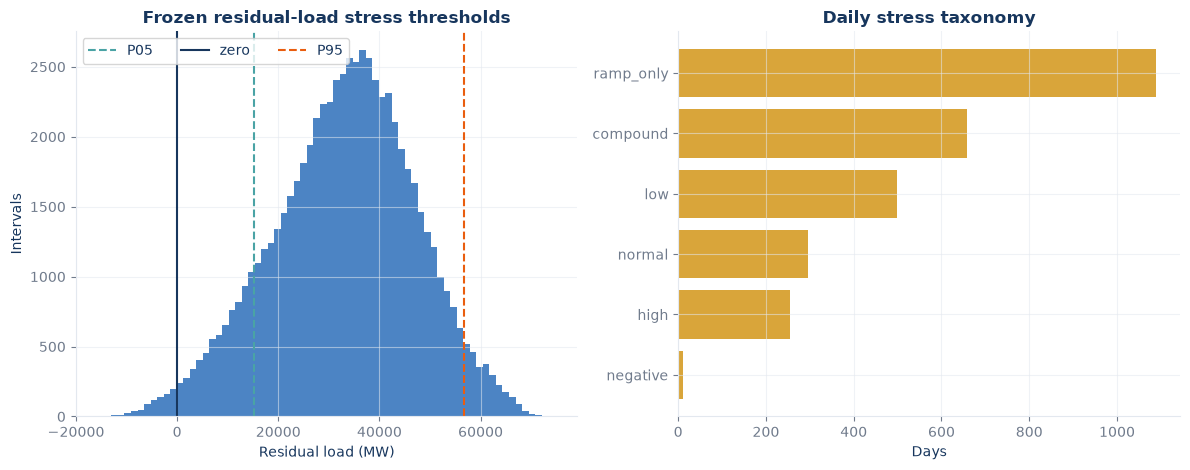

In [19]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].hist(labeled["residual_load_mw"].dropna(), bins=70, color=COLORS["blue"], alpha=.85)
axes[0].axvline(STRESS_THRESHOLDS["residual_p05_mw"], color=COLORS["teal"], linestyle="--", label="P05")
axes[0].axvline(0, color=COLORS["ink"], linewidth=1.5, label="zero")
axes[0].axvline(STRESS_THRESHOLDS["residual_p95_mw"], color=COLORS["orange"], linestyle="--", label="P95")
axes[0].set(title="Frozen residual-load stress thresholds", xlabel="Residual load (MW)", ylabel="Intervals")
axes[0].legend(ncol=3)
day_counts = daily_stress["stress_day_type"].value_counts().sort_values()
axes[1].barh(day_counts.index, day_counts.values, color=COLORS["gold"])
axes[1].set(title="Daily stress taxonomy", xlabel="Days", ylabel="")
finish_figure(fig, "stress_label_design", "What are high, low, negative, ramp, and compound stress?")

| Conditions detected during a day         | Label, assuming no other conditions |
| ---------------------------------------- | ----------------------------------- |
| High residual load, without a large ramp | `high`                              |
| High residual load **and** a large ramp  | `compound`                          |
| Low residual load **and** a large ramp   | `compound`                          |
| Large ramp, without a level extreme      | `ramp_only`                         |
| Neither a level extreme nor a large ramp | `normal`                            |



| Position on your histogram               | Condition you can identify                      |
| --------------------------               | ----------------------------------------------- |
| To the right of **P95**                  | High residual load                              |
| To the left of **P05**                   | Low residual load                               |
| To the left of **zero**                  | Negative residual load                          |
| Between **P05 and P95**                  | Residual load within the selected central range |



### Feature hypotheses before looking at OOF outcomes

Calendar geometry should explain recurring demand and renewable cycles; local-profile histories should
add recent level and shape; the origin snapshot should capture current system state; rolling history
should distinguish stable from volatile regimes; physical component histories should improve the
residual decomposition. The signal extension adds two pre-declared hypotheses: a complete trailing
28-day spectrum may summarize changing periodic strength, and public one-off shocks may help only as
adaptation clocks after they are known. A small interaction set tests amplitude modulation. No feature
is selected because it happened to correlate with the full target record.


### 4A. Signal-theoretic feature design

#### Question

**Which periods, event clocks, and physical states are genuine forecast inputs—and which are only
diagnostic descriptions of the observed waveform?**

For a target interval (t+h), the working discrete-time model is

\[
R_{t+h}=\beta_0+T(t)+\sum_{P,k}\left[a_{P,k}\sin(2\pi kt/P)+
b_{P,k}\cos(2\pi kt/P)\right]+\beta^\top X_{t,h\mid t}+
\sum_\ell\phi_\ell R_{t-\ell}+\gamma^\top E_{t,h\mid t}+\varepsilon_{t+h}.
\]

The sine/cosine columns are features; (a,b) and amplitude
\(A=\sqrt{a^2+b^2}\) are fitted coefficients unless estimated from a strictly trailing window.
FT is the mathematical representation, DFT is its finite sampled form, and FFT is an algorithm for
computing the DFT. None identifies a physical cause. Because the data are sampled, a discrete-time
state-space or (z)-domain view is more appropriate than claiming one global continuous-time Laplace
transfer function. Here the control-theory contribution is the information-flow contract.


**Implementation distinction.** Daily H1/H2/H3 and weekly H2 are materialized together in the
point-in-time factory. Context products never depend on whether a spectral test happened to run.
The daily third harmonic is an 8-hour calendar component. These are local-clock features;
the spectral estimator instead uses a uniformly spaced UTC physical-time axis.


### Record the EDA handoff and systems boundary

Inspect the stated units, time range and support before interpreting the resulting table or figure.

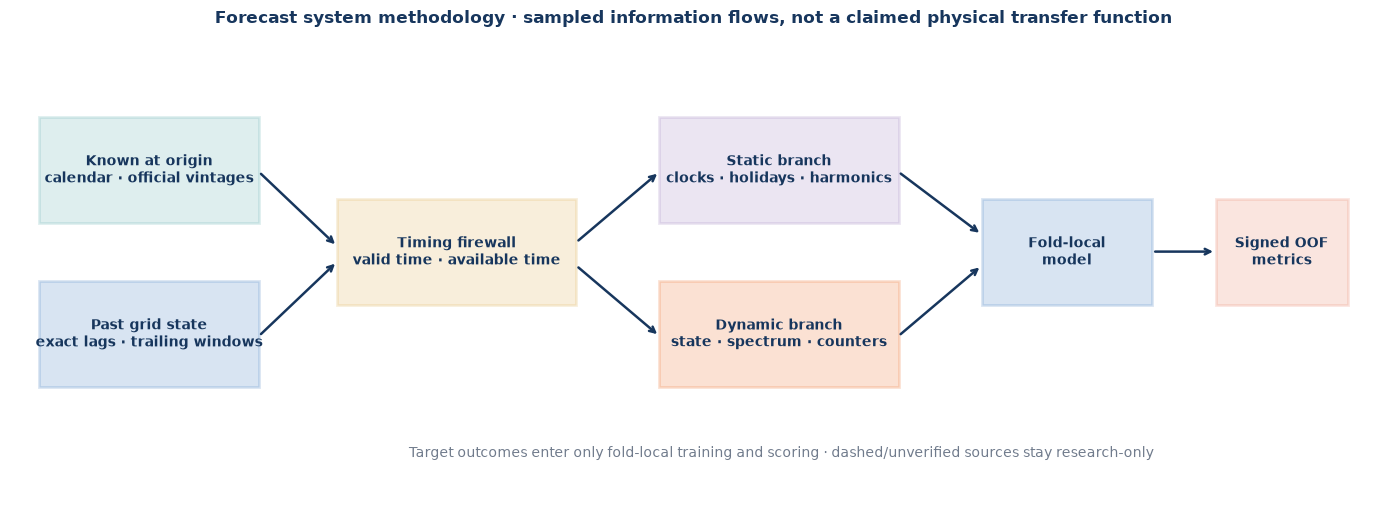

In [20]:
# -----------------------------------------------------------------
# Time semantics and forecast-origin integrity
# -----------------------------------------------------------------
UPSTREAM_EDA_HANDOFF = {
    "notebook": "Hari_GridStress_API_EDA_Data_Visualisation(3).ipynb",
    "sections": [12, 13, 18, 19, 20, 21, 22],
    "contract": "hypotheses only; no runtime-object dependency",
}

fig, ax = plt.subplots(figsize=(14, 5.2))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis("off")
blocks = [
    (0.3, 3.55, 2.25, 1.35, "Known at origin\ncalendar · official vintages", COLORS["teal"]),
    (0.3, 1.45, 2.25, 1.35, "Past grid state\nexact lags · trailing windows", COLORS["blue"]),
    (3.35, 2.50, 2.45, 1.35, "Timing firewall\nvalid time · available time", COLORS["gold"]),
    (6.65, 3.55, 2.45, 1.35, "Static branch\nclocks · holidays · harmonics", COLORS["purple"]),
    (6.65, 1.45, 2.45, 1.35, "Dynamic branch\nstate · spectrum · counters", COLORS["orange"]),
    (9.95, 2.50, 1.75, 1.35, "Fold-local\nmodel", COLORS["blue"]),
    (12.35, 2.50, 1.35, 1.35, "Signed OOF\nmetrics", COLORS["coral"]),
]
for x, y, width, height, label, color in blocks:
    ax.add_patch(Rectangle((x, y), width, height, facecolor=color, alpha=.18,
                           edgecolor=color, linewidth=2))
    ax.text(x + width / 2, y + height / 2, label, ha="center", va="center",
            fontsize=10, fontweight="bold")
arrows = [
    ((2.55, 4.2), (3.35, 3.25)), ((2.55, 2.1), (3.35, 3.05)),
    ((5.8, 3.3), (6.65, 4.2)), ((5.8, 3.0), (6.65, 2.1)),
    ((9.1, 4.2), (9.95, 3.4)), ((9.1, 2.1), (9.95, 3.0)),
    ((11.7, 3.18), (12.35, 3.18)),
]
for start, end in arrows:
    ax.annotate("", xy=end, xytext=start,
                arrowprops={"arrowstyle": "->", "color": COLORS["ink"], "lw": 1.8})
ax.text(7.9, .55,
        "Target outcomes enter only fold-local training and scoring · dashed/unverified sources stay research-only",
        ha="center", color=COLORS["muted"], fontsize=10)
ax.set_title("Forecast system methodology · sampled information flows, not a claimed physical transfer function")
finish_figure(fig, "forecast_system_methodology", "How does information cross the forecast-origin boundary?")

### Sampled-data systems and control contract

**Question:** what can the model observe, what is the state, and where could feedback
enter without creating a race hazard?

Residual load is treated as the sampled output of a driven physical process. Load,
wind and solar are disturbances/inputs; the publication channel imposes delay; the
state estimator may use only samples whose available-at time is no later than the
forecast origin. A historical forecast-error feedback path is disabled unless the
exact forecast vintage that was visible at that historical origin is archived.

The useful model is discrete:

x[k+1] = A x[k] + B u[k] + w[k],  y[k] = C x[k] + v[k]

rather than an asserted continuous transfer function Y(s)=G(s)X(s). Laplace-domain
language remains conceptual because this data does not identify a stationary,
linear, causal plant or an operator control input.


### Draw the sampled-data information contract

Inspect the stated units, time range and support before interpreting the resulting table or figure.

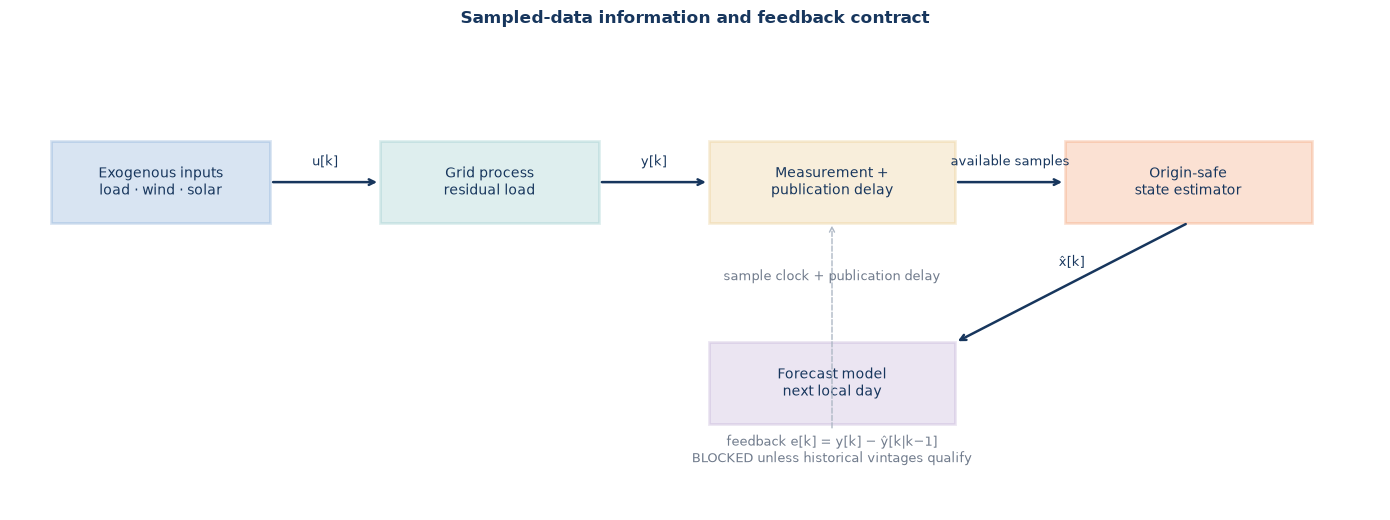

In [21]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
# Question: where are the information delays and the legitimately closed loops?
fig, ax = plt.subplots(figsize=(14, 5.3))
blocks = [
    (0.03, 0.60, 0.16, 0.17, "Exogenous inputs\nload · wind · solar", COLORS["blue"]),
    (0.27, 0.60, 0.16, 0.17, "Grid process\nresidual load", COLORS["teal"]),
    (0.51, 0.60, 0.18, 0.17, "Measurement +\npublication delay", COLORS["gold"]),
    (0.77, 0.60, 0.18, 0.17, "Origin-safe\nstate estimator", COLORS["orange"]),
    (0.51, 0.18, 0.18, 0.17, "Forecast model\nnext local day", COLORS["purple"]),
]
for x, y, width, height, label, color in blocks:
    ax.add_patch(Rectangle((x, y), width, height, facecolor=color, alpha=.18,
                           edgecolor=color, linewidth=2))
    ax.text(x + width / 2, y + height / 2, label, ha="center", va="center", fontsize=10)
arrows = [
    ((.19, .685), (.27, .685), "u[k]"),
    ((.43, .685), (.51, .685), "y[k]"),
    ((.69, .685), (.77, .685), "available samples"),
    ((.86, .60), (.69, .35), "x̂[k]"),
]
for start, end, label in arrows:
    ax.annotate("", xy=end, xytext=start,
                arrowprops={"arrowstyle": "->", "color": COLORS["ink"], "lw": 1.8})
    ax.text((start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + .035,
            label, ha="center", fontsize=9)
ax.annotate(
    "feedback e[k] = y[k] − ŷ[k|k−1]\nBLOCKED unless historical vintages qualify",
    xy=(.60, .60), xytext=(.60, .16), ha="center", va="top", fontsize=9,
    arrowprops={"arrowstyle": "->", "linestyle": "--", "color": COLORS["blocked"]},
    color=COLORS["muted"],
)
ax.text(.60, .48, "sample clock + publication delay", ha="center",
        color=COLORS["muted"], fontsize=9)
ax.set(xlim=(0, 1), ylim=(0, 1), title="Sampled-data information and feedback contract")
ax.axis("off")
finish_figure(
    fig, "sampled_data_control_contract",
    "Which signals, delays and feedback paths are legal at the forecast origin?"
)

### Pure scientific helpers and executable invariants

These functions are intentionally independent of notebook globals. They provide
testable seams for correlation, PACF, harmonic fitting, driver decomposition, frozen
tiers, exact linear attribution and Sankey conservation.


The ACF uses fixed-n autocovariance normalization; its Durbin–Levinson recursion rejects an
invalid prediction variance rather than silently clipping it. Each exact-time lookup rejects
duplicate UTC keys. Helper definitions are separated from the execution that consumes them.


### Define reusable scientific helpers · 1/6

These are deterministic helpers, not evidence that an analysis has run. Estimator guards and units are documented in the functions.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [22]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def autocorrelation_fft(values: object, max_lag: int) -> np.ndarray:
    array = np.asarray(values, dtype=float).reshape(-1)
    if max_lag < 0 or max_lag >= len(array):
        raise ValueError("max_lag must be between zero and len(values)-1.")
    if not np.isfinite(array).all():
        raise ValueError("ACF input must be finite; imputation would alter memory.")
    centered = array - array.mean()
    variance_sum = float(centered @ centered)
    if variance_sum <= 1e-12:
        raise ValueError("ACF is undefined for a constant series.")
    transform_size = 1 << (2 * len(centered) - 1).bit_length()
    spectrum = np.fft.rfft(centered, n=transform_size)
    covariance = np.fft.irfft(spectrum * np.conjugate(spectrum), n=transform_size)
    covariance = covariance[: max_lag + 1]
    # Fixed-n autocovariance gives a positive-semidefinite Toeplitz sequence
    # for Yule-Walker/Durbin-Levinson PACF. Lag-dependent divisors need not.
    return covariance / variance_sum



# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def pacf_durbin_levinson(acf_values: object, max_lag: int) -> np.ndarray:
    acf = np.asarray(acf_values, dtype=float).reshape(-1)
    if max_lag < 0 or len(acf) <= max_lag:
        raise ValueError("ACF must contain lags zero through max_lag.")
    if not np.isfinite(acf[: max_lag + 1]).all() or acf[0] <= 0:
        raise ValueError("PACF needs a finite positive lag-zero autocorrelation.")
    normalized = acf[: max_lag + 1] / acf[0]
    pacf = np.zeros(max_lag + 1, dtype=float)
    pacf[0] = 1.0
    coefficients = np.zeros((max_lag + 1, max_lag + 1), dtype=float)
    prediction_error = 1.0
    for order in range(1, max_lag + 1):
        numerator = normalized[order]
        if order > 1:
            numerator -= np.dot(
                coefficients[order - 1, 1:order],
                normalized[1:order][::-1],
            )
        if not np.isfinite(prediction_error) or prediction_error <= 1e-14:
            raise ValueError("PACF recursion has nonpositive prediction variance; inspect the ACF estimator.")
        reflection = numerator / prediction_error
        if not np.isfinite(reflection) or abs(reflection) > 1 + 1e-10:
            raise ValueError("PACF reflection coefficient is invalid; do not clip a broken covariance sequence.")
        coefficients[order, order] = reflection
        if order > 1:
            previous = coefficients[order - 1, 1:order]
            coefficients[order, 1:order] = previous - reflection * previous[::-1]
        prediction_error *= 1.0 - reflection ** 2
        pacf[order] = reflection
    return pacf

### Define reusable scientific helpers · 2/6

These are deterministic helpers, not evidence that an analysis has run. Estimator guards and units are documented in the functions.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [23]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def fit_harmonic_projection(
    train_time_hours: object,
    train_values: object,
    evaluation_time_hours: object,
    periods_hours: list[float] | tuple[float, ...],
) -> tuple[np.ndarray, pd.DataFrame]:
    train_time = np.asarray(train_time_hours, dtype=float).reshape(-1)
    values = np.asarray(train_values, dtype=float).reshape(-1)
    evaluation_time = np.asarray(evaluation_time_hours, dtype=float).reshape(-1)
    if len(train_time) != len(values) or len(train_time) < 3:
        raise ValueError("Harmonic fit needs aligned training time and values.")
    if not np.isfinite(train_time).all() or not np.isfinite(values).all():
        raise ValueError("Harmonic fit inputs must be finite.")
    periods = [float(period) for period in periods_hours]
    if not periods or any(period <= 0 for period in periods):
        raise ValueError("Every declared period must be positive.")


# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
    def design(time_axis: np.ndarray) -> np.ndarray:
        columns = [np.ones(len(time_axis))]
        for period in periods:
            angle = 2.0 * np.pi * time_axis / period
            columns.extend([np.sin(angle), np.cos(angle)])
        return np.column_stack(columns)

    coefficients = np.linalg.lstsq(design(train_time), values, rcond=None)[0]
    prediction = design(evaluation_time) @ coefficients
    rows = []
    for index, period in enumerate(periods):
        sin_coef = float(coefficients[1 + 2 * index])
        cos_coef = float(coefficients[2 + 2 * index])
        rows.append({
            "period_hours": period,
            "sin_coef": sin_coef,
            "cos_coef": cos_coef,
            "amplitude": float(np.hypot(sin_coef, cos_coef)),
            "phase_radians": float(np.arctan2(cos_coef, sin_coef)),
        })
    table = pd.DataFrame(rows)
    table.attrs["intercept"] = float(coefficients[0])
    return prediction, table

### Define reusable scientific helpers · 3/6

These are deterministic helpers, not evidence that an analysis has run. Estimator guards and units are documented in the functions.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [24]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def build_context_modulated_harmonics(
    frame: pd.DataFrame,
) -> tuple[pd.DataFrame, list[str]]:
    daily_terms = [
        "calendar_slot_sin", "calendar_slot_cos",
        "calendar_hour_h2_sin", "calendar_hour_h2_cos",
        "calendar_hour_h3_sin", "calendar_hour_h3_cos",
    ]
    context_terms = [
        "calendar_dow_sin", "calendar_dow_cos",
        "calendar_doy_sin", "calendar_doy_cos",
    ]
    missing = [name for name in daily_terms + context_terms if name not in frame]
    if missing:
        raise KeyError(f"Context modulation is missing parent columns: {missing}")
    if frame.columns.has_duplicates:
        raise ValueError("Context modulation requires unique input columns.")
    result = frame.copy()
    names = []
    for daily_name in daily_terms:
        for context_name in context_terms:
            name = f"interaction_{daily_name}_x_{context_name}"
            result[name] = (
                pd.to_numeric(result[daily_name], errors="raise")
                * pd.to_numeric(result[context_name], errors="raise")
            )
            names.append(name)
    if len(names) != 24 or len(set(names)) != 24:
        raise AssertionError("The declared context basis must contain exactly 24 products.")
    return result, names



# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def derive_forecast_driver_state(frame: pd.DataFrame) -> pd.DataFrame:
    required = {
        "forecast_origin_utc", "forecast_valid_time_utc", "forecast_load_mw",
        "forecast_wind_mw", "forecast_solar_mw",
    }
    if not required.issubset(frame.columns):
        raise KeyError(f"Forecast driver state requires {sorted(required)}")
    result = frame.copy()
    result["forecast_origin_utc"] = pd.to_datetime(result["forecast_origin_utc"], utc=True)
    result["forecast_valid_time_utc"] = pd.to_datetime(
        result["forecast_valid_time_utc"], utc=True
    )
    numeric = ["forecast_load_mw", "forecast_wind_mw", "forecast_solar_mw"]
    result[numeric] = result[numeric].apply(pd.to_numeric, errors="coerce")
    result = result.sort_values(
        ["forecast_origin_utc", "forecast_valid_time_utc"]
    ).reset_index(drop=True)
    result["forecast_residual_load_mw"] = (
        result["forecast_load_mw"]
        - result["forecast_wind_mw"]
        - result["forecast_solar_mw"]
    )
    grouped = result.groupby("forecast_origin_utc", sort=False)
    adjacent = grouped["forecast_valid_time_utc"].diff().eq(cadence_delta)
    result["forecast_driver_load_mw"] = grouped["forecast_load_mw"].diff().where(adjacent)
    result["forecast_driver_wind_mw"] = -grouped["forecast_wind_mw"].diff().where(adjacent)
    result["forecast_driver_solar_mw"] = -grouped["forecast_solar_mw"].diff().where(adjacent)
    driver_columns = [
        "forecast_driver_load_mw", "forecast_driver_wind_mw",
        "forecast_driver_solar_mw",
    ]
    result["forecast_residual_ramp_mw"] = result[driver_columns].sum(
        axis=1, min_count=len(driver_columns)
    )
    gross = result[driver_columns].abs().sum(
        axis=1, min_count=len(driver_columns)
    )
    net = result["forecast_residual_ramp_mw"].abs()
    result["forecast_driver_dominance"] = (
        result[driver_columns].abs().max(axis=1) / gross
    ).where(gross > 0)
    result["forecast_driver_cancellation"] = (
        1.0 - net / gross
    ).where(gross > 0)
    labels = pd.Series(["load", "wind", "solar"], index=driver_columns)
    complete = result[driver_columns].notna().all(axis=1) & (gross > 0)
    result["forecast_dominant_driver"] = pd.Series(
        pd.NA, index=result.index, dtype="string"
    )
    result.loc[complete, "forecast_dominant_driver"] = (
        result.loc[complete, driver_columns].abs().idxmax(axis=1).map(labels)
    )
    return result

### Define reusable scientific helpers · 4/6

These are deterministic helpers, not evidence that an analysis has run. Estimator guards and units are documented in the functions.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [25]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def assign_frozen_residual_tier(
    values: object, thresholds: dict[str, float]
) -> pd.Series:
    required = ["p05", "p25", "p75", "p95"]
    if any(key not in thresholds for key in required):
        raise KeyError(f"Frozen tiers require thresholds {required}")
    cutpoints = np.asarray([thresholds[key] for key in required], dtype=float)
    if not np.isfinite(cutpoints).all() or not np.all(np.diff(cutpoints) >= 0):
        raise ValueError("Frozen tier thresholds must be finite and ordered.")
    series = pd.Series(values).astype(float)
    labels = np.select(
        [
            series <= cutpoints[0],
            series <= cutpoints[1],
            series <= cutpoints[2],
            series <= cutpoints[3],
        ],
        ["lower_extreme", "low", "core", "high"],
        default="upper_extreme",
    )
    labels = pd.Series(labels, index=series.index, dtype="string")
    return labels.mask(series.isna())

### Define reusable scientific helpers · 5/6

These are deterministic helpers, not evidence that an analysis has run. Estimator guards and units are documented in the functions.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [26]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def grouped_linear_contributions(
    matrix: object,
    coefficients: object,
    feature_names: list[str] | tuple[str, ...],
    feature_to_family: dict[str, str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    values = np.asarray(matrix, dtype=float)
    weights = np.asarray(coefficients, dtype=float).reshape(-1)
    if values.ndim != 2 or values.shape[1] != len(weights):
        raise ValueError("Contribution matrix and coefficient dimensions do not agree.")
    if len(feature_names) != len(weights):
        raise ValueError("Every transformed column needs a feature name.")
    unmapped = [name for name in feature_names if name not in feature_to_family]
    if unmapped:
        raise KeyError(f"Transformed features lack family mappings: {unmapped}")
    signed = pd.DataFrame(
        values * weights,
        columns=list(feature_names),
    )
    families = []
    for name in feature_names:
        family = feature_to_family[name]
        if family not in families:
            families.append(family)
    grouped_signed = pd.DataFrame({
        family: signed[
            [name for name in feature_names if feature_to_family[name] == family]
        ].sum(axis=1)
        for family in families
    })
    grouped_absolute = pd.DataFrame({
        family: signed[
            [name for name in feature_names if feature_to_family[name] == family]
        ].abs().sum(axis=1)
        for family in families
    })
    return grouped_signed, grouped_absolute

### Define reusable scientific helpers · 6/6

These are deterministic helpers, not evidence that an analysis has run. Estimator guards and units are documented in the functions.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [27]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def validate_framed_sankey_links(links: pd.DataFrame) -> pd.DataFrame:
    required = {
        "frame_id", "source_stage", "target_stage", "source", "target",
        "value", "unit",
    }
    if not required.issubset(links.columns):
        raise ValueError(f"Framed Sankey links require {sorted(required)}")
    if links.empty:
        raise ValueError("Framed Sankey links cannot be empty.")
    values = pd.to_numeric(links["value"], errors="coerce")
    if not np.isfinite(values).all() or (values <= 0).any():
        raise ValueError("Every Sankey ribbon must have a finite positive width.")
    if links["unit"].nunique(dropna=False) != 1:
        raise ValueError("A Sankey table must contain exactly one declared unit.")
    source_stage = pd.to_numeric(links["source_stage"], errors="coerce")
    target_stage = pd.to_numeric(links["target_stage"], errors="coerce")
    if not np.isfinite(source_stage).all() or not np.isfinite(target_stage).all():
        raise ValueError("Sankey stages must be finite integers.")
    if not (source_stage.mod(1).eq(0).all() and target_stage.mod(1).eq(0).all()):
        raise ValueError("Sankey stages must be finite integers, not fractional stage codes.")
    if not (target_stage - source_stage).eq(1).all():
        raise ValueError("Sankey links must connect adjacent stages only.")
    audit_rows = []
    for frame_id, frame in links.groupby("frame_id", sort=False):
        stages = sorted(
            set(frame["source_stage"].astype(int))
            | set(frame["target_stage"].astype(int))
        )
        if stages != list(range(min(stages), max(stages) + 1)):
            raise ValueError(f"Frame {frame_id} has a non-contiguous stage sequence.")
        for stage in stages[1:-1]:
            incoming = (
                frame.loc[frame["target_stage"].eq(stage)]
                .groupby("target")["value"].sum()
            )
            outgoing = (
                frame.loc[frame["source_stage"].eq(stage)]
                .groupby("source")["value"].sum()
            )
            names = incoming.index.union(outgoing.index)
            imbalance = (
                incoming.reindex(names, fill_value=0.0)
                - outgoing.reindex(names, fill_value=0.0)
            )
            if not np.allclose(imbalance.to_numpy(float), 0.0, rtol=0, atol=1e-10):
                offender = imbalance.abs().idxmax()
                raise AssertionError(
                    f"Frame {frame_id}, stage {stage}, node {offender!r} is not conserved."
                )
        start_total = float(
            frame.loc[frame["source_stage"].eq(min(stages)), "value"].sum()
        )
        end_total = float(
            frame.loc[frame["target_stage"].eq(max(stages)), "value"].sum()
        )
        if not np.isclose(start_total, end_total, rtol=0, atol=1e-10):
            raise AssertionError(
                f"Frame {frame_id} starts with {start_total} but ends with {end_total}."
            )
        audit_rows.append({
            "frame_id": frame_id,
            "unit": frame["unit"].iloc[0],
            "stage_count": len(stages),
            "start_total": start_total,
            "terminal_total": end_total,
            "conserved": True,
        })
    return pd.DataFrame(audit_rows)

### Build the point-in-time feature matrix · 1/4

Input: ordered observed history. Output: one row per target interval, its D−1 noon origin and an explicit safe calendar/history feature set.

In [28]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
LEAKAGE_BLOCKLIST = {
    "residual_load_mw", "load_mw", "wind_onshore_mw", "wind_offshore_mw", "solar_mw",
    "ramp_1h_mw", "stress_any", "stress_high", "stress_low", "stress_negative",
    "stress_ramp_up", "stress_ramp_down", "stress_compound", "stress_severity_mw",
}

@lru_cache(maxsize=None)

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def easter_sunday(year: int) -> date:
    a = year % 19
    b, c = divmod(year, 100)
    d, e = divmod(b, 4)
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30
    i, k = divmod(c, 4)
    l = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * l) // 451
    month = (h + l - 7 * m + 114) // 31
    day = (h + l - 7 * m + 114) % 31 + 1
    return date(year, month, day)

@lru_cache(maxsize=None)

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def german_public_holidays(year: int) -> set[date]:
    easter = easter_sunday(year)
    return {
        date(year, 1, 1), easter - timedelta(days=2), easter + timedelta(days=1),
        date(year, 5, 1), easter + timedelta(days=39), easter + timedelta(days=50),
        date(year, 10, 3), date(year, 12, 25), date(year, 12, 26),
    }

### Build the point-in-time feature matrix · 2/4

Input: ordered observed history. Output: one row per target interval, its D−1 noon origin and an explicit safe calendar/history feature set.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [29]:
# -----------------------------------------------------------------
# Time semantics and forecast-origin integrity
# -----------------------------------------------------------------
@lru_cache(maxsize=None)

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def forecast_origin_for_day(day: date) -> pd.Timestamp:
    local_origin = datetime.combine(
        day - timedelta(days=1), clock_time(FORECAST_ORIGIN_LOCAL_HOUR), tzinfo=BERLIN
    )
    return pd.Timestamp(local_origin).tz_convert("UTC")

### Build the point-in-time feature matrix · 3/4

Input: ordered observed history. Output: one row per target interval, its D−1 noon origin and an explicit safe calendar/history feature set.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [30]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def build_point_in_time_features(frame: pd.DataFrame) -> pd.DataFrame:
    ordered = frame.sort_values("event_time_utc").reset_index(drop=True).copy()
    local = ordered["event_time_utc"].dt.tz_convert(TZ_NAME)
    target_dates = pd.to_datetime(local.dt.date)
    target_days = [stamp.date() for stamp in target_dates]
    origins = pd.DatetimeIndex([forecast_origin_for_day(day) for day in target_days]).as_unit("ns")
    minute_of_day = local.dt.hour * 60 + local.dt.minute
    day_of_year = local.dt.dayofyear

    features = pd.DataFrame({
        "target_time_utc": ordered["event_time_utc"],
        "target_time_local": local,
        "target_date_local": target_dates,
        "forecast_origin_utc": origins,
        "horizon_hours": (ordered["event_time_utc"] - origins).dt.total_seconds() / 3600,
        "residual_load_mw": ordered["residual_load_mw"],
        "calendar_slot_index": (minute_of_day // CADENCE_MINUTES).astype(int),
        "calendar_hour_raw": local.dt.hour + local.dt.minute / 60,
        "calendar_dow_raw": local.dt.dayofweek.astype(int),
        "calendar_doy_raw": day_of_year.astype(int),
        "calendar_month": local.dt.month.astype(int),
        "calendar_weekend": (local.dt.dayofweek >= 5).astype(int),
    })
    local_wall_key = local.dt.strftime("%Y-%m-%d %H:%M")
    features["calendar_fold_occurrence"] = local_wall_key.groupby(local_wall_key).cumcount().astype(int)
    features["calendar_utc_offset_hours"] = local.map(
        lambda stamp: stamp.utcoffset().total_seconds() / 3600.0
    ).to_numpy(float)
    features["calendar_slot_sin"] = np.sin(2 * np.pi * minute_of_day / 1440)
    features["calendar_slot_cos"] = np.cos(2 * np.pi * minute_of_day / 1440)
    features["calendar_dow_sin"] = np.sin(2 * np.pi * local.dt.dayofweek / 7)
    features["calendar_dow_cos"] = np.cos(2 * np.pi * local.dt.dayofweek / 7)
    features["calendar_doy_sin"] = np.sin(2 * np.pi * (day_of_year - 1) / 365.2425)
    features["calendar_doy_cos"] = np.cos(2 * np.pi * (day_of_year - 1) / 365.2425)
    features["calendar_hour_h2_sin"] = np.sin(4 * np.pi * minute_of_day / 1440)
    features["calendar_hour_h2_cos"] = np.cos(4 * np.pi * minute_of_day / 1440)
    # Build all deterministic parents HERE, before either spectral tests or
    # context modulation. No separate repair cell or hidden execution state.
    minute_of_week = local.dt.dayofweek * 1440 + minute_of_day
    features["calendar_hour_h3_sin"] = np.sin(6 * np.pi * minute_of_day / 1440)
    features["calendar_hour_h3_cos"] = np.cos(6 * np.pi * minute_of_day / 1440)
    features["calendar_week_h2_sin"] = np.sin(4 * np.pi * minute_of_week / (7 * 1440))
    features["calendar_week_h2_cos"] = np.cos(4 * np.pi * minute_of_week / (7 * 1440))
    holiday_sets = {year: german_public_holidays(year) for year in sorted(set(local.dt.year))}
    features["calendar_holiday"] = [
        int(day in holiday_sets[day.year]) for day in target_days
    ]
    features["calendar_dst_day_steps"] = [
        expected_local_day_steps(day, CADENCE_MINUTES) for day in target_days
    ]

    day_lags = {48: 2, 168: 7, 336: 14, 504: 21, 672: 28}
    for hours, days in day_lags.items():
        features[f"persistence_residual_lag_{hours}h_mw"] = local_profile_lag(
            ordered["residual_load_mw"], ordered["event_time_utc"], days
        )
        features[f"persistence_source_time_{hours}h_utc"] = pd.to_datetime(
            local_profile_lag(ordered["event_time_utc"], ordered["event_time_utc"], days),
            utc=True, errors="coerce",
        )
        published = features[f"persistence_source_time_{hours}h_utc"] + DATA_PUBLICATION_LATENCY
        available = published.notna() & (published <= features["forecast_origin_utc"])
        features[f"persistence_residual_lag_{hours}h_mw"] = features[f"persistence_residual_lag_{hours}h_mw"].where(available)
    weekly_lags = features[[
        "persistence_residual_lag_168h_mw", "persistence_residual_lag_336h_mw",
        "persistence_residual_lag_504h_mw", "persistence_residual_lag_672h_mw",
    ]]
    features["persistence_weekly_median_mw"] = weekly_lags.median(axis=1, skipna=True)
    weekly_median = features["persistence_weekly_median_mw"]
    features["persistence_weekly_mad_mw"] = weekly_lags.sub(weekly_median, axis=0).abs().median(axis=1)
    daily_mean_lookup = ordered.groupby("target_date_local")["residual_load_mw"].mean()
    d2_dates = target_dates - pd.Timedelta(days=2)
    features["shape_d2_centered_mw"] = (
        features["persistence_residual_lag_48h_mw"]
        - pd.Series(d2_dates).map(daily_mean_lookup).to_numpy(float)
    )
    features["shape_d2_ramp_1h_mw"] = local_profile_lag(
        ordered["ramp_1h_mw"], ordered["event_time_utc"], days=2
    )

    for canonical in ("load_mw", "wind_onshore_mw", "wind_offshore_mw", "solar_mw"):
        features[f"physical_{canonical.removesuffix('_mw')}_lag_48h_mw"] = local_profile_lag(
            ordered[canonical], ordered["event_time_utc"], days=2
        )
        features[f"physical_{canonical.removesuffix('_mw')}_lag_168h_mw"] = local_profile_lag(
            ordered[canonical], ordered["event_time_utc"], days=7
        )

    history = ordered[[
        "event_time_utc", "residual_load_mw", "load_mw", "wind_onshore_mw",
        "wind_offshore_mw", "solar_mw"
    ]].copy()
    history["origin_vre_mw"] = (
        history["wind_onshore_mw"] + history["wind_offshore_mw"] + history["solar_mw"]
    )
    history["origin_ramp_1h_mw"] = exact_time_delta(
        history["residual_load_mw"], history["event_time_utc"], hours=1
    )
    indexed = history.set_index("event_time_utc")
    for hours in (24, 72, 168):
        history[f"rolling_residual_mean_{hours}h_mw"] = indexed["residual_load_mw"].rolling(
            f"{hours}h", min_periods=max(2, hours * PERIODS_PER_HOUR // 2)
        ).mean().to_numpy()
        history[f"rolling_residual_std_{hours}h_mw"] = indexed["residual_load_mw"].rolling(
            f"{hours}h", min_periods=max(2, hours * PERIODS_PER_HOUR // 2)
        ).std().to_numpy()
    history = history.rename(columns={
        "residual_load_mw": "origin_residual_load_mw",
        "load_mw": "origin_load_mw",
    })
    history["available_at_utc"] = history["event_time_utc"] + DATA_PUBLICATION_LATENCY
    state_columns = [
        "origin_residual_load_mw", "origin_load_mw", "origin_vre_mw", "origin_ramp_1h_mw",
        *[f"rolling_residual_{stat}_{hours}h_mw" for hours in (24, 72, 168) for stat in ("mean", "std")],
    ]
    origin_keys = pd.DataFrame({
        "forecast_origin_utc": pd.DatetimeIndex(features["forecast_origin_utc"].unique()).sort_values()
    })
    origin_states = pd.merge_asof(
        origin_keys,
        history[["available_at_utc", *state_columns]].sort_values("available_at_utc"),
        left_on="forecast_origin_utc", right_on="available_at_utc", direction="backward",
        allow_exact_matches=True, tolerance=cadence_delta,
    )
    features = features.merge(origin_states, on="forecast_origin_utc", how="left", validate="many_to_one")
    features["history_support_count"] = features[[
        "persistence_residual_lag_48h_mw", "persistence_residual_lag_168h_mw",
        "persistence_residual_lag_336h_mw", "origin_residual_load_mw",
    ]].notna().sum(axis=1)
    features["interaction_hour_x_season"] = features["calendar_slot_sin"] * features["calendar_doy_sin"]
    features["interaction_origin_vre_x_hour"] = features["origin_vre_mw"] * features["calendar_slot_sin"]
    features["interaction_weekly_lag_x_weekend"] = (
        features["persistence_residual_lag_168h_mw"] * features["calendar_weekend"]
    )
    if features.columns.has_duplicates:
        raise AssertionError("Point-in-time factory produced duplicate column names.")
    return features

### Build the point-in-time feature matrix · 4/4

Input: ordered observed history. Output: one row per target interval, its D−1 noon origin and an explicit safe calendar/history feature set.

In [31]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
feature_matrix = build_point_in_time_features(labeled)
label_payload = labeled[["event_time_utc", *label_columns, "stress_any", "stress_compound", "stress_severity_mw"]]
feature_matrix = feature_matrix.merge(
    label_payload, left_on="target_time_utc", right_on="event_time_utc", how="left", validate="one_to_one"
).drop(columns="event_time_utc")
eligible_target_times = set(scored_labeled["event_time_utc"])
feature_matrix = feature_matrix.loc[
    feature_matrix["target_time_utc"].isin(eligible_target_times)
].reset_index(drop=True)
if feature_matrix["residual_load_mw"].isna().any() or feature_matrix["stress_any"].isna().any():
    raise AssertionError("Scored target population contains missing regression or stress labels.")
for target_day, group in feature_matrix.groupby("target_date_local"):
    expected_steps = expected_local_day_steps(pd.Timestamp(target_day).date(), CADENCE_MINUTES)
    if len(group) != expected_steps or group["forecast_origin_utc"].nunique() != 1:
        raise AssertionError(f"Incomplete or mixed-origin target profile: {target_day}")
dst_feature_audit = {
    "repeated_wall_clock_intervals": int(feature_matrix["calendar_fold_occurrence"].eq(1).sum()),
    "fold_values": sorted(feature_matrix["calendar_fold_occurrence"].unique().tolist()),
    "utc_offsets": sorted(feature_matrix["calendar_utc_offset_hours"].unique().tolist()),
    "repeated_intervals_distinguishable": bool(
        feature_matrix.loc[feature_matrix["calendar_fold_occurrence"].eq(1), "calendar_utc_offset_hours"].notna().all()
    ),
}
if not set(dst_feature_audit["fold_values"]).issubset({0, 1}):
    raise AssertionError(dst_feature_audit)
print("Feature matrix:", feature_matrix.shape)

Feature matrix: (67391, 73)


### Question → feature: can the changing waveform be summarized without seeing the future?

The global FFT remains diagnostic because it sees the full record. The candidate below instead uses
one fixed 28-day **physical UTC** window for each forecast origin, ending at the latest source interval
whose assumed publication time is no later than that origin. Missing or irregular windows are rejected,
not compressed or interpolated. Daily, half-daily and weekly bands are declared in advance; there is no
full-record peak search. Spectral energy shares, amplitudes and entropy are dynamic research features.

Event dates are kept in an overlapping ledger. WHO PHEIC dates provide global context; a German policy
anchor and the observed 2022 invasion anchor are single-event adaptation clocks. They are associations,
not causal effects and not proof that another crisis will transfer. The open-ended invasion clock has no
invented terminal boundary; `later_normalization_window` is reporting-only.


**Repaired timestamp contract.** An expected 28-day UTC grid is constructed up to
`origin − publication_latency`. Every expected timestamp and value must be present and finite.
No interpolation is introduced. Rejection counts distinguish insufficient history, missing
calendar intervals, nonfinite observed values and zero detrended power.

The original integer comparison mixed microsecond `.asi8` values with nanosecond scalar
`.value` values. That can select the last rows of the entire record for an earlier origin,
then reject every window. The new implementation uses timestamp-aware indexing, and the
verification fixtures include both `datetime64[ns]` and `datetime64[us]` inputs.

The future-poison challenge needs **two causally separated valid origins**, not forty.
It must establish both earlier-origin invariance and later-origin sensitivity. All-missing
outputs, invalid recomputed windows and an unrun challenge cannot count as a pass.


### Build and challenge origin spectral state · 1/6

Input: original history and forecast origins. Output: a strict 28-day state table, rejection reasons and a non-vacuous future-poison audit. No gaps are interpolated.

In [32]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------
SPECTRAL_WINDOW_DAYS = 28
SPECTRAL_PERIODS_HOURS = OrderedDict([
    ("weekly", 168.0), ("daily", 24.0), ("halfdaily", 12.0), ("eight_hour", 8.0),
])

INTERVENTION_LEDGER = pd.DataFrame([
    {
        "event_id": "who_covid_pheic_context", "start_utc": "2020-01-30T00:00:00Z",
        "end_utc": "2023-05-05T23:59:59Z", "known_at_utc": "2020-01-30T23:59:59Z",
        "role": "analysis_only", "scope": "global health context",
        "source": "https://www.who.int/publications/m/item/covid-19-public-health-emergency-of-international-concern-(pheic)-global-research-and-innovation-forum",
        "end_source": "https://www.who.int/news/item/05-05-2023-statement-on-the-fifteenth-meeting-of-the-international-health-regulations-(2005)-emergency-committee-regarding-the-coronavirus-disease-(covid-19)-pandemic",
    },
    {
        "event_id": "covid_policy_disruption_anchor_de", "start_utc": "2020-03-16T00:00:00Z",
        "end_utc": None, "known_at_utc": "2020-03-16T23:59:59Z",
        "role": "research_adaptation", "scope": "German policy disruption anchor",
        "source": "https://www.bundesregierung.de/breg-de/themen/coronavirus",
        "end_source": None,
    },
    {
        "event_id": "invasion_observed_2022", "start_utc": "2022-02-24T00:00:00Z",
        "end_utc": None, "known_at_utc": "2022-02-24T23:59:59Z",
        "role": "research_adaptation", "scope": "observed external shock anchor",
        "source": "https://www.un.org/press/en/2022/ga12407.doc.htm",
        "end_source": None,
    },
    {
        "event_id": "later_normalization_window", "start_utc": "2024-01-01T00:00:00Z",
        "end_utc": None, "known_at_utc": "2024-01-01T00:00:00Z",
        "role": "analysis_only", "scope": "neutral reporting hypothesis",
        "source": "predeclared notebook reporting boundary",
        "end_source": None,
    },
])
for column in ["start_utc", "end_utc", "known_at_utc"]:
    INTERVENTION_LEDGER[column] = pd.to_datetime(
        INTERVENTION_LEDGER[column], utc=True, errors="coerce"
    )

REPORTING_PERIODS = pd.DataFrame([
    ("pre_disruption_reference", "2019-01-01", "2020-03-15"),
    ("pandemic_disruption", "2020-03-16", "2022-02-23"),
    ("pandemic_energy_shock_overlap", "2022-02-24", "2023-12-31"),
    ("later_normalization_window", "2024-01-01", None),
], columns=["period_id", "start_date", "end_date"])
REPORTING_PERIODS["model_role"] = "analysis_only"

### Build and challenge origin spectral state · 2/6

Input: original history and forecast origins. Output: a strict 28-day state table, rejection reasons and a non-vacuous future-poison audit. No gaps are interpolated.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [33]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def build_origin_spectral_state(
    history: pd.DataFrame,
    origins: object,
    value_column: str = "residual_load_mw",
    window_days: int = SPECTRAL_WINDOW_DAYS,
) -> pd.DataFrame:
    """Compute a strictly observed, trailing UTC spectrum at each forecast origin.

    Build the physical grid first. No row-count window, unit-dependent integer
    timestamp comparison, interpolation, or look-ahead is permitted. The audit
    records why a window is rejected, including zero detrended signal power.
    """
    required = ["event_time_utc", value_column]
    missing = [name for name in required if name not in history]
    if missing:
        raise KeyError(f"Spectral history is missing {missing}")
    if history.empty or window_days < 1 or int(window_days) != window_days:
        raise ValueError("Spectral history must be nonempty; window_days must be a positive integer.")
    latency = pd.Timedelta(DATA_PUBLICATION_LATENCY)
    if pd.isna(latency) or latency < pd.Timedelta(0):
        raise ValueError("Publication latency must be finite and nonnegative.")
    ordered = history[required].copy()
    ordered["event_time_utc"] = utc_series(ordered["event_time_utc"], "spectral history")
    ordered = ordered.sort_values("event_time_utc").reset_index(drop=True)
    if ordered["event_time_utc"].duplicated().any():
        raise ValueError("Spectral history requires unique UTC timestamps.")
    times = pd.DatetimeIndex(ordered["event_time_utc"])
    origin_index = pd.DatetimeIndex(utc_series(pd.Series(origins), "spectral origins")).unique().sort_values()
    if origin_index.empty:
        raise ValueError("No forecast origins were supplied for the spectral calculation.")
    step = pd.Timedelta(minutes=CADENCE_MINUTES)
    values = pd.to_numeric(ordered[value_column], errors="coerce").to_numpy(dtype=float, na_value=np.nan)
    series = pd.Series(values, index=times)
    expected_points = int(window_days * 24 * PERIODS_PER_HOUR)
    cadence_hours = CADENCE_MINUTES / 60.0
    relative_hours = np.arange(expected_points, dtype=float) * cadence_hours
    columns = [np.ones(expected_points)]
    for period_hours in SPECTRAL_PERIODS_HOURS.values():
        columns.extend([np.sin(2*np.pi*relative_hours/period_hours),
                        np.cos(2*np.pi*relative_hours/period_hours)])
    reconstruction_design = np.column_stack(columns)
    reconstruction_pinv = np.linalg.pinv(reconstruction_design)
    trend_design = np.column_stack([np.ones(expected_points), np.linspace(-1, 1, expected_points)])
    trend_pinv = np.linalg.pinv(trend_design)
    taper = np.hanning(expected_points)
    frequencies = np.fft.rfftfreq(expected_points, d=cadence_hours)
    rows = []
    for origin in origin_index:
        cutoff = origin - latency
        # All normalized observations lie on a UTC cadence grid. Floor the cutoff
        # in physical UTC, not Berlin wall time (which repeats/omits DST hours).
        grid_end = cutoff.floor(f"{CADENCE_MINUTES}min")
        grid = pd.date_range(end=grid_end, periods=expected_points,
                             freq=f"{CADENCE_MINUTES}min").as_unit("ns")
        positions = times.get_indexer(grid)  # Timestamp-aware, never raw .asi8 vs .value.
        window_values = series.reindex(grid).to_numpy(dtype=float)
        finite = np.isfinite(window_values)
        record = {
            "forecast_origin_utc": origin,
            "spectral_source_start_utc": grid[0],
            "spectral_source_end_utc": grid[-1],
            "spectral_available_at_utc": grid[-1] + latency,
            "spectral_expected_points": expected_points,
            "spectral_missing_timestamp_count": int((positions < 0).sum()),
            "spectral_nonfinite_observed_count": int(((positions >= 0) & ~finite).sum()),
            "spectral_window_coverage": float(finite.mean()),
            "spectral_window_valid": False,
            "spectral_invalid_reason": "not_evaluated",
        }
        for band in SPECTRAL_PERIODS_HOURS:
            record[f"spectral_origin_{band}_energy_share"] = np.nan
            if band in {"daily", "weekly"}:
                record[f"spectral_origin_{band}_amplitude_mw"] = np.nan
        for suffix in ["entropy", "daily_weekly_power_ratio", "reconstruction_rmse_mw"]:
            record[f"spectral_origin_{suffix}"] = np.nan
        reasons = []
        if grid[0] < times[0]:
            reasons.append("insufficient_history")
        if record["spectral_missing_timestamp_count"]:
            reasons.append("missing_grid_timestamps")
        if record["spectral_nonfinite_observed_count"]:
            reasons.append("nonfinite_residual_load")
        if record["spectral_available_at_utc"] > origin:
            reasons.append("not_available_by_origin")
        if reasons:
            record["spectral_invalid_reason"] = " + ".join(reasons)
            rows.append(record)
            continue
        detrended = window_values - trend_design @ (trend_pinv @ window_values)
        transformed = np.fft.rfft(detrended * taper)
        power = np.abs(transformed) ** 2
        power[0] = 0.0

# -----------------------------------------------------------------
# Validation and scientific safeguards
# -----------------------------------------------------------------
        # A one-sided spectrum carries both conjugate-frequency contributions.
        if expected_points % 2 == 0:
            power[1:-1] *= 2.0
        else:
            power[1:] *= 2.0
        total_power = float(power.sum())
        if not np.isfinite(total_power) or total_power <= 1e-12:
            record["spectral_invalid_reason"] = "zero_or_nonfinite_detrended_power"
            rows.append(record)
            continue
        probability = power[1:] / total_power
        positive_probability = probability[probability > 0]
        record["spectral_origin_entropy"] = float(
            -(positive_probability * np.log(positive_probability)).sum()
            / np.log(max(2, len(probability)))
        )
        for band, period_hours in SPECTRAL_PERIODS_HOURS.items():
            nearest = int(np.argmin(np.abs(frequencies - 1.0 / period_hours)))
            # +/- one Fourier bin is a fixed physical bandwidth at fixed window
            # duration; unlike the old expression, it does not widen at 15 min.
            lower, upper = max(1, nearest - 1), min(len(power), nearest + 2)
            record[f"spectral_origin_{band}_energy_share"] = float(power[lower:upper].sum()/total_power)
            if band in {"daily", "weekly"}:
                record[f"spectral_origin_{band}_amplitude_mw"] = float(
                    2.0 * np.abs(transformed[nearest]) / taper.sum())
        weekly_power = record["spectral_origin_weekly_energy_share"]
        if weekly_power > 1e-12:
            record["spectral_origin_daily_weekly_power_ratio"] = float(
                record["spectral_origin_daily_energy_share"] / weekly_power)
        reconstructed = reconstruction_design @ (reconstruction_pinv @ detrended)
        record["spectral_origin_reconstruction_rmse_mw"] = float(np.sqrt(np.mean((detrended-reconstructed)**2)))
        record["spectral_window_valid"] = True
        record["spectral_invalid_reason"] = "valid"
        rows.append(record)
    result = pd.DataFrame(rows)
    for column in ["forecast_origin_utc", "spectral_source_start_utc",
                   "spectral_source_end_utc", "spectral_available_at_utc"]:
        result[column] = utc_series(result[column], column)
    return result

### Build and challenge origin spectral state · 3/6

Input: original history and forecast origins. Output: a strict 28-day state table, rejection reasons and a non-vacuous future-poison audit. No gaps are interpolated.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [34]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def materialize_intervention_clock(
    frame: pd.DataFrame, event_id: str, prefix: str
) -> pd.DataFrame:
    event = INTERVENTION_LEDGER.set_index("event_id").loc[event_id]
    if event["role"] != "research_adaptation":
        raise ValueError("Only predeclared research_adaptation events may enter features.")
    targets = pd.to_datetime(frame["target_time_utc"], utc=True)
    origins = pd.to_datetime(frame["forecast_origin_utc"], utc=True)
    occurred_by_target = targets >= event["start_utc"]
    known_by_origin = origins >= event["known_at_utc"]
    blocked_onset = occurred_by_target & ~known_by_origin
    elapsed_days = (targets - event["start_utc"]).dt.total_seconds().clip(lower=0) / 86400.0
    step = occurred_by_target.astype(float).mask(blocked_onset)
    clock = np.log1p(elapsed_days).where(occurred_by_target, 0.0).mask(blocked_onset)
    return pd.DataFrame({
        f"intervention_{prefix}_step": step,
        f"intervention_days_since_{prefix}_log": clock,
        f"intervention_{prefix}_blocked_onset": blocked_onset,
    }, index=frame.index)



# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def build_scheduled_calendar_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Build nationwide, schedule-known calendar geometry without observing demand."""
    target_days = pd.to_datetime(frame["target_date_local"]).dt.date
    unique_days = sorted(set(target_days))

    def is_nonworking(day: date) -> bool:
        return day.weekday() >= 5 or day in german_public_holidays(day.year)

    rows = []
    for day in unique_days:
        is_holiday = day in german_public_holidays(day.year)
        potential_bridge = bool(
            not is_holiday and day.weekday() < 5
            and (
                (day.weekday() == 0 and day + timedelta(days=1) in german_public_holidays((day + timedelta(days=1)).year))
                or (day.weekday() == 4 and day - timedelta(days=1) in german_public_holidays((day - timedelta(days=1)).year))
            )
        )
        run_start = day
        run_end = day
        if is_nonworking(day):
            while is_nonworking(run_start - timedelta(days=1)):
                run_start -= timedelta(days=1)
            while is_nonworking(run_end + timedelta(days=1)):
                run_end += timedelta(days=1)
        natural_break_length = (run_end - run_start).days + 1 if is_nonworking(day) else 0
        days_to_next = next(
            (distance for distance in range(31)
             if day + timedelta(days=distance) in german_public_holidays((day + timedelta(days=distance)).year)),
            30,
        )
        days_since_previous = next(
            (distance for distance in range(31)
             if day - timedelta(days=distance) in german_public_holidays((day - timedelta(days=distance)).year)),
            30,
        )
        rows.append({
            "target_date_local": pd.Timestamp(day),
            "calendar_christmas_eve": int((day.month, day.day) == (12, 24)),
            "calendar_new_years_eve": int((day.month, day.day) == (12, 31)),
            "calendar_year_end_window": int(
                (day.month == 12 and day.day >= 24) or (day.month == 1 and day.day == 1)
            ),
            "calendar_potential_bridge_day": int(potential_bridge),
            "calendar_natural_long_weekend": int(natural_break_length >= 3),
            "calendar_days_to_next_holiday_capped": int(days_to_next),
            "calendar_days_since_holiday_capped": int(days_since_previous),
        })
    lookup = pd.DataFrame(rows)
    result = pd.DataFrame({"target_date_local": pd.to_datetime(frame["target_date_local"])})
    result = result.merge(lookup, on="target_date_local", how="left", validate="many_to_one")
    return result.drop(columns="target_date_local").set_axis(frame.index)

### Build and challenge origin spectral state · 4/6

Input: original history and forecast origins. Output: a strict 28-day state table, rejection reasons and a non-vacuous future-poison audit. No gaps are interpolated.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [35]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def run_spectral_future_poison_challenge(history: pd.DataFrame, state: pd.DataFrame) -> pd.DataFrame:
    """Two valid origins must prove both earlier invariance and later sensitivity."""
    eligible = state.loc[state["spectral_window_valid"].fillna(False)].sort_values("forecast_origin_utc")
    reasons = state["spectral_invalid_reason"].value_counts(dropna=False).to_dict()
    print(f"Spectral origins: {len(eligible):,} valid / {len(state):,} total")
    display(state.groupby("spectral_invalid_reason", dropna=False).size().rename("origins").to_frame())
    if len(eligible) < 2:
        raise ValueError(
            f"Spectral challenge blocked: {len(eligible)} valid origins; need two causally separated ones. "
            f"Rejection reasons: {reasons}. Inspect timestamps, actual coverage and values; "
            "do not lower the 28-day validity gate or report an unrun test as passed.")
    probe_origin = eligible.iloc[0]["forecast_origin_utc"]
    later = eligible.loc[(eligible["forecast_origin_utc"] > probe_origin)
                         & (eligible["spectral_available_at_utc"] > probe_origin)]
    if later.empty:
        raise ValueError("No later valid window contains newly available observations.")
    later_origin = later.iloc[-1]["forecast_origin_utc"]
    poison_source = history[["event_time_utc", "residual_load_mw"]].copy()
    poison_source["event_time_utc"] = utc_series(poison_source["event_time_utc"], "poison history")
    poison_origins = pd.Series([probe_origin, later_origin])
    baseline = build_origin_spectral_state(poison_source, poison_origins).set_index("forecast_origin_utc")
    future = (poison_source["event_time_utc"] + DATA_PUBLICATION_LATENCY > probe_origin)
    future &= np.isfinite(pd.to_numeric(poison_source["residual_load_mw"], errors="coerce"))
    if not future.any():
        raise AssertionError("Poison challenge selected no finite future observations.")
    phase = np.arange(int(future.sum()), dtype=float)
    poison_source.loc[future, "residual_load_mw"] = 1_000_000.0 + 250_000.0*np.sin(2*np.pi*phase/7.0)
    challenged = build_origin_spectral_state(poison_source, poison_origins).set_index("forecast_origin_utc")
    if not baseline["spectral_window_valid"].all() or not challenged["spectral_window_valid"].all():
        raise AssertionError("Poison challenge requires valid baseline AND perturbed feature windows.")
    columns = [name for name in baseline if name.startswith("spectral_origin_")]
    if not columns or not np.isfinite(baseline[columns].to_numpy(float)).any(axis=1).all():
        raise AssertionError("An all-missing feature vector cannot pass a causality challenge.")
    np.testing.assert_allclose(baseline.loc[probe_origin, columns].to_numpy(float),
                               challenged.loc[probe_origin, columns].to_numpy(float),
                               rtol=0, atol=1e-10, equal_nan=True)
    if np.allclose(baseline.loc[later_origin, columns].to_numpy(float),
                   challenged.loc[later_origin, columns].to_numpy(float),
                   rtol=1e-10, atol=1e-10, equal_nan=True):
        raise AssertionError("Later-origin spectrum did not respond to changed eligible data.")
    print("Probe:", probe_origin, "| Later:", later_origin, "| Poisoned rows:", int(future.sum()))
    return pd.DataFrame([
        {"check": "future observations cannot alter an earlier origin spectrum", "passed": True, "support": 1},
        {"check": "later spectrum responds to newly available poisoned observations", "passed": True, "support": 1},
    ])

### Build and challenge origin spectral state · 5/6

Input: original history and forecast origins. Output: a strict 28-day state table, rejection reasons and a non-vacuous future-poison audit. No gaps are interpolated.

In [36]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
scheduled_calendar = build_scheduled_calendar_features(feature_matrix)
feature_matrix = pd.concat([
    feature_matrix.drop(columns=[c for c in scheduled_calendar if c in feature_matrix]),
    scheduled_calendar.set_axis(feature_matrix.index),
], axis=1)
if scheduled_calendar.isna().any().any():
    raise AssertionError("Schedule-known calendar geometry contains missing values.")

# Deterministic basis extensions depend only on the known target calendar.
local_target = pd.to_datetime(feature_matrix["target_time_local"])
minute_of_day = local_target.dt.hour * 60 + local_target.dt.minute
minute_of_week = local_target.dt.dayofweek * 1440 + minute_of_day
feature_matrix["calendar_hour_h3_sin"] = np.sin(6 * np.pi * minute_of_day / 1440)
feature_matrix["calendar_hour_h3_cos"] = np.cos(6 * np.pi * minute_of_day / 1440)
feature_matrix["calendar_week_h2_sin"] = np.sin(4 * np.pi * minute_of_week / (7 * 1440))
feature_matrix["calendar_week_h2_cos"] = np.cos(4 * np.pi * minute_of_week / (7 * 1440))

origin_spectral_state = build_origin_spectral_state(
    labeled[["event_time_utc", "residual_load_mw"]],
    feature_matrix["forecast_origin_utc"],
)
feature_matrix = merge_feature_block(feature_matrix, origin_spectral_state)

covid_clock = materialize_intervention_clock(
    feature_matrix, "covid_policy_disruption_anchor_de", "covid_disruption"
)
invasion_clock = materialize_intervention_clock(
    feature_matrix, "invasion_observed_2022", "invasion"
)
clock_columns = [*covid_clock.columns, *invasion_clock.columns]
feature_matrix = pd.concat([feature_matrix.drop(columns=[c for c in clock_columns if c in feature_matrix]),
                            covid_clock, invasion_clock], axis=1)
feature_matrix["interaction_covid_x_daily_sin"] = (
    feature_matrix["intervention_covid_disruption_step"] * feature_matrix["calendar_slot_sin"]
)
feature_matrix["interaction_covid_x_daily_cos"] = (
    feature_matrix["intervention_covid_disruption_step"] * feature_matrix["calendar_slot_cos"]
)
feature_matrix["interaction_invasion_x_annual_cos"] = (
    feature_matrix["intervention_invasion_step"] * feature_matrix["calendar_doy_cos"]
)
feature_matrix["interaction_spectral_daily_amp_x_slot_sin"] = (
    feature_matrix["spectral_origin_daily_amplitude_mw"] * feature_matrix["calendar_slot_sin"]
)
feature_matrix["interaction_spectral_daily_amp_x_slot_cos"] = (
    feature_matrix["spectral_origin_daily_amplitude_mw"] * feature_matrix["calendar_slot_cos"]
)
feature_matrix["interaction_spectral_weekly_amp_x_dow_sin"] = (
    feature_matrix["spectral_origin_weekly_amplitude_mw"] * feature_matrix["calendar_dow_sin"]
)
feature_matrix["interaction_spectral_weekly_amp_x_dow_cos"] = (
    feature_matrix["spectral_origin_weekly_amplitude_mw"] * feature_matrix["calendar_dow_cos"]
)

### Build and challenge origin spectral state · 6/6

Input: original history and forecast origins. Output: a strict 28-day state table, rejection reasons and a non-vacuous future-poison audit. No gaps are interpolated.

In [37]:
# -----------------------------------------------------------------
# Time semantics and forecast-origin integrity
# -----------------------------------------------------------------
valid_spectral = feature_matrix["spectral_window_valid"].fillna(False)
spectral_timing_pass = bool((
    feature_matrix.loc[valid_spectral, "spectral_available_at_utc"]
    <= feature_matrix.loc[valid_spectral, "forecast_origin_utc"]
).all())
signal_feature_timing_audit = pd.DataFrame([
    {
        "check": "complete regular trailing spectral window",
        "passed": bool(feature_matrix.loc[valid_spectral, "spectral_window_coverage"].eq(1.0).all()),
        "support": int(valid_spectral.sum()),
    },
    {
        "check": "spectral source published no later than origin",
        "passed": spectral_timing_pass,
        "support": int(valid_spectral.sum()),
    },
    {
        "check": "unknown intervention onset is blocked",
        "passed": bool(feature_matrix.loc[
            feature_matrix["intervention_covid_disruption_blocked_onset"],
            "intervention_covid_disruption_step"
        ].isna().all() and feature_matrix.loc[
            feature_matrix["intervention_invasion_blocked_onset"],
            "intervention_invasion_step"
        ].isna().all()),
        "support": int(
            feature_matrix["intervention_covid_disruption_blocked_onset"].sum()
            + feature_matrix["intervention_invasion_blocked_onset"].sum()
        ),
    },
])
if not signal_feature_timing_audit["passed"].all():
    raise AssertionError(signal_feature_timing_audit.to_dict("records"))

signal_feature_timing_audit = pd.concat([
    signal_feature_timing_audit,
    run_spectral_future_poison_challenge(labeled, origin_spectral_state),
], ignore_index=True)
display(signal_feature_timing_audit)

Spectral origins: 2,780 valid / 2,808 total


,origins
spectral_invalid_reason,
insufficient_history + missing_grid_timestamps,28
valid,2780


Probe: 2019-01-29 11:00:00+00:00 | Later: 2026-09-08 10:00:00+00:00 | Poisoned rows: 66731


,check,passed,support
0,complete regular trailing spectral window,True,66719
1,spectral source published no later than origin,True,66719
2,unknown intervention onset is blocked,True,94
3,future observations cannot alter an earlier or...,True,1
4,later spectrum responds to newly available poi...,True,1


### Context-modulated harmonics and origin-safe control state

**Question:** is a daily wave the same on every weekday and in every season?

Six daily sine/cosine terms are crossed with four weekly/annual context coordinates,
producing exactly 24 declared products. Separately, the origin-state block measures
the latest load/VRE/residual ramps, VRE share, six-hour slope, 24-hour ramp
variability and recent stress memory. All state values are replicated across the next
target-day profile only after an as-of availability join.


The variability descriptor is now the **unscaled same-window median absolute deviation**:
$\operatorname{median}_{i\in W_t}|r_i-\operatorname{median}_{j\in W_t}r_j|$.
It is not a second rolling median of deviations from different historical medians.
Missing residual load remains unknown in stress memory; missing state remains unknown in
regime flags. As-of snapshots older than one cadence step beyond their availability are not reused.

Reference-dependent stress memory and regime flags are not exposed before the 2021 reference
freeze. A separate, explicitly retrospective reference calculation estimates those thresholds.
Such early missingness can legitimately make a feature fail a fold's support guard.
D−2 driver ramps are measured over one **physical hour on the source day**, before local-day alignment.


### Build control state and D−2 driver proxies · 1/4

Input: the feature matrix, observed history and frozen reference. Output: origin_control_state, reference thresholds, regime flags and historical driver proxies.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [38]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def build_origin_control_state(
    history: pd.DataFrame, origins: object, *, calibration_context: bool = False,
) -> pd.DataFrame:
    """Past-observation state joined at availability time, with unknown values preserved.

    calibration_context=True is restricted to the pre-2021 reference calculation;
    its threshold-derived stress memory is retrospective and must not enter a model.
    """
    required = ["event_time_utc", "residual_load_mw", "load_mw",
                "wind_onshore_mw", "wind_offshore_mw", "solar_mw"]
    missing = [name for name in required if name not in history]
    if missing:
        raise KeyError(f"Origin-control history is missing {missing}")
    state = history[required].copy()
    state["event_time_utc"] = utc_series(state["event_time_utc"], "control history")
    state = state.sort_values("event_time_utc").reset_index(drop=True)
    if state.empty or state["event_time_utc"].duplicated().any():
        raise ValueError("Origin-control history must be nonempty and have unique UTC timestamps.")
    for name in required[1:]:
        state[name] = pd.to_numeric(state[name], errors="coerce").astype(float)
        state[name] = state[name].where(np.isfinite(state[name]))
    state["origin_control_vre_mw"] = state[["wind_onshore_mw", "wind_offshore_mw", "solar_mw"]].sum(axis=1, min_count=3)
    state["origin_control_vre_share"] = state["origin_control_vre_mw"] / state["load_mw"].where(state["load_mw"] > 0)
    for label, source in [("residual", "residual_load_mw"), ("load", "load_mw"), ("vre", "origin_control_vre_mw")]:
        state[f"origin_control_{label}_ramp_1h_mw"] = exact_time_delta(state[source], state["event_time_utc"], hours=1)
    state["origin_control_residual_slope_6h_mw_per_h"] = exact_time_delta(
        state["residual_load_mw"], state["event_time_utc"], hours=6) / 6.0
    minimum = max(2, 12 * PERIODS_PER_HOUR)
    ramp = pd.Series(state["origin_control_residual_ramp_1h_mw"].to_numpy(float),
                     index=pd.DatetimeIndex(state["event_time_utc"]))
    state["origin_control_ramp_mad_24h_mw"] = rolling_mad(ramp, "24h", minimum).to_numpy()
    residual = state["residual_load_mw"]
    stress = ((residual > STRESS_THRESHOLDS["residual_p95_mw"])
              | (residual < STRESS_THRESHOLDS["residual_p05_mw"])
              | (residual < 0)).astype(float).where(residual.notna())
    # A missing residual is UNKNOWN, never a measured non-stress observation.
    stress_series = pd.Series(stress.to_numpy(float), index=ramp.index)
    state["origin_control_stress_memory_24h"] = stress_series.rolling("24h", min_periods=minimum).mean().to_numpy()
    state["origin_control_available_at_utc"] = state["event_time_utc"] + DATA_PUBLICATION_LATENCY
    state_columns = ["origin_control_vre_share", "origin_control_residual_ramp_1h_mw",
                     "origin_control_load_ramp_1h_mw", "origin_control_vre_ramp_1h_mw",
                     "origin_control_residual_slope_6h_mw_per_h", "origin_control_ramp_mad_24h_mw",
                     "origin_control_stress_memory_24h"]
    origin_frame = pd.DataFrame({"forecast_origin_utc":
        pd.DatetimeIndex(utc_series(pd.Series(origins), "control origins")).unique().sort_values()})
    if origin_frame.empty:
        raise ValueError("No forecast origins were supplied for control state.")
    if calibration_context and (origin_frame["forecast_origin_utc"] >= reference_cutoff_exclusive).any():
        raise ValueError("Calibration-only control state is restricted to origins before the reference freeze.")
    joined = pd.merge_asof(origin_frame, state[["origin_control_available_at_utc", *state_columns]],
        left_on="forecast_origin_utc", right_on="origin_control_available_at_utc",
        direction="backward", allow_exact_matches=True, tolerance=cadence_delta)
    if not calibration_context:
        # Quantile thresholds are only known after their frozen reference period.
        joined["origin_control_stress_memory_24h"] = joined["origin_control_stress_memory_24h"].where(
            joined["forecast_origin_utc"] >= reference_cutoff_exclusive)
    available = joined["origin_control_available_at_utc"].notna()
    if not (joined.loc[available, "origin_control_available_at_utc"] <= joined.loc[available, "forecast_origin_utc"]).all():
        raise AssertionError("Control state contains information published after its origin.")
    joined.attrs["calibration_context"] = calibration_context
    return joined

### Build control state and D−2 driver proxies · 2/4

Input: the feature matrix, observed history and frozen reference. Output: origin_control_state, reference thresholds, regime flags and historical driver proxies.

In [39]:
# -----------------------------------------------------------------
# Dependencies and reproducible environment
# -----------------------------------------------------------------
# Calendar interactions are built from the current complete parent basis.
context_feature_matrix, CONTEXT_HARMONIC_FEATURES = build_context_modulated_harmonics(feature_matrix)


# -----------------------------------------------------------------
# Validation and scientific safeguards
# -----------------------------------------------------------------
# Use the predeclared reference only to freeze thresholds, not validation outcomes.
reference_origins = feature_matrix.loc[
    feature_matrix["forecast_origin_utc"] < reference_cutoff_exclusive, "forecast_origin_utc"
]
reference_control = build_origin_control_state(labeled, reference_origins, calibration_context=True)
CONTROL_REGIME_THRESHOLDS = {
    "slope_abs_p90": float(reference_control["origin_control_residual_slope_6h_mw_per_h"].abs().quantile(.90)),
    "ramp_mad_p90": float(reference_control["origin_control_ramp_mad_24h_mw"].quantile(.90)),
    "stress_memory_p90": float(reference_control["origin_control_stress_memory_24h"].quantile(.90)),
}
if not all(np.isfinite(value) for value in CONTROL_REGIME_THRESHOLDS.values()):
    raise ValueError("Reference control thresholds are nonfinite; inspect reference-period support.")

### Build control state and D−2 driver proxies · 3/4

Input: the feature matrix, observed history and frozen reference. Output: origin_control_state, reference thresholds, regime flags and historical driver proxies.

In [40]:
# -----------------------------------------------------------------
# Time semantics and forecast-origin integrity
# -----------------------------------------------------------------
origin_control_state = build_origin_control_state(labeled, feature_matrix["forecast_origin_utc"])
control_feature_matrix = merge_feature_block(context_feature_matrix, origin_control_state)
regime_inputs = {
    "origin_regime_fast_change": (control_feature_matrix["origin_control_residual_slope_6h_mw_per_h"].abs(), "slope_abs_p90"),
    "origin_regime_high_variability": (control_feature_matrix["origin_control_ramp_mad_24h_mw"], "ramp_mad_p90"),
    "origin_regime_recent_stress": (control_feature_matrix["origin_control_stress_memory_24h"], "stress_memory_p90"),
}
for name, (values, threshold_name) in regime_inputs.items():
    usable = values.notna() & (control_feature_matrix["forecast_origin_utc"] >= reference_cutoff_exclusive)
    control_feature_matrix[name] = (values >= CONTROL_REGIME_THRESHOLDS[threshold_name]).astype(float).where(usable)

### Build control state and D−2 driver proxies · 4/4

Input: the feature matrix, observed history and frozen reference. Output: origin_control_state, reference thresholds, regime flags and historical driver proxies.

In [41]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
# D-2 ramp means a one-hour difference on the SOURCE day. Calculate before
# local-profile alignment so a DST transition cannot alter the physical duration.
d2_driver_parents = {"load": "load_mw", "wind_onshore": "wind_onshore_mw",
                     "wind_offshore": "wind_offshore_mw", "solar": "solar_mw"}
for driver, source in d2_driver_parents.items():
    source_ramp = exact_time_delta(labeled[source], labeled["event_time_utc"], hours=1)
    target_aligned = local_profile_lag(pd.Series(source_ramp), labeled["event_time_utc"], days=2)
    lookup = pd.Series(target_aligned, index=pd.DatetimeIndex(labeled["event_time_utc"]))
    control_feature_matrix[f"physical_d2_{driver}_ramp_1h_mw"] = control_feature_matrix["target_time_utc"].map(lookup)
d2_driver_signed = pd.DataFrame({
    "load": control_feature_matrix["physical_d2_load_ramp_1h_mw"],
    "wind_onshore": -control_feature_matrix["physical_d2_wind_onshore_ramp_1h_mw"],
    "wind_offshore": -control_feature_matrix["physical_d2_wind_offshore_ramp_1h_mw"],
    "solar": -control_feature_matrix["physical_d2_solar_ramp_1h_mw"],
})
control_feature_matrix["physical_d2_expected_residual_ramp_1h_mw"] = d2_driver_signed.sum(axis=1, min_count=4)
complete_d2_driver = d2_driver_signed.notna().all(axis=1) & (d2_driver_signed.abs().sum(axis=1) > 0)
control_feature_matrix["physical_d2_dominant_driver"] = pd.Series(pd.NA, index=control_feature_matrix.index, dtype="string")
control_feature_matrix.loc[complete_d2_driver, "physical_d2_dominant_driver"] = d2_driver_signed.loc[complete_d2_driver].abs().idxmax(axis=1)
available = origin_control_state["origin_control_available_at_utc"].notna()
control_state_audit = pd.DataFrame([
    {"check": "nonempty matched origin-control support", "passed": bool(available.any()), "support": int(available.sum())},
    {"check": "origin state published by origin", "passed": bool((origin_control_state.loc[available, "origin_control_available_at_utc"] <= origin_control_state.loc[available, "forecast_origin_utc"]).all()), "support": int(available.sum())},
    {"check": "exactly 24 unique context products", "passed": len(set(CONTEXT_HARMONIC_FEATURES)) == 24, "support": len(CONTEXT_HARMONIC_FEATURES)},
    {"check": "reference thresholds finite", "passed": all(np.isfinite(v) for v in CONTROL_REGIME_THRESHOLDS.values()), "support": len(CONTROL_REGIME_THRESHOLDS)},
])
if not control_state_audit["passed"].all():
    raise AssertionError(control_state_audit.to_dict("records"))
# Commit the stage only after its checks succeed; no partially merged final table.
feature_matrix = control_feature_matrix
print("Origin-control states:", len(origin_control_state), "| Context products:", len(CONTEXT_HARMONIC_FEATURES))
display(control_state_audit)

Origin-control states: 2808 | Context products: 24


,check,passed,support
0,nonempty matched origin-control support,True,2808
1,origin state published by origin,True,2808
2,exactly 24 unique context products,True,24
3,reference thresholds finite,True,3


### Visualize observed-past origin state

Plots consume the control-state table created immediately above. Slope and variability are descriptors, not a fitted dynamical controller.

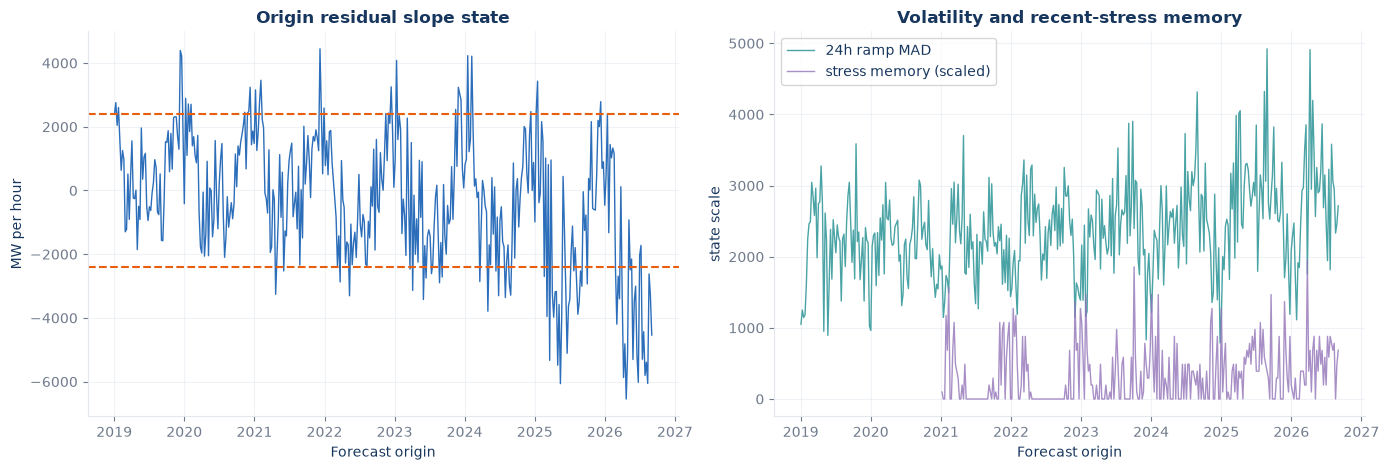

In [42]:
# -----------------------------------------------------------------
# Time semantics and forecast-origin integrity
# -----------------------------------------------------------------
# Question: which origin states change while a target-day clock remains fixed?
origin_state_plot = origin_control_state.dropna(
    subset=[
        "origin_control_residual_slope_6h_mw_per_h",
        "origin_control_ramp_mad_24h_mw",
    ]
).iloc[::7]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(
    origin_state_plot["forecast_origin_utc"],
    origin_state_plot["origin_control_residual_slope_6h_mw_per_h"],
    color=COLORS["blue"], linewidth=1,
)
axes[0].axhline(CONTROL_REGIME_THRESHOLDS["slope_abs_p90"], color=COLORS["orange"], linestyle="--")
axes[0].axhline(-CONTROL_REGIME_THRESHOLDS["slope_abs_p90"], color=COLORS["orange"], linestyle="--")
axes[0].set(title="Origin residual slope state", ylabel="MW per hour", xlabel="Forecast origin")
axes[1].plot(
    origin_state_plot["forecast_origin_utc"],
    origin_state_plot["origin_control_ramp_mad_24h_mw"],
    color=COLORS["teal"], linewidth=1, label="24h ramp MAD",
)
axes[1].plot(
    origin_state_plot["forecast_origin_utc"],
    origin_state_plot["origin_control_stress_memory_24h"]
    * origin_state_plot["origin_control_ramp_mad_24h_mw"].median(),
    color=COLORS["purple"], linewidth=1, alpha=.8,
    label="stress memory (scaled)",
)
axes[1].set(title="Volatility and recent-stress memory", ylabel="state scale", xlabel="Forecast origin")
axes[1].legend()
finish_figure(
    fig, "origin_control_state",
    "Which past-only sampled states describe slope, volatility and stress memory?"
)

### Declare feature families and provenance · 1/3

Family membership and availability precede model outcomes. Whole-record support is descriptive; feature selection later uses training-fold support only.

In [43]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
FEATURE_FAMILIES = OrderedDict([
    ("F0_CALENDAR", [
        "calendar_slot_index", "calendar_hour_raw", "calendar_dow_raw", "calendar_doy_raw",
        "calendar_month", "calendar_weekend", "calendar_holiday", "calendar_dst_day_steps",
        "calendar_fold_occurrence", "calendar_utc_offset_hours",
    ]),
    ("F1_TEMPORAL_GEOMETRY", [
        "calendar_slot_sin", "calendar_slot_cos", "calendar_dow_sin", "calendar_dow_cos",
        "calendar_doy_sin", "calendar_doy_cos", "calendar_hour_h2_sin", "calendar_hour_h2_cos",
    ]),
    ("F2_SAFE_PERSISTENCE", [
        "persistence_residual_lag_48h_mw", "persistence_residual_lag_168h_mw",
        "persistence_residual_lag_336h_mw", "persistence_weekly_median_mw",
        "persistence_weekly_mad_mw",
    ]),
    ("F3_ORIGIN_STATE", [
        "origin_residual_load_mw", "origin_load_mw", "origin_vre_mw", "origin_ramp_1h_mw",
    ]),
    ("F4_ROLLING_STATE", [
        *[f"rolling_residual_{stat}_{hours}h_mw" for hours in (24, 72, 168) for stat in ("mean", "std")],
        "history_support_count",
    ]),
    ("F5_PHYSICAL_HISTORY", [
        *[f"physical_{name}_lag_{hours}h_mw" for name in (
            "load", "wind_onshore", "wind_offshore", "solar"
        ) for hours in (48, 168)],
    ]),
    ("F6_D2_SHAPE", ["shape_d2_centered_mw", "shape_d2_ramp_1h_mw"]),
    ("S0_SCHEDULED_CALENDAR_EVENTS", [
        "calendar_christmas_eve", "calendar_new_years_eve", "calendar_year_end_window",
        "calendar_potential_bridge_day", "calendar_natural_long_weekend",
        "calendar_days_to_next_holiday_capped", "calendar_days_since_holiday_capped",
    ]),
    ("S1_DECLARED_SIGNAL_BASIS", [
        "calendar_hour_h3_sin", "calendar_hour_h3_cos",
        "calendar_week_h2_sin", "calendar_week_h2_cos",
    ]),
    ("S2_ORIGIN_SAFE_SPECTRAL_STATE", [
        "spectral_origin_weekly_energy_share", "spectral_origin_daily_energy_share",
        "spectral_origin_halfdaily_energy_share", "spectral_origin_eight_hour_energy_share",
        "spectral_origin_weekly_amplitude_mw", "spectral_origin_daily_amplitude_mw",
        "spectral_origin_daily_weekly_power_ratio",
        "spectral_origin_reconstruction_rmse_mw",
        "spectral_origin_entropy",
    ]),
    ("F10_SELECTED_INTERACTIONS", [
        "interaction_hour_x_season", "interaction_origin_vre_x_hour",
        "interaction_weekly_lag_x_weekend",
        "interaction_spectral_daily_amp_x_slot_sin",
        "interaction_spectral_daily_amp_x_slot_cos",
        "interaction_spectral_weekly_amp_x_dow_sin",
        "interaction_spectral_weekly_amp_x_dow_cos",
    ]),
    ("F9_ORIGIN_CONTROL_STATE", [
        "origin_control_vre_share", "origin_control_residual_ramp_1h_mw",
        "origin_control_load_ramp_1h_mw", "origin_control_vre_ramp_1h_mw",
        "origin_control_residual_slope_6h_mw_per_h",
        "origin_control_ramp_mad_24h_mw", "origin_control_stress_memory_24h",
        "origin_regime_fast_change", "origin_regime_high_variability",
        "origin_regime_recent_stress",
    ]),
    ("S4_CONTEXT_MODULATED_HARMONICS", CONTEXT_HARMONIC_FEATURES),
    ("S3_INTERVENTION_ADAPTATION", [
        "intervention_covid_disruption_step", "intervention_days_since_covid_disruption_log",
        "intervention_invasion_step", "intervention_days_since_invasion_log",
        "interaction_covid_x_daily_sin", "interaction_covid_x_daily_cos",
        "interaction_invasion_x_annual_cos",
    ]),
])

### Declare feature families and provenance · 2/3

Family membership and availability precede model outcomes. Whole-record support is descriptive; feature selection later uses training-fold support only.

In [44]:
# -----------------------------------------------------------------
# Time semantics and forecast-origin integrity
# -----------------------------------------------------------------
feature_rows = []
for family, names in FEATURE_FAMILIES.items():
    for name in names:
        if family in {"F0_CALENDAR", "F1_TEMPORAL_GEOMETRY"}:
            source, availability, revision_policy, initial_decision = (
                "calendar", "known at schedule creation", "not revised", "CORE"
            )
        elif family in {
            "S0_SCHEDULED_CALENDAR_EVENTS",
            "S1_DECLARED_SIGNAL_BASIS",
            "S4_CONTEXT_MODULATED_HARMONICS",
        }:
            source, availability, revision_policy, initial_decision = (
                "calendar-derived candidate", "known at schedule creation",
                "not revised; still requires forward-fold promotion", "EXPERIMENTAL",
            )
        elif name.startswith("spectral_"):
            source, availability, revision_policy, initial_decision = (
                "trailing residual history", "complete 28d UTC window + assumed 1h <= origin",
                "UNVERIFIED_CURRENT_EXTRACT", "EXPERIMENTAL",
            )
        elif name.startswith("intervention_"):
            source, availability, revision_policy, initial_decision = (
                "frozen external event ledger", "event announcement/observation <= origin",
                "single-event adaptation; no causal claim", "EXPERIMENTAL",
            )
        elif family == "F10_SELECTED_INTERACTIONS":
            source, availability, revision_policy, initial_decision = (
                "derived interaction", "all parents must be origin-eligible",
                "UNVERIFIED_CURRENT_EXTRACT via realized-history parent", "EXPERIMENTAL",
            )
        elif family == "S3_INTERVENTION_ADAPTATION":
            source, availability, revision_policy, initial_decision = (
                "derived event interaction", "event known by origin and calendar known ahead",
                "single-event adaptation; no causal claim", "EXPERIMENTAL",
            )
        elif "lag_" in name or name.startswith("shape_"):
            source, availability, revision_policy, initial_decision = (
                "realized history", "Berlin-local source event + assumed 1h <= origin",
                "UNVERIFIED_CURRENT_EXTRACT", "EXPERIMENTAL",
            )
        elif name.startswith(("origin_", "rolling_", "history_")):
            source, availability, revision_policy, initial_decision = (
                "origin snapshot", "latest event under assumed 1h latency <= origin",
                "UNVERIFIED_CURRENT_EXTRACT", "EXPERIMENTAL",
            )
        elif name.startswith("physical_"):
            source, availability, revision_policy, initial_decision = (
                "realized physical history", "Berlin-local source event + assumed 1h <= origin",
                "UNVERIFIED_CURRENT_EXTRACT", "EXPERIMENTAL",
            )
        else:
            source, availability, revision_policy, initial_decision = (
                "derived interaction", "all parent features must be origin-eligible",
                "inherits parent evidence status", "EXPERIMENTAL",
            )
        feature_rows.append({
            "feature": name, "family": family, "source": source,
            "event_or_valid_time": "target interval or historical source interval",
            "available_at_utc": availability, "revision_policy": revision_policy,
            "initial_decision": initial_decision,
        })
blocked_rows = [
    ("target_day_actuals", "TARGET_OUTCOME", "realized during target day", "REJECT_LEAKAGE"),
    ("unmasked_residual_lag_24h", "REALIZED_HISTORY", "not always available at origin", "REJECT_LEAKAGE"),
    ("centered_rolling_window", "TARGET_OUTCOME", "uses future values", "REJECT_LEAKAGE"),
    ("whole_data_quantile_state", "TARGET_OUTCOME", "validation distribution leaks", "REJECT_LEAKAGE"),
    ("full_record_fft_coefficients", "TARGET_OUTCOME", "future frequencies and amplitudes leak", "REJECT_LEAKAGE"),
    ("official_forecast_without_vintage", "F7_OFFICIAL_FORECAST", "issued_at/vintage unknown", "BLOCKED_OFFICIAL_FORECAST"),
    ("prior_forecast_error_without_archive", "F8_FORECAST_ERROR", "historical vintage unknown", "BLOCKED_OFFICIAL_FORECAST"),
    ("target_derived_regime", "F11_REGIME_RESEARCH", "defined by outcome", "RESEARCH_ONLY"),
    ("football_match_schedule", "F11_REGIME_RESEARCH", "five upstream matches are too sparse", "RESEARCH_ONLY"),
    ("realized_weather_event", "TARGET_OUTCOME", "future realized meteorology", "REJECT_LEAKAGE"),
    ("weather_forecast_without_vintage", "F7_OFFICIAL_FORECAST", "issued-at archive unavailable", "BLOCKED_OFFICIAL_FORECAST"),
    ("who_covid_pheic_context", "F11_REGIME_RESEARCH", "global context only", "RESEARCH_ONLY"),
    ("later_normalization_window", "F11_REGIME_RESEARCH", "reporting hypothesis", "RESEARCH_ONLY"),
]
for name, family, availability, decision in blocked_rows:
    feature_rows.append({
        "feature": name, "family": family, "source": "blocked or diagnostic",
        "event_or_valid_time": "unknown, target-derived, or analysis-only",
        "available_at_utc": availability, "revision_policy": "not qualified",
        "initial_decision": decision,
    })
feature_catalog = pd.DataFrame(feature_rows)
candidate_names = [name for names in FEATURE_FAMILIES.values() for name in names]
support = feature_matrix[candidate_names].notna().mean()
feature_catalog["support"] = feature_catalog["feature"].map(support)
display(feature_catalog)

,feature,family,source,event_or_valid_time,available_at_utc,revision_policy,initial_decision,support
0,calendar_slot_index,F0_CALENDAR,calendar,target interval or historical source interval,known at schedule creation,not revised,CORE,1.0
1,calendar_hour_raw,F0_CALENDAR,calendar,target interval or historical source interval,known at schedule creation,not revised,CORE,1.0
2,calendar_dow_raw,F0_CALENDAR,calendar,target interval or historical source interval,known at schedule creation,not revised,CORE,1.0
3,calendar_doy_raw,F0_CALENDAR,calendar,target interval or historical source interval,known at schedule creation,not revised,CORE,1.0
4,calendar_month,F0_CALENDAR,calendar,target interval or historical source interval,known at schedule creation,not revised,CORE,1.0
...,...,...,...,...,...,...,...,...
120,football_match_schedule,F11_REGIME_RESEARCH,blocked or diagnostic,"unknown, target-derived, or analysis-only",five upstream matches are too sparse,not qualified,RESEARCH_ONLY,NaN
121,realized_weather_event,TARGET_OUTCOME,blocked or diagnostic,"unknown, target-derived, or analysis-only",future realized meteorology,not qualified,REJECT_LEAKAGE,NaN
122,weather_forecast_without_vintage,F7_OFFICIAL_FORECAST,blocked or diagnostic,"unknown, target-derived, or analysis-only",issued-at archive unavailable,not qualified,BLOCKED_OFFICIAL_FORECAST,NaN
123,who_covid_pheic_context,F11_REGIME_RESEARCH,blocked or diagnostic,"unknown, target-derived, or analysis-only",global context only,not qualified,RESEARCH_ONLY,NaN


### Declare feature families and provenance · 3/3

Family membership and availability precede model outcomes. Whole-record support is descriptive; feature selection later uses training-fold support only.

In [45]:
# -----------------------------------------------------------------
# Grid-stress thresholds and regime construction
# -----------------------------------------------------------------
FEATURE_DESIGN_LEDGER = pd.DataFrame([
    {
        "question": "Which repeated calendar states are known before the target day?",
        "evidence": "upstream holiday EDA + scheduled-calendar geometry",
        "family": "S0_SCHEDULED_CALENDAR_EVENTS", "representation": "binary gates + capped counters",
        "dynamics": "static/schedule-known", "model_role": "promotion candidate",
    },
    {
        "question": "Which predeclared periods transfer beyond a raw clock?",
        "evidence": "upstream harmonics + forward representation race",
        "family": "S1_DECLARED_SIGNAL_BASIS", "representation": "paired harmonic sine/cosine basis; empirical Gram audit",
        "dynamics": "static/schedule-known", "model_role": "promotion candidate",
    },
    {
        "question": "Does recent periodic strength change at the forecast origin?",
        "evidence": "eligible 28-day spectrum + future-poison challenge",
        "family": "S2_ORIGIN_SAFE_SPECTRAL_STATE", "representation": "energy, amplitude, entropy",
        "dynamics": "dynamic/past-only", "model_role": "research; revision-unverified",
    },
    {
        "question": "Do observed shocks help adaptation after they are publicly known?",
        "evidence": "overlapping intervention clocks + forward folds",
        "family": "S3_INTERVENTION_ADAPTATION", "representation": "step, log clock, gated harmonics",
        "dynamics": "slow regime state", "model_role": "single-event research only",
    },
    {
        "question": "Can a compact sampled-data state describe changing operating conditions?",
        "evidence": "origin availability audit + frozen pre-2021 regime thresholds",
        "family": "F9_ORIGIN_CONTROL_STATE", "representation": "ramps, slope, VRE share, volatility, stress memory",
        "dynamics": "dynamic/past-only", "model_role": "promotion candidate; revision-unverified",
    },
    {
        "question": "Does daily phase interact with weekday and annual phase?",
        "evidence": "24 declared algebraic products + fold-local Gram audit",
        "family": "S4_CONTEXT_MODULATED_HARMONICS", "representation": "daily basis × weekly/annual context",
        "dynamics": "calendar-static", "model_role": "promotion candidate",
    },
    {
        "question": "Do component lead-lag patterns suggest admissible historical lags?",
        "evidence": "calendar-adjusted CCF + coherence",
        "family": "DIAGNOSTIC_ONLY", "representation": "lag/frequency association",
        "dynamics": "training-reference diagnostic", "model_role": "never direct feature selection",
    },
])
display(FEATURE_DESIGN_LEDGER)

,question,evidence,family,representation,dynamics,model_role
0,Which repeated calendar states are known befor...,upstream holiday EDA + scheduled-calendar geom...,S0_SCHEDULED_CALENDAR_EVENTS,binary gates + capped counters,static/schedule-known,promotion candidate
1,Which predeclared periods transfer beyond a ra...,upstream harmonics + forward representation race,S1_DECLARED_SIGNAL_BASIS,paired harmonic sine/cosine basis; empirical G...,static/schedule-known,promotion candidate
2,Does recent periodic strength change at the fo...,eligible 28-day spectrum + future-poison chall...,S2_ORIGIN_SAFE_SPECTRAL_STATE,"energy, amplitude, entropy",dynamic/past-only,research; revision-unverified
3,Do observed shocks help adaptation after they ...,overlapping intervention clocks + forward folds,S3_INTERVENTION_ADAPTATION,"step, log clock, gated harmonics",slow regime state,single-event research only
4,Can a compact sampled-data state describe chan...,origin availability audit + frozen pre-2021 re...,F9_ORIGIN_CONTROL_STATE,"ramps, slope, VRE share, volatility, stress me...",dynamic/past-only,promotion candidate; revision-unverified
5,Does daily phase interact with weekday and ann...,24 declared algebraic products + fold-local Gr...,S4_CONTEXT_MODULATED_HARMONICS,daily basis × weekly/annual context,calendar-static,promotion candidate
6,Do component lead-lag patterns suggest admissi...,calendar-adjusted CCF + coherence,DIAGNOSTIC_ONLY,lag/frequency association,training-reference diagnostic,never direct feature selection


### Audit vintage and event-time eligibility · 1/3

A source value can pass an assumed event-time gate and still lack historical revision/vintage evidence. Preserve that distinction in every downstream decision.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [46]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def extract_official_forecast_gate(
    raw_frame: pd.DataFrame, target_frame: pd.DataFrame,
    archive_verified: bool | None = None,
) -> tuple[str, pd.DataFrame, dict]:
    if archive_verified is None:
        archive_verified = os.environ.get("GRIDSTRESS_OFFICIAL_ARCHIVE_VERIFIED", "0") == "1"
    normalized = {normalized_label(column): column for column in raw_frame.columns}
    required_aliases = {
        "forecast_mw": ("official_forecast_residual_load_mw", "official_residual_load_forecast_mw"),
        "valid_time_utc": ("official_forecast_valid_time_utc", "forecast_valid_time_utc"),
        "issued_at_utc": ("official_forecast_issued_at_utc", "forecast_issued_at_utc"),
        "vintage_id": ("official_forecast_vintage_id", "forecast_vintage_id"),
        "archive_snapshot_id": (
            "official_forecast_archive_snapshot_id", "forecast_archive_snapshot_id"
        ),
    }
    resolved = {}
    for field, aliases in required_aliases.items():
        resolved[field] = next((normalized[normalized_label(alias)] for alias in aliases
                                if normalized_label(alias) in normalized), None)
    target_keys = target_frame[["target_time_utc", "forecast_origin_utc"]].drop_duplicates().copy()
    target_keys["target_date_local"] = pd.to_datetime(
        target_keys["target_time_utc"].dt.tz_convert(TZ_NAME).dt.date
    )
    required_targets = int(len(target_keys))
    if any(value is None for value in resolved.values()):
        return "BLOCKED_OFFICIAL_FORECAST", pd.DataFrame(), {
            "required_targets": required_targets, "qualified_targets": 0,
            "overall_coverage": 0.0, "minimum_day_coverage": 0.0,
            "archive_verified": bool(archive_verified),
            "reason": "required valid-time / issued-at / vintage / archive-snapshot columns missing",
        }
    official = pd.DataFrame({
        "target_time_utc": pd.to_datetime(raw_frame[resolved["valid_time_utc"]], utc=True, errors="coerce"),
        "issued_at_utc": pd.to_datetime(raw_frame[resolved["issued_at_utc"]], utc=True, errors="coerce"),
        "official_forecast_mw": pd.to_numeric(raw_frame[resolved["forecast_mw"]], errors="coerce"),
        "vintage_id": raw_frame[resolved["vintage_id"]].astype("string"),
        "archive_snapshot_id": raw_frame[resolved["archive_snapshot_id"]].astype("string"),
    }).dropna(subset=["target_time_utc"])
    joined = target_keys.merge(
        official, on="target_time_utc", how="left", validate="one_to_many"
    )
    eligible = joined.loc[
        joined["issued_at_utc"].notna()
        & joined["vintage_id"].notna()
        & joined["archive_snapshot_id"].notna()
        & np.isfinite(joined["official_forecast_mw"])
        & joined["vintage_id"].str.strip().ne("").fillna(False)
        & joined["archive_snapshot_id"].str.strip().ne("").fillna(False)
        & (joined["issued_at_utc"] <= joined["forecast_origin_utc"])
    ].copy()
    conflicting_releases = (
        eligible.groupby(["target_time_utc", "issued_at_utc"])["official_forecast_mw"]
        .nunique().gt(1)
    )
    if conflicting_releases.any():
        raise ValueError(
            "Official archive contains conflicting values for the same target and release time; "
            "resolve the vintage provenance before admitting it."
        )
    selected = eligible.sort_values(
        ["issued_at_utc", "vintage_id", "archive_snapshot_id"]
    ).drop_duplicates("target_time_utc", keep="last")
    coverage = selected["target_time_utc"].nunique() / max(1, required_targets)
    required_by_day = target_keys.groupby("target_date_local").size()
    qualified_by_day = selected.groupby("target_date_local").size()
    day_coverage = (
        (qualified_by_day / required_by_day)
        .reindex(required_by_day.index)
        .fillna(0.0)
    )
    minimum_day_coverage = float(day_coverage.min()) if len(day_coverage) else 0.0
    qualified = bool(
        archive_verified
        and coverage == 1.0
        and minimum_day_coverage == 1.0
        and selected["target_time_utc"].is_unique
    )
    status = "QUALIFIED_OFFICIAL_FORECAST" if qualified else "BLOCKED_OFFICIAL_FORECAST"
    if not archive_verified:
        reason = "immutable historical archive not independently verified"
    elif coverage < 1.0 or minimum_day_coverage < 1.0:
        reason = "incomplete eligible historical-vintage coverage"
    else:
        reason = "complete, independently verified historical-vintage coverage"
    audit = {
        "required_targets": required_targets,
        "qualified_targets": int(selected["target_time_utc"].nunique()),
        "overall_coverage": float(coverage),
        "minimum_day_coverage": minimum_day_coverage,
        "archive_verified": bool(archive_verified),
        "archive_snapshots": int(selected["archive_snapshot_id"].nunique()),
        "reason": reason,
    }
    return status, selected, audit

### Audit vintage and event-time eligibility · 2/3

A source value can pass an assumed event-time gate and still lack historical revision/vintage evidence. Preserve that distinction in every downstream decision.

In [47]:
# -----------------------------------------------------------------
# Time semantics and forecast-origin integrity
# -----------------------------------------------------------------
official_forecast_status, official_forecast_frame, official_forecast_gate_audit = (
    extract_official_forecast_gate(raw, feature_matrix)
)
if official_forecast_status == "QUALIFIED_OFFICIAL_FORECAST":
    feature_matrix = merge_feature_block(feature_matrix,
        official_forecast_frame[["target_time_utc", "official_forecast_mw"]], key="target_time_utc")
else:
    feature_matrix["official_forecast_mw"] = np.nan
print("Official forecast gate:", official_forecast_status)
print("Official forecast audit:", official_forecast_gate_audit)

Official forecast gate: BLOCKED_OFFICIAL_FORECAST
Official forecast audit: {'required_targets': 67391, 'qualified_targets': 0, 'overall_coverage': 0.0, 'minimum_day_coverage': 0.0, 'archive_verified': False, 'reason': 'required valid-time / issued-at / vintage / archive-snapshot columns missing'}


### Audit vintage and event-time eligibility · 3/3

A source value can pass an assumed event-time gate and still lack historical revision/vintage evidence. Preserve that distinction in every downstream decision.

In [48]:
# -----------------------------------------------------------------
# Dependencies and reproducible environment
# -----------------------------------------------------------------
d2_source_available = feature_matrix["persistence_source_time_48h_utc"] + DATA_PUBLICATION_LATENCY
d2_mask = d2_source_available.notna()
REVISION_VINTAGE_GATE = "UNVERIFIED_CURRENT_EXTRACT"
leakage_audit = pd.DataFrame([
    {"check": "target strictly after origin", "passed": bool((feature_matrix["target_time_utc"] > feature_matrix["forecast_origin_utc"]).all())},
    {"check": "Berlin-local D-2 source event published by origin under assumed latency", "passed": bool((d2_source_available.loc[d2_mask] <= feature_matrix.loc[d2_mask, "forecast_origin_utc"]).all())},
    {"check": "origin snapshot published by origin", "passed": bool((feature_matrix["available_at_utc"].dropna() <= feature_matrix.loc[feature_matrix["available_at_utc"].notna(), "forecast_origin_utc"]).all())},
    {"check": "target absent from candidate names", "passed": not any(name in LEAKAGE_BLOCKLIST for names in FEATURE_FAMILIES.values() for name in names)},
    {"check": "unique target timestamps", "passed": bool(feature_matrix["target_time_utc"].is_unique)},
    {"check": "complete scored target profiles", "passed": bool(feature_matrix.groupby("target_date_local").size().eq(feature_matrix.groupby("target_date_local")["calendar_dst_day_steps"].first()).all())},
    {"check": "official forecast qualified or blocked", "passed": official_forecast_status in {"QUALIFIED_OFFICIAL_FORECAST", "BLOCKED_OFFICIAL_FORECAST"}},
    {"check": "signal feature timing audit", "passed": bool(signal_feature_timing_audit["passed"].all())},
])
if not leakage_audit["passed"].all():
    raise AssertionError(leakage_audit.loc[~leakage_audit["passed"]].to_dict("records"))
display(leakage_audit)

,check,passed
0,target strictly after origin,True
1,Berlin-local D-2 source event published by ori...,True
2,origin snapshot published by origin,True
3,target absent from candidate names,True
4,unique target timestamps,True
5,complete scored target profiles,True
6,official forecast qualified or blocked,True
7,signal feature timing audit,True


### Official forecast feature gate and driver decomposition

**Question:** can an official forecast be an honest feature?

Yes—only when its valid time, issued-at time, immutable vintage and archive snapshot
prove that the exact value was visible at the forecast origin. A residual-only
forecast may benchmark B2, but it cannot support claims about load/wind/solar drivers.
Component driver features require separately archived component forecasts. The table
below keeps that distinction explicit; missing components remain blocked rather than
silently becoming zeros.


### Keep official component forecasts gated

Inspect the stated units, time range and support before interpreting the resulting table or figure.

In [49]:
# -----------------------------------------------------------------
# Dependencies and reproducible environment
# -----------------------------------------------------------------
OFFICIAL_COMPONENT_CONTRACT = pd.DataFrame([
    {
        "candidate": "official residual forecast level / ramp / tail margin",
        "required_archive": "residual valid-time series + issued_at + vintage + snapshot",
        "status": official_forecast_status,
        "feature_role": "B2 benchmark and optional correction parent",
    },
    {
        "candidate": "load/wind/solar signed driver contributions",
        "required_archive": "component valid-time series under the same immutable vintage",
        "status": "BLOCKED_COMPONENT_FORECASTS_NOT_QUALIFIED",
        "feature_role": "driver dominance and cancellation only after qualification",
    },
    {
        "candidate": "prior forecast innovation feedback",
        "required_archive": "historical forecast actually visible at the prior origin",
        "status": (
            "QUALIFIED" if official_forecast_status == "QUALIFIED_OFFICIAL_FORECAST"
            else "BLOCKED_NO_HISTORICAL_VINTAGE"
        ),
        "feature_role": "past-only feedback; never reconstructed from a current archive",
    },
])
official_feature_columns = [
    "official_forecast_mw",
    "official_forecast_ramp_1h_mw",
    "official_forecast_upper_margin_mw",
    "official_forecast_lower_margin_mw",
    "official_forecast_lead_age_hours",
    "official_forecast_driver_dominance",
    "official_forecast_driver_cancellation",
]
if official_forecast_status == "QUALIFIED_OFFICIAL_FORECAST":
    feature_matrix["official_forecast_ramp_1h_mw"] = exact_time_delta(
        feature_matrix["official_forecast_mw"],
        feature_matrix["target_time_utc"],
        hours=1,
    )
    feature_matrix["official_forecast_upper_margin_mw"] = (
        STRESS_THRESHOLDS["residual_p95_mw"]
        - feature_matrix["official_forecast_mw"]
    )
    feature_matrix["official_forecast_lower_margin_mw"] = (
        feature_matrix["official_forecast_mw"]
        - STRESS_THRESHOLDS["residual_p05_mw"]
    )
    feature_matrix["official_forecast_lead_age_hours"] = (
        feature_matrix["target_time_utc"]
        - feature_matrix["forecast_origin_utc"]
    ).dt.total_seconds() / 3600
display(OFFICIAL_COMPONENT_CONTRACT)

,candidate,required_archive,status,feature_role
0,official residual forecast level / ramp / tail...,residual valid-time series + issued_at + vinta...,BLOCKED_OFFICIAL_FORECAST,B2 benchmark and optional correction parent
1,load/wind/solar signed driver contributions,component valid-time series under the same imm...,BLOCKED_COMPONENT_FORECASTS_NOT_QUALIFIED,driver dominance and cancellation only after q...
2,prior forecast innovation feedback,historical forecast actually visible at the pr...,BLOCKED_NO_HISTORICAL_VINTAGE,past-only feedback; never reconstructed from a...


### Show source-admission decisions

Inspect the stated units, time range and support before interpreting the resulting table or figure.

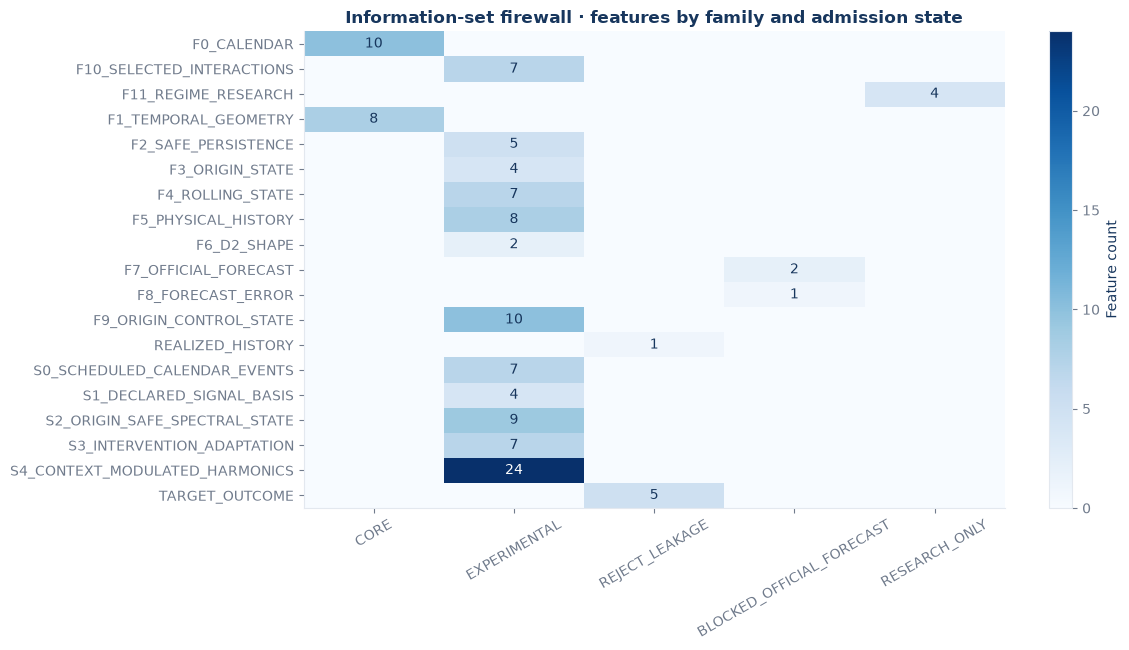

In [50]:
# -----------------------------------------------------------------
# Feature construction, lineage, and scientific evidence
# -----------------------------------------------------------------
decision_order = ["CORE", "EXPERIMENTAL", "REJECT_LEAKAGE", "BLOCKED_OFFICIAL_FORECAST", "RESEARCH_ONLY"]
firewall = feature_catalog.groupby(["family", "initial_decision"], as_index=False).agg(
    feature_count=("feature", "size"), support=("support", "median")
)
families = firewall["family"].unique().tolist()
matrix = np.full((len(families), len(decision_order)), np.nan)
for row in firewall.itertuples(index=False):
    matrix[families.index(row.family), decision_order.index(row.initial_decision)] = row.feature_count
fig, ax = plt.subplots(figsize=(12, 6.6))
image = ax.imshow(np.nan_to_num(matrix), cmap="Blues", aspect="auto")
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        if np.isfinite(matrix[i, j]) and matrix[i, j] > 0:
            ax.text(j, i, f"{int(matrix[i, j])}", ha="center", va="center",
                    color="white" if matrix[i, j] > np.nanmax(matrix) * .45 else COLORS["ink"])
ax.set(xticks=range(len(decision_order)), xticklabels=decision_order,
       yticks=range(len(families)), yticklabels=families,
       title="Information-set firewall · features by family and admission state")
ax.tick_params(axis="x", rotation=30)
ax.grid(False)
fig.colorbar(image, ax=ax, label="Feature count")
finish_figure(fig, "information_set_firewall", "Which tempting predictors are actually knowable at origin?")

### Inspect a valid past-only spectral window

Inspect the stated units, time range and support before interpreting the resulting table or figure.

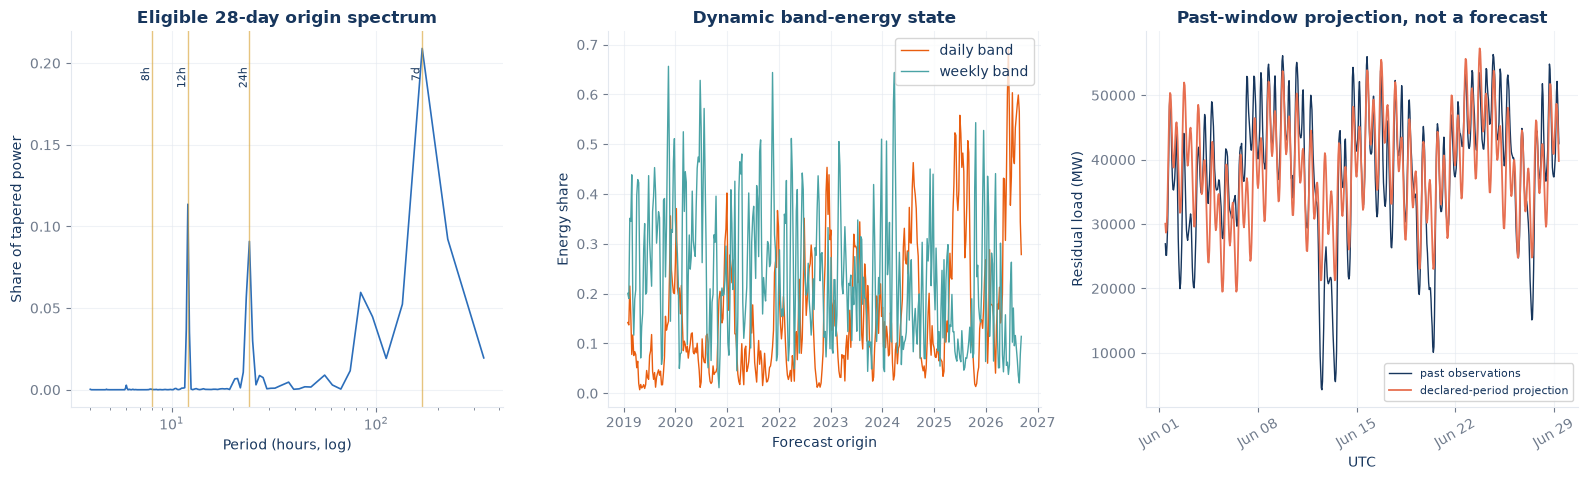

In [51]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
# Question: which frequencies remain visible in a strictly past-only origin window?
origin_spectral = feature_matrix.drop_duplicates("forecast_origin_utc").sort_values("forecast_origin_utc")
first_train_end = pd.Timestamp(fold_specification.iloc[0]["train_end_local"]).date()
eligible_reference = origin_spectral.loc[
    origin_spectral["spectral_window_valid"].fillna(False)
    & (pd.to_datetime(origin_spectral["target_date_local"]).dt.date <= first_train_end)
]
if eligible_reference.empty:
    raise ValueError("No eligible origin spectrum exists before the first validation fold.")
reference_state = eligible_reference.iloc[-1]
reference_window = labeled.loc[
    labeled["event_time_utc"].between(
        reference_state["spectral_source_start_utc"],
        reference_state["spectral_source_end_utc"], inclusive="both"
    ), ["event_time_utc", "residual_load_mw"]
].copy()
reference_values = reference_window["residual_load_mw"].to_numpy(float)
reference_axis = np.linspace(-1.0, 1.0, len(reference_values))
reference_design = np.column_stack([np.ones(len(reference_values)), reference_axis])
reference_detrended = reference_values - reference_design @ np.linalg.lstsq(
    reference_design, reference_values, rcond=None
)[0]
reference_taper = np.hanning(len(reference_values))
reference_fft = np.fft.rfft(reference_detrended * reference_taper)
reference_frequency = np.fft.rfftfreq(len(reference_values), d=CADENCE_MINUTES / 60)
reference_power = np.abs(reference_fft) ** 2
reference_period = np.divide(
    1.0, reference_frequency, out=np.full_like(reference_frequency, np.nan),
    where=reference_frequency > 0,
)
reference_reconstruction = np.zeros_like(reference_values)
elapsed_hours = np.arange(len(reference_values)) * CADENCE_MINUTES / 60
projection_columns = [np.ones(len(reference_values)), reference_axis]
for period_hours in (168.0, 24.0, 12.0, 8.0):
    projection_columns.extend([
        np.sin(2 * np.pi * elapsed_hours / period_hours),
        np.cos(2 * np.pi * elapsed_hours / period_hours),
    ])
projection_design = np.column_stack(projection_columns)
reference_reconstruction = projection_design @ np.linalg.lstsq(
    projection_design, reference_values, rcond=None
)[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.9))
spectrum_mask = (
    np.isfinite(reference_period) & (reference_period >= 4) & (reference_period <= 336)
)
normalized_power = reference_power / max(reference_power[1:].sum(), 1e-12)
axes[0].plot(reference_period[spectrum_mask], normalized_power[spectrum_mask],
             color=COLORS["blue"], linewidth=1.2)
for label, period in [("8h", 8), ("12h", 12), ("24h", 24), ("7d", 168)]:
    axes[0].axvline(period, color=COLORS["gold"], alpha=.65, linewidth=1)
    axes[0].text(period, axes[0].get_ylim()[1] * .90, label, rotation=90,
                 ha="right", va="top", fontsize=8)
axes[0].set_xscale("log")
axes[0].set(title="Eligible 28-day origin spectrum", xlabel="Period (hours, log)",
            ylabel="Share of tapered power")

origin_weekly = origin_spectral.iloc[::7].copy()
axes[1].plot(origin_weekly["forecast_origin_utc"],
             origin_weekly["spectral_origin_daily_energy_share"],
             label="daily band", color=COLORS["orange"], linewidth=1)
axes[1].plot(origin_weekly["forecast_origin_utc"],
             origin_weekly["spectral_origin_weekly_energy_share"],
             label="weekly band", color=COLORS["teal"], linewidth=1)
axes[1].set(title="Dynamic band-energy state", xlabel="Forecast origin", ylabel="Energy share")
axes[1].legend()

plot_stride = max(1, len(reference_window) // 450)
axes[2].plot(reference_window["event_time_utc"].iloc[::plot_stride],
             reference_values[::plot_stride], color=COLORS["ink"], linewidth=1, label="past observations")
axes[2].plot(reference_window["event_time_utc"].iloc[::plot_stride],
             reference_reconstruction[::plot_stride], color=COLORS["coral"], linewidth=1.3,
             label="declared-period projection")
axes[2].set(title="Past-window projection, not a forecast", xlabel="UTC", ylabel="Residual load (MW)")
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend(fontsize=8)
finish_figure(fig, "origin_window_spectral_evidence", "Which periodic strengths are knowable at each forecast origin?")

### FFT and Welch discover; harmonic regression fits

**Question:** do two spectral estimators agree on dominant periods, and what signed
coefficients reconstruct the declared waves?

The FFT periodogram has the native resolution of the full eligible window. Welch
trades resolution for lower variance by averaging overlapping segments. Neither
method estimates a regression coefficient. The subsequent least-squares fit returns
sine and cosine coefficients, amplitude and phase for declared periods.


### Compare spectral discovery and harmonic fitting

Inspect the stated units, time range and support before interpreting the resulting table or figure.

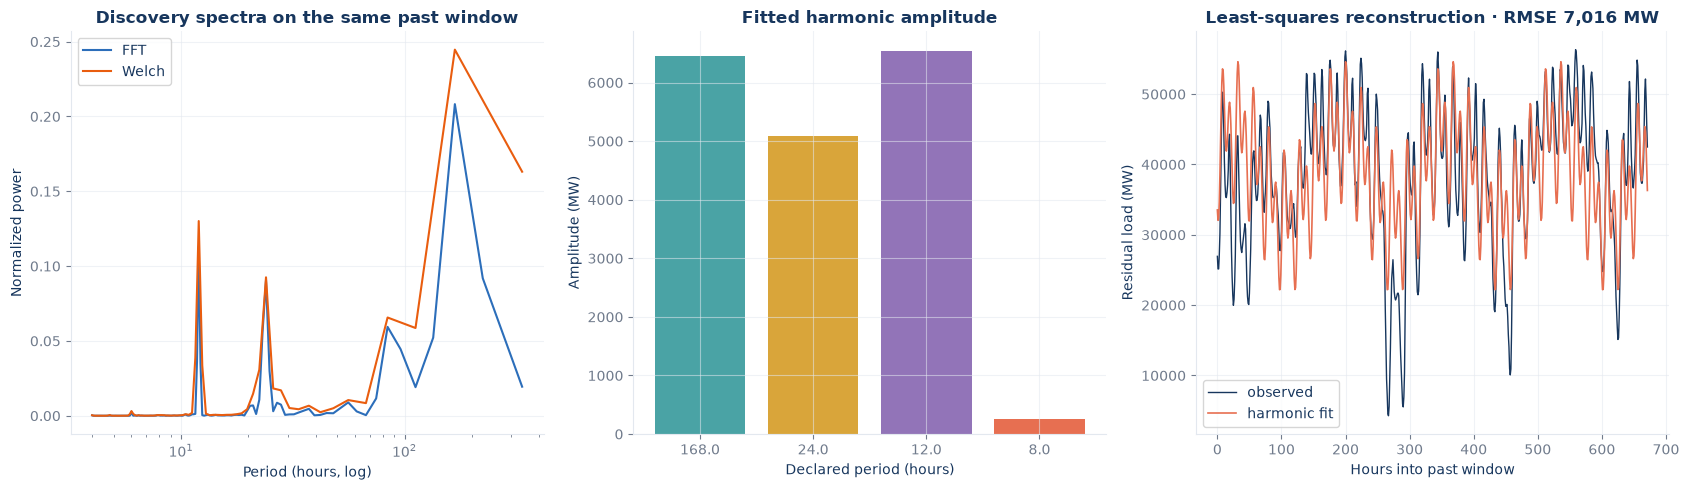

,method,frequency_per_hour,period_hours,normalized_power,frequency_resolution_per_hour,near_168h,near_24h,near_12h,near_8h
0,FFT,0.005952,168.000000,0.208227,0.001488,True,False,False,False
1,FFT,0.083333,12.000000,0.113150,0.001488,False,False,True,False
2,FFT,0.041667,24.000000,0.090544,0.001488,False,True,False,False
3,FFT,0.011905,84.000000,0.059388,0.001488,False,False,False,False
4,FFT,0.017857,56.000000,0.008921,0.001488,False,False,False,False
...,...,...,...,...,...,...,...,...,...
19,Welch,0.095238,10.500000,0.001032,0.002976,False,False,False,False
20,Welch,0.071429,14.000000,0.000623,0.002976,False,False,False,False
21,Welch,0.208333,4.800000,0.000427,0.002976,False,False,False,False
22,Welch,0.122024,8.195122,0.000423,0.002976,False,False,False,True


,period_hours,sin_coef,cos_coef,amplitude,phase_radians,fit_window_start_utc,fit_window_end_utc
0,168.0,5171.106757,3854.396389,6449.551660,0.640532,2021-06-01 10:00:00+00:00,2021-06-29 09:00:00+00:00
1,24.0,707.777354,-5030.734793,5080.279652,-1.431023,2021-06-01 10:00:00+00:00,2021-06-29 09:00:00+00:00
2,12.0,-5131.161974,-4066.361770,6547.069669,-2.471452,2021-06-01 10:00:00+00:00,2021-06-29 09:00:00+00:00
3,8.0,96.357830,233.519417,252.618585,1.179447,2021-06-01 10:00:00+00:00,2021-06-29 09:00:00+00:00


In [52]:
# -----------------------------------------------------------------
# Dependencies and reproducible environment
# -----------------------------------------------------------------
from scipy.signal import find_peaks, welch

sample_hours = CADENCE_MINUTES / 60.0
fft_frequency = reference_frequency
fft_density = reference_power / max(reference_power.sum(), 1e-12)
welch_segment = min(len(reference_detrended), 14 * 24 * PERIODS_PER_HOUR)
welch_frequency, welch_power = welch(
    reference_detrended,
    fs=PERIODS_PER_HOUR,
    window="hann",
    nperseg=welch_segment,
    noverlap=welch_segment // 2,
    detrend="linear",
    scaling="spectrum",
)
welch_density = welch_power / max(welch_power.sum(), 1e-12)


# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def strongest_periods(
    frequencies: np.ndarray, power: np.ndarray, method: str, top_n: int = 12
) -> pd.DataFrame:
    periods = np.divide(
        1.0, frequencies,
        out=np.full_like(frequencies, np.nan), where=frequencies > 0
    )
    mask = np.isfinite(periods) & periods.between(4.0, 336.0) if isinstance(periods, pd.Series) else (
        np.isfinite(periods) & (periods >= 4.0) & (periods <= 336.0)
    )
    candidates = np.flatnonzero(mask)
    if len(candidates) == 0:
        return pd.DataFrame()
    local_peaks, _ = find_peaks(power[candidates])
    peak_positions = candidates[local_peaks] if len(local_peaks) else candidates
    selected = peak_positions[np.argsort(power[peak_positions])[-top_n:]][::-1]
    resolution = float(np.median(np.diff(frequencies))) if len(frequencies) > 1 else np.nan
    return pd.DataFrame({
        "method": method,
        "frequency_per_hour": frequencies[selected],
        "period_hours": periods[selected],
        "normalized_power": power[selected],
        "frequency_resolution_per_hour": resolution,
    })

fft_peaks = strongest_periods(fft_frequency, fft_density, "FFT")
welch_peaks = strongest_periods(welch_frequency, welch_density, "Welch")
spectral_peak_table = pd.concat([fft_peaks, welch_peaks], ignore_index=True)
for period in SPECTRAL_PERIODS_HOURS.values():
    spectral_peak_table[f"near_{period:g}h"] = (
        (spectral_peak_table["period_hours"] - period).abs() / period <= .08
    )

harmonic_prediction, harmonic_coefficient_table = fit_harmonic_projection(
    elapsed_hours,
    reference_values,
    elapsed_hours,
    periods_hours=list(SPECTRAL_PERIODS_HOURS.values()),
)
harmonic_coefficient_table["fit_window_start_utc"] = reference_window["event_time_utc"].min()
harmonic_coefficient_table["fit_window_end_utc"] = reference_window["event_time_utc"].max()
harmonic_fit_rmse_mw = float(
    np.sqrt(np.mean((harmonic_prediction - reference_values) ** 2))
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.0))
fft_period = np.divide(
    1.0, fft_frequency,
    out=np.full_like(fft_frequency, np.nan), where=fft_frequency > 0
)
welch_period = np.divide(
    1.0, welch_frequency,
    out=np.full_like(welch_frequency, np.nan), where=welch_frequency > 0
)
fft_mask = np.isfinite(fft_period) & (fft_period >= 4) & (fft_period <= 336)
welch_mask = np.isfinite(welch_period) & (welch_period >= 4) & (welch_period <= 336)
axes[0].plot(fft_period[fft_mask], fft_density[fft_mask], label="FFT", color=COLORS["blue"])
axes[0].plot(welch_period[welch_mask], welch_density[welch_mask], label="Welch", color=COLORS["orange"])
axes[0].set_xscale("log")
axes[0].set(title="Discovery spectra on the same past window", xlabel="Period (hours, log)", ylabel="Normalized power")
axes[0].legend()
axes[1].bar(
    harmonic_coefficient_table["period_hours"].astype(str),
    harmonic_coefficient_table["amplitude"],
    color=[COLORS["teal"], COLORS["gold"], COLORS["purple"], COLORS["coral"]],
)
axes[1].set(title="Fitted harmonic amplitude", xlabel="Declared period (hours)", ylabel="Amplitude (MW)")
stride = max(1, len(reference_values) // 450)
axes[2].plot(elapsed_hours[::stride], reference_values[::stride], color=COLORS["ink"], linewidth=1, label="observed")
axes[2].plot(elapsed_hours[::stride], harmonic_prediction[::stride], color=COLORS["coral"], linewidth=1.2, label="harmonic fit")
axes[2].set(title=f"Least-squares reconstruction · RMSE {harmonic_fit_rmse_mw:,.0f} MW", xlabel="Hours into past window", ylabel="Residual load (MW)")
axes[2].legend()
finish_figure(
    fig, "fft_welch_harmonic_fit",
    "Which frequencies are discovered, and what amplitude/phase is actually fitted?"
)
display(spectral_peak_table)
display(harmonic_coefficient_table)

#### Where FFT helps—and where it stops

| Tool | Legitimate use here | Output usable as a feature? | Failure boundary |
|---|---|---|---|
| Full-window FFT | Discover candidate periods on training-only data | No direct coefficient | Leaks if computed across validation; assumes one stationary window |
| Welch | Confirm broad peaks with lower variance | No direct coefficient | Smears close frequencies and does not retain phase |
| Harmonic regression | Estimate signed sine/cosine weights at declared periods | Yes, when fitted inside each fold | Fixed periods cannot follow transient frequency drift |
| Rolling FFT state | Summarise recent band strength at the origin | Yes, if trailing and availability-gated | Short windows limit frequency resolution |
| ACF/PACF | Suggest memory horizons in the time domain | Lags become candidates, not automatic truth | Seasonal peaks and deterministic calendar effects can confound |
| Laplace transform | Conceptual block/transfer-function vocabulary | No | Observational, sampled, nonlinear and time-varying data do not identify G(s) |


### Inspect schedule-known special-day features

Inspect the stated units, time range and support before interpreting the resulting table or figure.

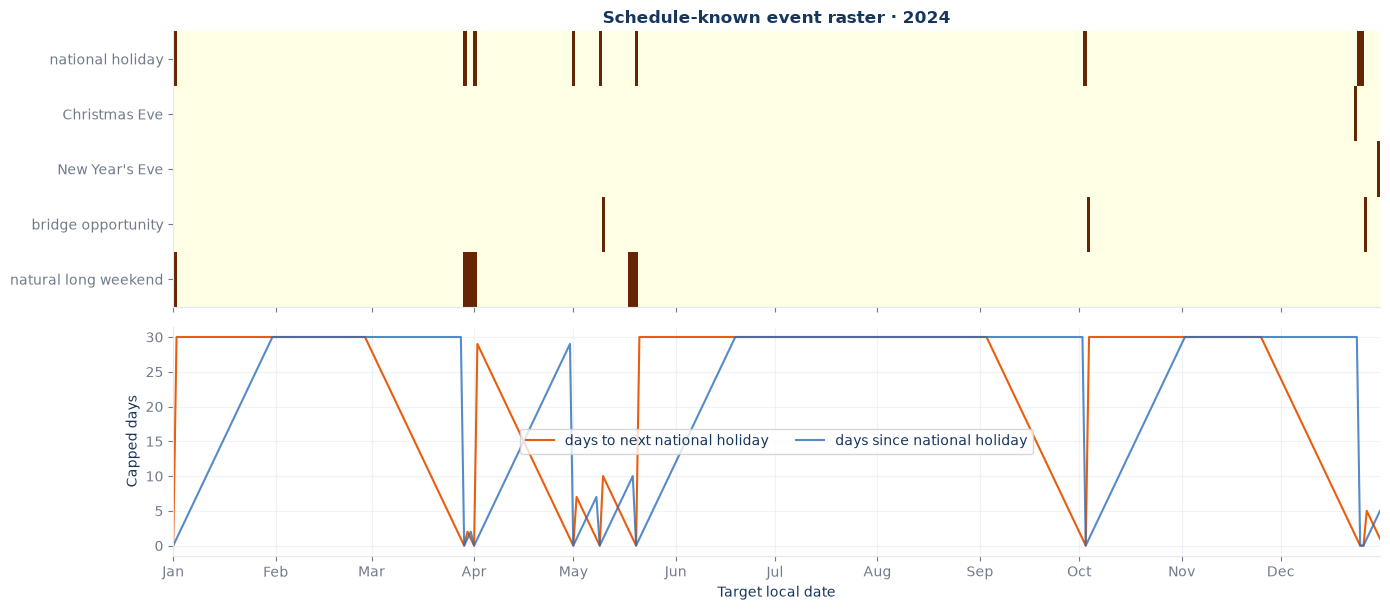

In [53]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------
# Question: which special-day geometries repeat and are completely knowable at origin?
calendar_daily = feature_matrix.drop_duplicates("target_date_local").sort_values("target_date_local")
available_years = sorted(pd.to_datetime(calendar_daily["target_date_local"]).dt.year.unique())
example_year = 2024 if 2024 in available_years else available_years[-1]
calendar_example = calendar_daily.loc[
    pd.to_datetime(calendar_daily["target_date_local"]).dt.year.eq(example_year)
].copy()
flag_columns = [
    "calendar_holiday", "calendar_christmas_eve", "calendar_new_years_eve",
    "calendar_potential_bridge_day", "calendar_natural_long_weekend",
]
flag_labels = ["national holiday", "Christmas Eve", "New Year's Eve", "bridge opportunity", "natural long weekend"]
date_numbers = mdates.date2num(pd.to_datetime(calendar_example["target_date_local"]))
fig, axes = plt.subplots(2, 1, figsize=(14, 6.2), sharex=True, gridspec_kw={"height_ratios": [1.2, 1]})
axes[0].imshow(
    calendar_example[flag_columns].to_numpy(float).T, aspect="auto", interpolation="nearest",
    cmap="YlOrBr", vmin=0, vmax=1,
    extent=[date_numbers.min(), date_numbers.max(), len(flag_columns) - .5, -.5],
)
axes[0].set(yticks=range(len(flag_labels)), yticklabels=flag_labels,
            title=f"Schedule-known event raster · {example_year}")
axes[0].grid(False)
axes[1].plot(calendar_example["target_date_local"],
             calendar_example["calendar_days_to_next_holiday_capped"],
             label="days to next national holiday", color=COLORS["orange"])
axes[1].plot(calendar_example["target_date_local"],
             calendar_example["calendar_days_since_holiday_capped"],
             label="days since national holiday", color=COLORS["blue"], alpha=.8)
axes[1].set(ylabel="Capped days", xlabel="Target local date")
axes[1].legend(ncol=2)
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
finish_figure(fig, "scheduled_calendar_geometry", "Which special-day patterns repeat and are known before the forecast origin?")

### Audit research intervention clocks

Inspect the stated units, time range and support before interpreting the resulting table or figure.

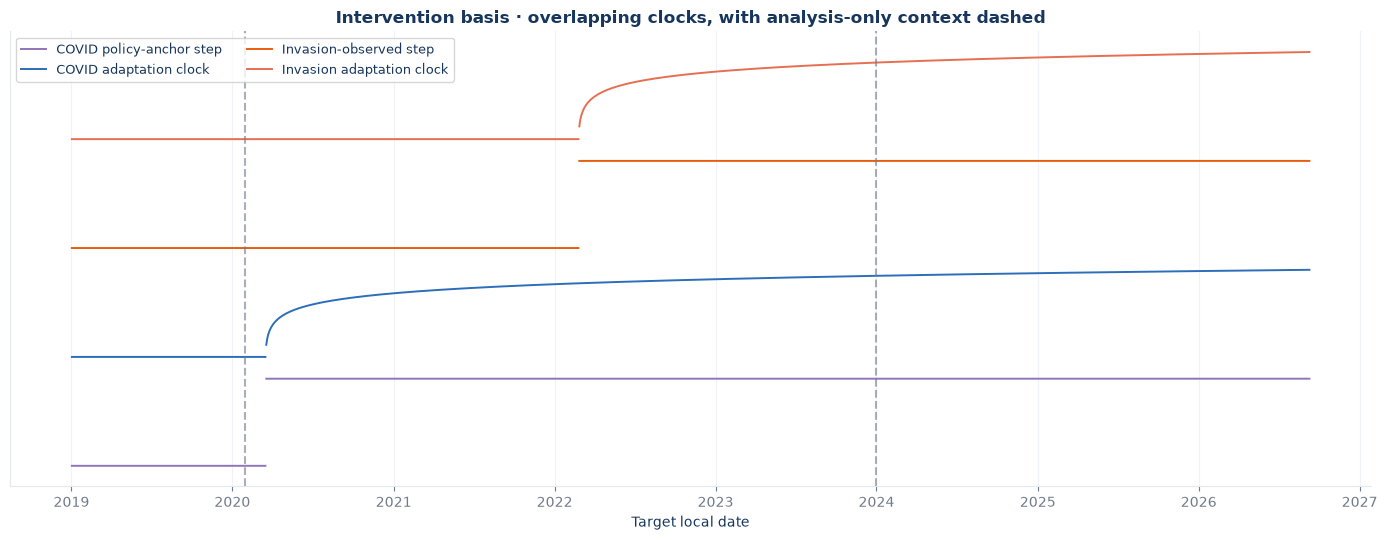

,event_id,start_utc,end_utc,known_at_utc,role,scope
0,who_covid_pheic_context,2020-01-30 00:00:00+00:00,2023-05-05 23:59:59+00:00,2020-01-30 23:59:59+00:00,analysis_only,global health context
1,covid_policy_disruption_anchor_de,2020-03-16 00:00:00+00:00,NaT,2020-03-16 23:59:59+00:00,research_adaptation,German policy disruption anchor
2,invasion_observed_2022,2022-02-24 00:00:00+00:00,NaT,2022-02-24 23:59:59+00:00,research_adaptation,observed external shock anchor
3,later_normalization_window,2024-01-01 00:00:00+00:00,NaT,2024-01-01 00:00:00+00:00,analysis_only,neutral reporting hypothesis


,period_id,start_date,end_date,model_role
0,pre_disruption_reference,2019-01-01,2020-03-15,analysis_only
1,pandemic_disruption,2020-03-16,2022-02-23,analysis_only
2,pandemic_energy_shock_overlap,2022-02-24,2023-12-31,analysis_only
3,later_normalization_window,2024-01-01,NaN,analysis_only


In [54]:
# -----------------------------------------------------------------
# Time semantics and forecast-origin integrity
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Model evidence
# -----------------------------------------------------------------
# Question: which event encodings are model candidates, and which remain reporting context?
daily_basis = feature_matrix.drop_duplicates("target_date_local").sort_values("target_date_local")
fig, ax = plt.subplots(figsize=(14, 5.5))
series_to_plot = [
    ("intervention_covid_disruption_step", "COVID policy-anchor step", COLORS["purple"]),
    ("intervention_days_since_covid_disruption_log", "COVID adaptation clock", COLORS["blue"]),
    ("intervention_invasion_step", "Invasion-observed step", COLORS["orange"]),
    ("intervention_days_since_invasion_log", "Invasion adaptation clock", COLORS["coral"]),
]
for offset, (column, label, color) in enumerate(series_to_plot):
    values = daily_basis[column].astype(float)
    finite = values[np.isfinite(values)]
    scale = max(float(finite.max()) if len(finite) else 1.0, 1.0)
    ax.plot(daily_basis["target_date_local"], values / scale + offset * 1.25,
            color=color, linewidth=1.4, label=label)
for _, row in INTERVENTION_LEDGER.loc[INTERVENTION_LEDGER["role"].eq("analysis_only")].iterrows():
    ax.axvline(row["start_utc"].tz_convert(TZ_NAME).tz_localize(None),
               color=COLORS["muted"], linestyle="--", alpha=.6)
ax.set(yticks=[], xlabel="Target local date",
       title="Intervention basis · overlapping clocks, with analysis-only context dashed")
ax.legend(loc="upper left", ncol=2, fontsize=9)
finish_figure(fig, "intervention_basis_design", "Which event states are forecast candidates rather than retrospective labels?")
display(INTERVENTION_LEDGER[["event_id", "start_utc", "end_utc", "known_at_utc", "role", "scope"]])
display(REPORTING_PERIODS)

### Estimate training-only lead–lag association

Inspect the stated units, time range and support before interpreting the resulting table or figure.

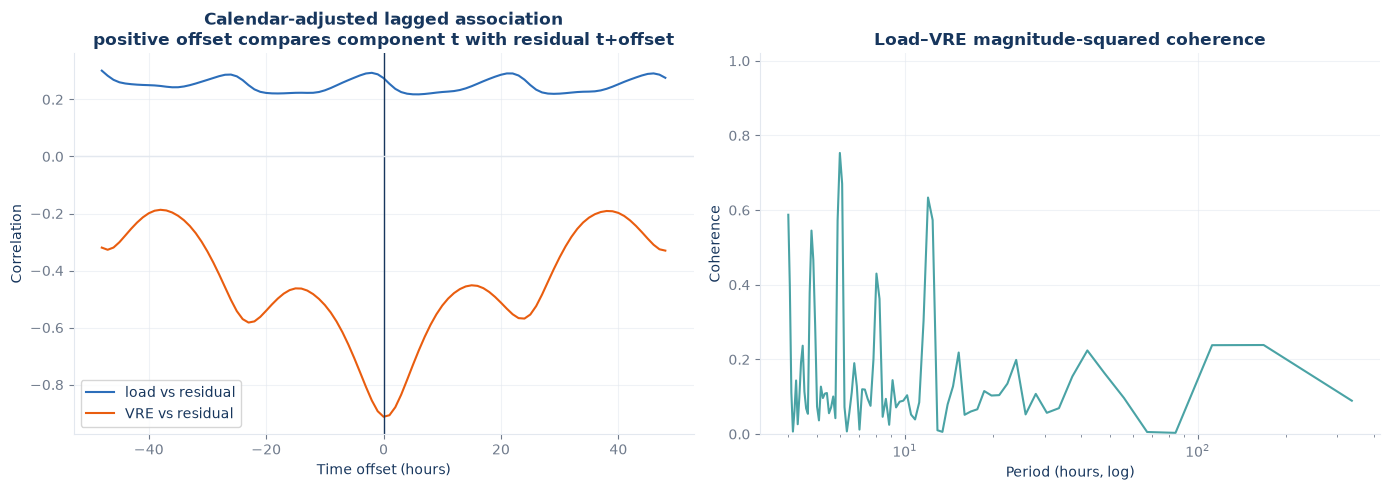

In [55]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
# Question: after removing shared calendar means, which lagged component associations remain?
diagnostic_cutoff_local = pd.Timestamp(fold_specification.iloc[0]["train_end_local"])
diagnostic_cutoff_utc = (diagnostic_cutoff_local + pd.Timedelta(days=1)).tz_localize(BERLIN).tz_convert("UTC")
leadlag_source = observations.loc[
    observations["event_time_utc"] < diagnostic_cutoff_utc,
    ["event_time_utc", "load_mw", "wind_onshore_mw", "wind_offshore_mw", "solar_mw", "residual_load_mw"],
].copy()
leadlag_source["vre_mw"] = (
    leadlag_source["wind_onshore_mw"] + leadlag_source["wind_offshore_mw"] + leadlag_source["solar_mw"]
)
leadlag_local = leadlag_source["event_time_utc"].dt.tz_convert(TZ_NAME)
leadlag_source["calendar_key_dow"] = leadlag_local.dt.dayofweek
leadlag_source["calendar_key_slot"] = (
    (leadlag_local.dt.hour * 60 + leadlag_local.dt.minute) // CADENCE_MINUTES
)
for column in ["load_mw", "vre_mw", "residual_load_mw"]:
    expected = leadlag_source.groupby(
        ["calendar_key_dow", "calendar_key_slot"]
    )[column].transform("mean")
    leadlag_source[f"{column}_adjusted"] = leadlag_source[column] - expected
required_adjusted = ["load_mw_adjusted", "vre_mw_adjusted", "residual_load_mw_adjusted"]
complete = leadlag_source[required_adjusted].notna().all(axis=1)
leadlag_source = leadlag_source.loc[complete].copy()
leadlag_source["run_id"] = (
    leadlag_source["event_time_utc"].diff().ne(cadence_delta).cumsum()
)
run_sizes = leadlag_source.groupby("run_id").size()
if run_sizes.empty:
    raise ValueError("No contiguous block for lead-lag diagnostics.")
longest_run = run_sizes.idxmax()
leadlag_block = leadlag_source.loc[leadlag_source["run_id"].eq(longest_run)].copy()
maximum_diagnostic_points = 180 * 24 * PERIODS_PER_HOUR
leadlag_block = leadlag_block.tail(maximum_diagnostic_points).reset_index(drop=True)
if len(leadlag_block) < 28 * 24 * PERIODS_PER_HOUR:
    raise ValueError("Lead-lag diagnostic needs at least 28 contiguous days.")


# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def lead_lag_correlation(x: np.ndarray, y: np.ndarray, lags: np.ndarray) -> np.ndarray:
    def finite_correlation(left: np.ndarray, right: np.ndarray) -> float:
        mask = np.isfinite(left) & np.isfinite(right)
        if mask.sum() < 3 or np.std(left[mask]) <= 1e-12 or np.std(right[mask]) <= 1e-12:
            return float("nan")
        return float(np.corrcoef(left[mask], right[mask])[0, 1])
    values = []
    for lag in lags:
        if lag > 0:
            values.append(finite_correlation(x[:-lag], y[lag:]))
        elif lag < 0:
            values.append(finite_correlation(x[-lag:], y[:lag]))
        else:
            values.append(finite_correlation(x, y))
    return np.asarray(values, dtype=float)

max_lag_steps = 48 * PERIODS_PER_HOUR
lag_steps = np.arange(-max_lag_steps, max_lag_steps + 1)
lag_hours = lag_steps / PERIODS_PER_HOUR
load_adjusted = leadlag_block["load_mw_adjusted"].to_numpy(float)
vre_adjusted = leadlag_block["vre_mw_adjusted"].to_numpy(float)
residual_adjusted = leadlag_block["residual_load_mw_adjusted"].to_numpy(float)
load_ccf = lead_lag_correlation(load_adjusted, residual_adjusted, lag_steps)
vre_ccf = lead_lag_correlation(vre_adjusted, residual_adjusted, lag_steps)
nperseg = min(len(leadlag_block), 14 * 24 * PERIODS_PER_HOUR)
frequency, load_vre_coherence = coherence(
    load_adjusted, vre_adjusted, fs=PERIODS_PER_HOUR,
    nperseg=nperseg, noverlap=nperseg // 2,
)
coherence_period = np.divide(
    1.0, frequency, out=np.full_like(frequency, np.nan), where=frequency > 0
)
coherence_mask = (
    np.isfinite(coherence_period) & (coherence_period >= 4) & (coherence_period <= 336)
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
axes[0].plot(lag_hours, load_ccf, label="load vs residual", color=COLORS["blue"])
axes[0].plot(lag_hours, vre_ccf, label="VRE vs residual", color=COLORS["orange"])
axes[0].axvline(0, color=COLORS["ink"], linewidth=1)
axes[0].axhline(0, color=COLORS["grid"], linewidth=1)
axes[0].set(title="Calendar-adjusted lagged association\npositive offset compares component t with residual t+offset",
            xlabel="Time offset (hours)", ylabel="Correlation")
axes[0].legend()
axes[1].plot(coherence_period[coherence_mask], load_vre_coherence[coherence_mask],
             color=COLORS["teal"])
axes[1].set_xscale("log")
axes[1].set_ylim(0, 1.02)
axes[1].set(title="Load–VRE magnitude-squared coherence", xlabel="Period (hours, log)",
            ylabel="Coherence")
leadlag_diagnostic_receipt = {
    "role": "diagnostic_only", "fit_end_utc": leadlag_block["event_time_utc"].max(),
    "rows": len(leadlag_block), "nperseg": nperseg,
    "note": "component-to-residual association is partly mechanical; not causal evidence",
}
finish_figure(fig, "calendar_adjusted_leadlag", "Which lagged associations survive calendar adjustment without implying causality?")

### Training-only ACF/PACF without statsmodels

**Question:** after removing the shared weekday-slot mean, which memory lags remain?

ACF is computed by zero-padded FFT convolution. PACF is recovered by the
Durbin–Levinson recursion. The plot is a diagnostic on the longest contiguous
pre-validation block; it does not select lags from future folds.


The plotted $\pm1.96/\sqrt{n}$ bands are a white-noise reference, not multiplicity-adjusted
significance thresholds and not valid causal evidence. Shared calendar means are removed
using the pre-first-fold training reference only. PACF values are not additional model features
unless separately admitted through the feature registry.


### Estimate training-only ACF and PACF

Inspect the stated units, time range and support before interpreting the resulting table or figure.

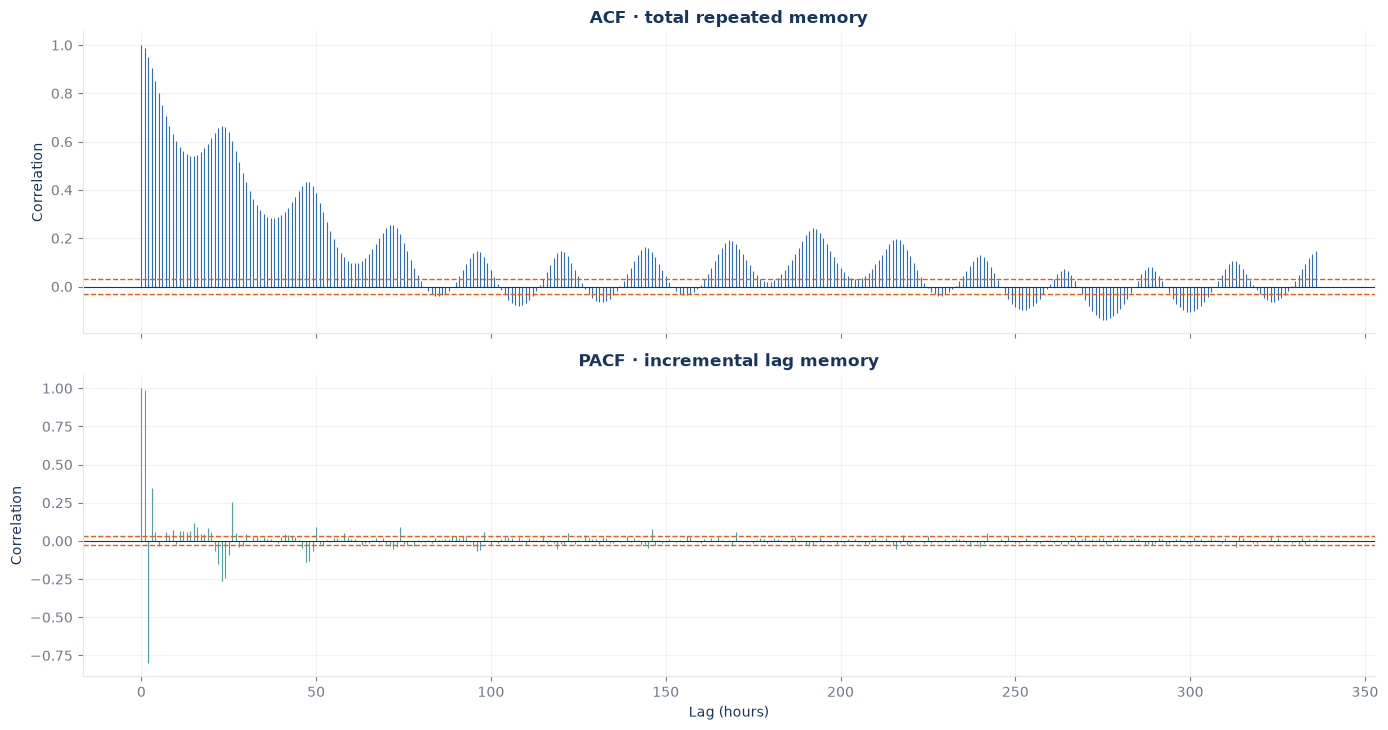

,lag_hours,acf,pacf,outside_approx_95pct
0,1,0.986538,0.986538,True
1,2,0.951909,-0.798242,True
2,4,0.852240,0.056512,True
3,8,0.664637,0.036863,True
4,12,0.559746,0.068120,True
5,24,0.660228,-0.244563,True
6,48,0.431883,-0.131953,True
7,72,0.256053,-0.053845,True
8,168,0.191790,0.006733,True
9,336,0.145869,0.015261,True


In [56]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
acf_max_hours = 14 * 24
acf_max_lag = min(
    acf_max_hours * PERIODS_PER_HOUR,
    len(residual_adjusted) - 1,
)
residual_acf = autocorrelation_fft(residual_adjusted, acf_max_lag)
residual_pacf = pacf_durbin_levinson(residual_acf, acf_max_lag)
acf_lag_hours = np.arange(acf_max_lag + 1) / PERIODS_PER_HOUR
acf_confidence = 1.96 / np.sqrt(len(residual_adjusted))
diagnostic_lags_hours = [1, 2, 4, 8, 12, 24, 48, 72, 168, 336]
acf_pacf_table = pd.DataFrame([
    {
        "lag_hours": lag,
        "acf": residual_acf[min(acf_max_lag, lag * PERIODS_PER_HOUR)],
        "pacf": residual_pacf[min(acf_max_lag, lag * PERIODS_PER_HOUR)],
        "outside_approx_95pct": bool(
            abs(residual_acf[min(acf_max_lag, lag * PERIODS_PER_HOUR)])
            > acf_confidence
        ),
    }
    for lag in diagnostic_lags_hours
    if lag * PERIODS_PER_HOUR <= acf_max_lag
])
fig, axes = plt.subplots(2, 1, figsize=(14, 7.4), sharex=True)
axes[0].vlines(acf_lag_hours, 0, residual_acf, color=COLORS["blue"], linewidth=.8)
axes[1].vlines(acf_lag_hours, 0, residual_pacf, color=COLORS["teal"], linewidth=.8)
for axis, title in zip(axes, ["ACF · total repeated memory", "PACF · incremental lag memory"]):
    axis.axhline(acf_confidence, color=COLORS["orange"], linestyle="--", linewidth=1)
    axis.axhline(-acf_confidence, color=COLORS["orange"], linestyle="--", linewidth=1)
    axis.axhline(0, color=COLORS["ink"], linewidth=.8)
    axis.set(title=title, ylabel="Correlation")
axes[1].set(xlabel="Lag (hours)")
finish_figure(
    fig, "training_only_acf_pacf",
    "Which residual-load memory lags survive calendar adjustment?"
)
display(acf_pacf_table)

## 5. Forecasting validation of upstream temporal EDA

The flight work showed that time representation is an empirical question. The upstream GridStress EDA
showed descriptive periodic structure; this section now asks whether a representation transfers out of
time. Five representations compete under the same Ridge model and forward folds: raw scalar, cyclic,
raw + cyclic, predeclared Fourier, and periodic spline. The Fourier candidate adds 12-hour, 8-hour and
half-week terms declared before scoring. The spline is fit on each training fold only. This is not a
repeat of the observed mean-profile reconstruction or ACF/PACF analysis.


### Compare time representations in forward folds · 1/2

Fit each representation only on its own training period. The five representations are compared on identical outer validation targets.

In [57]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def fold_frames(frame: pd.DataFrame, fold: pd.Series) -> tuple[pd.DataFrame, pd.DataFrame]:
    dates = pd.to_datetime(frame["target_date_local"])
    train = frame.loc[dates <= fold["train_end_local"]].copy()
    valid = frame.loc[
        (dates >= fold["valid_start_local"]) & (dates <= fold["valid_end_local"])
    ].copy()
    if train.empty or valid.empty:
        raise ValueError(f"{fold['fold_id']} is outside available data coverage")
    assert train["target_date_local"].max() < valid["target_date_local"].min()
    return train, valid

active_fold_specification = (
    fold_specification.tail(2).reset_index(drop=True) if SMOKE_TEST else fold_specification.copy()
)


# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def temporal_design(
    train: pd.DataFrame, valid: pd.DataFrame, representation: str
) -> tuple[np.ndarray, np.ndarray]:
    raw = ["calendar_hour_raw", "calendar_dow_raw", "calendar_doy_raw"]
    cyclic = [
        "calendar_slot_sin", "calendar_slot_cos", "calendar_dow_sin", "calendar_dow_cos",
        "calendar_doy_sin", "calendar_doy_cos",
    ]
    if representation == "calendar_raw":
        return train[raw].to_numpy(float), valid[raw].to_numpy(float)
    if representation == "calendar_cyclic":
        return train[cyclic].to_numpy(float), valid[cyclic].to_numpy(float)
    if representation == "calendar_raw_plus_cyclic":
        return train[raw + cyclic].to_numpy(float), valid[raw + cyclic].to_numpy(float)
    if representation == "calendar_fourier":
        columns = cyclic + ["calendar_hour_h2_sin", "calendar_hour_h2_cos", "calendar_hour_h3_sin", "calendar_hour_h3_cos", "calendar_week_h2_sin", "calendar_week_h2_cos"]
        return train[columns].to_numpy(float), valid[columns].to_numpy(float)
    if representation == "calendar_periodic_spline":
        transformer = SplineTransformer(
            knots=np.linspace(0.0, 24.0, 9).reshape(-1, 1),
            degree=3, extrapolation="periodic", include_bias=False
        )
        train_hour = train[["calendar_hour_raw"]].to_numpy(float)
        valid_hour = valid[["calendar_hour_raw"]].to_numpy(float)
        train_spline = transformer.fit_transform(train_hour)
        valid_spline = transformer.transform(valid_hour)
        return (
            np.column_stack([train_spline, train[["calendar_dow_sin", "calendar_dow_cos", "calendar_doy_sin", "calendar_doy_cos"]].to_numpy(float)]),
            np.column_stack([valid_spline, valid[["calendar_dow_sin", "calendar_dow_cos", "calendar_doy_sin", "calendar_doy_cos"]].to_numpy(float)]),
        )
    raise ValueError(representation)

### Compare time representations in forward folds · 2/2

Fit each representation only on its own training period. The five representations are compared on identical outer validation targets.

In [58]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
temporal_rows = []
representations = [
    "calendar_raw", "calendar_cyclic", "calendar_raw_plus_cyclic",
    "calendar_fourier", "calendar_periodic_spline",
]
for _, fold in active_fold_specification.iterrows():
    train, valid = fold_frames(feature_matrix, fold)
    if SMOKE_TEST and len(train) > 6_000:
        train = train.iloc[:: max(1, len(train) // 6_000)]
    for representation in representations:
        X_train, X_valid = temporal_design(train, valid, representation)
        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("ridge", Ridge(alpha=10.0)),
        ])
        model.fit(X_train, train["residual_load_mw"].to_numpy(float))
        prediction = model.predict(X_valid)
        temporal_rows.append({
            "fold_id": fold["fold_id"], "representation": representation,
            "rmse_mw": float(mean_squared_error(valid["residual_load_mw"], prediction) ** 0.5),
            "mae_mw": float(mean_absolute_error(valid["residual_load_mw"], prediction)),
        })
temporal_representation_results = pd.DataFrame(temporal_rows)
raw_rmse = temporal_representation_results.loc[
    temporal_representation_results["representation"].eq("calendar_raw"),
    ["fold_id", "rmse_mw"]
].rename(columns={"rmse_mw": "raw_rmse_mw"})
temporal_representation_results = temporal_representation_results.merge(raw_rmse, on="fold_id")
temporal_representation_results["delta_rmse_vs_raw_mw"] = (
    temporal_representation_results["rmse_mw"] - temporal_representation_results["raw_rmse_mw"]
)
display(temporal_representation_results)

,fold_id,representation,rmse_mw,mae_mw,raw_rmse_mw,delta_rmse_vs_raw_mw
0,F1,calendar_raw,11000.069799,8812.321116,11000.069799,0.000000
1,F1,calendar_cyclic,11038.848847,8826.279939,11000.069799,38.779047
2,F1,calendar_raw_plus_cyclic,10724.131287,8600.990796,11000.069799,-275.938512
3,F1,calendar_fourier,10017.577492,7909.696495,11000.069799,-982.492308
4,F1,calendar_periodic_spline,10235.017334,8048.290131,11000.069799,-765.052465
...,...,...,...,...,...,...
30,F7,calendar_raw,13359.345107,10512.602769,13359.345107,0.000000
31,F7,calendar_cyclic,13349.845733,10561.612973,13359.345107,-9.499374
32,F7,calendar_raw_plus_cyclic,13035.042515,10328.733178,13359.345107,-324.302592
33,F7,calendar_fourier,12359.441218,9779.112593,13359.345107,-999.903889


### Plot time-representation results

Inspect the stated units, time range and support before interpreting the resulting table or figure.

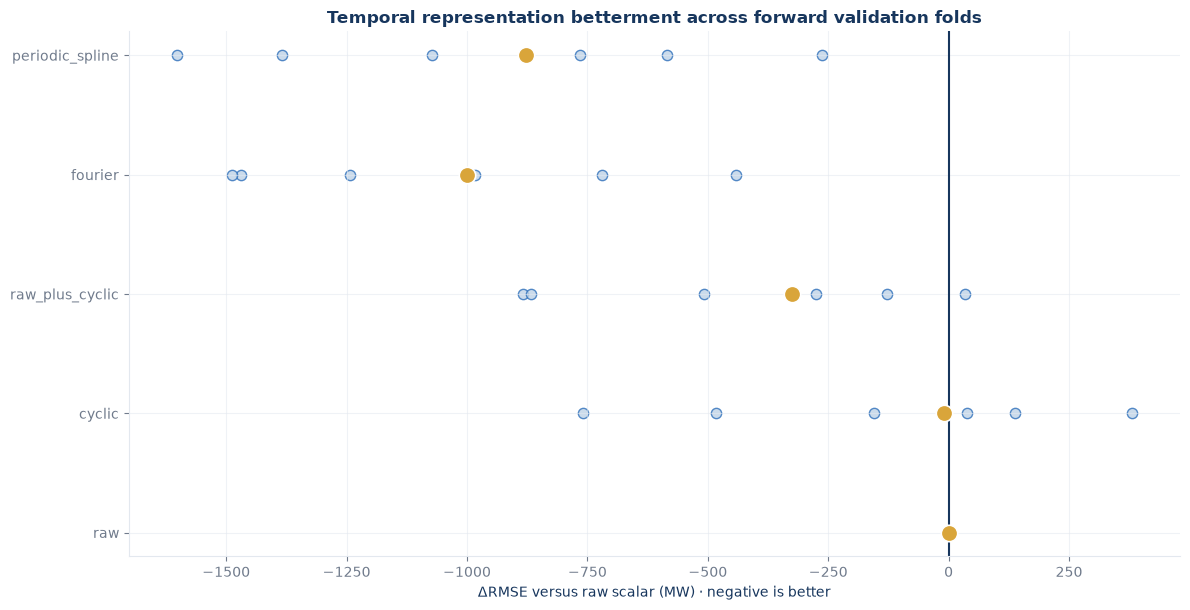

In [59]:
# -----------------------------------------------------------------
# Cross-signal and lead-lag diagnostics
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6.2))
labels = representations
for y, representation in enumerate(labels):
    subset = temporal_representation_results.loc[
        temporal_representation_results["representation"].eq(representation)
    ]
    ax.scatter(subset["delta_rmse_vs_raw_mw"], np.full(len(subset), y),
               s=55, facecolor="#BFD3E6", edgecolor=COLORS["blue"], alpha=.8)
    ax.scatter([subset["delta_rmse_vs_raw_mw"].median()], [y], s=140,
               color=COLORS["gold"], edgecolor="white", linewidth=1.2, zorder=3)
ax.axvline(0, color=COLORS["ink"], linewidth=1.5)
ax.set(yticks=range(len(labels)), yticklabels=[label.replace("calendar_", "") for label in labels],
       xlabel="ΔRMSE versus raw scalar (MW) · negative is better",
       title="Temporal representation betterment across forward validation folds")
finish_figure(fig, "temporal_representation_lab", "Does a richer clock representation transfer across folds?")

## 6. Dynamic seven-fold validation

All transformations, support filters, redundancy filters, imputers, scalers, and estimators are fit
inside the outer training fold. Feature choice is outcome-independent: a pre-registered family ladder
is filtered only for training support, variance, and near-duplicate correlation. The fold-local
correlation filter is an engineering redundancy guard—not a repetition of the upstream full-record
correlation EDA and never an outcome-based selector.

The eight-day gap excludes labels from training. Legally known observations that arrive during that
gap may still populate a validation row's history because availability is evaluated against that row's
forecast origin—not against an artificial freeze at `train_end`. Spectral windows are materialized per
origin before modeling, while all trainable preprocessing remains fold-local.


### Define fold-local fitting and metrics · 1/3

Inspect the stated units, time range and support before interpreting the resulting table or figure.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [60]:
# -----------------------------------------------------------------
# Feature construction, lineage, and scientific evidence
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def accumulated_features(through_family: str) -> list[str]:
    selected: list[str] = []
    for family, names in FEATURE_FAMILIES.items():
        selected.extend(names)
        if family == through_family:
            break
    return selected

def fold_local_feature_names(
    train: pd.DataFrame, candidates: list[str], min_support: float = 0.95,
    max_abs_correlation: float = 0.995,
) -> tuple[list[str], pd.DataFrame]:
    diagnostics = []
    kept: list[str] = []
    if len(candidates) != len(set(candidates)):
        raise ValueError("Candidate feature names must be unique.")
    numeric = train[candidates].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    if SMOKE_TEST and len(numeric) > 6_000:
        numeric = numeric.iloc[:: max(1, len(numeric) // 6_000)]
    correlations_all = numeric.corr().abs()
    for name in candidates:
        support_value = float(numeric[name].notna().mean())
        variance = float(numeric[name].var(skipna=True))
        decision = "KEEP"
        reason = "eligible"
        if support_value < min_support:
            decision, reason = "DROP", "support"
        elif not np.isfinite(variance) or variance <= 1e-12:
            decision, reason = "DROP", "invariant"
        elif kept:
            correlations = correlations_all.loc[kept, name]
            if not correlations.empty and correlations.max() >= max_abs_correlation:
                decision, reason = "DROP", f"redundant_with={correlations.idxmax()}"
        if decision == "KEEP":
            kept.append(name)
        diagnostics.append({
            "feature": name, "support": support_value, "variance": variance,
            "decision": decision, "reason": reason,
        })
    return kept, pd.DataFrame(diagnostics)

### Define fold-local fitting and metrics · 2/3

Inspect the stated units, time range and support before interpreting the resulting table or figure.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [61]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def fit_ridge_predict(
    train: pd.DataFrame, valid: pd.DataFrame, features: list[str],
    target: pd.Series | np.ndarray | None = None,
) -> np.ndarray:
    model_train = train
    target_values = np.asarray(
        train["residual_load_mw"] if target is None else target, dtype=float
    )
    if SMOKE_TEST and len(model_train) > 6_000:
        stride = max(1, len(model_train) // 6_000)
        positions = np.arange(0, len(model_train), stride)
        model_train = model_train.iloc[positions]
        target_values = target_values[positions]
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
        ("ridge", Ridge(alpha=10.0)),
    ])
    model.fit(model_train[features], target_values)
    return model.predict(valid[features])

### Define fold-local fitting and metrics · 3/3

Inspect the stated units, time range and support before interpreting the resulting table or figure.

In [62]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def safe_correlation(x: object, y: object) -> float:
    x_array = np.asarray(x, dtype=float).reshape(-1)
    y_array = np.asarray(y, dtype=float).reshape(-1)
    mask = np.isfinite(x_array) & np.isfinite(y_array)
    if mask.sum() < 3 or np.std(x_array[mask]) <= 1e-12 or np.std(y_array[mask]) <= 1e-12:
        return float("nan")
    return float(np.corrcoef(x_array[mask], y_array[mask])[0, 1])

def regression_metrics(y_true: object, y_pred: object) -> dict:
    actual = np.asarray(y_true, dtype=float).reshape(-1)
    predicted = np.asarray(y_pred, dtype=float).reshape(-1)
    if actual.size == 0 or actual.shape != predicted.shape:
        raise ValueError("Metric inputs must be nonempty and aligned.")
    if not np.isfinite(actual).all() or not np.isfinite(predicted).all():
        raise ValueError("Scored metric inputs must be finite; do not silently drop failed predictions.")
    error = predicted - actual
    absolute = np.abs(error)
    return {
        "mae_mw": float(np.mean(absolute)),
        "rmse_mw": float(np.sqrt(np.mean(error ** 2))),
        "bias_mw": float(np.mean(error)),
        "p95_absolute_error_mw": float(np.quantile(absolute, 0.95)),
    }


# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def predict_climatology(train: pd.DataFrame, valid: pd.DataFrame) -> np.ndarray:
    key_columns = ["calendar_dow_raw", "calendar_slot_index"]
    lookup = train.groupby(key_columns)["residual_load_mw"].mean()
    keys = pd.MultiIndex.from_frame(valid[key_columns])
    prediction = lookup.reindex(keys).to_numpy(float)
    slot_lookup = train.groupby("calendar_slot_index")["residual_load_mw"].mean()
    fallback = valid["calendar_slot_index"].map(slot_lookup).to_numpy(float)
    global_mean = float(train["residual_load_mw"].mean())
    prediction = np.where(np.isfinite(prediction), prediction, fallback)
    return np.where(np.isfinite(prediction), prediction, global_mean)

print("Active execution folds:", active_fold_specification["fold_id"].tolist())

Active execution folds: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7']


### Inspect the fold-local design matrix · 1/2

The empirical Gram matrix checks overlap in the observed design. Analytical sine/cosine orthogonality does not guarantee empirical independence after filtering.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [63]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Validation and scientific safeguards
# -----------------------------------------------------------------
# Question: do deterministic harmonics, dynamic spectrum and event gates remain distinguishable?
def standardized_design_audit(frame: pd.DataFrame, columns: list[str]) -> tuple[pd.DataFrame, dict]:
    numeric = frame[columns].apply(pd.to_numeric, errors="coerce")
    support = numeric.notna().mean()
    numeric = numeric.loc[:, support >= .95]
    variance = numeric.var(skipna=True)
    numeric = numeric.loc[:, np.isfinite(variance) & (variance > 1e-12)]
    if numeric.empty:
        raise ValueError("No eligible features for the design audit.")
    filled = numeric.fillna(numeric.median())
    if len(filled) > 30_000:
        filled = filled.iloc[::max(1, len(filled) // 30_000)]
    z = (filled - filled.mean()) / filled.std(ddof=0)
    matrix = z.to_numpy(float)
    gram = pd.DataFrame(matrix.T @ matrix / len(matrix), index=z.columns, columns=z.columns)
    singular = np.linalg.svd(matrix, full_matrices=False, compute_uv=False)
    positive = singular[singular > max(singular[0] * 1e-12, 1e-12)]
    audit = {
        "rows": len(matrix), "columns": matrix.shape[1], "rank": int(np.linalg.matrix_rank(matrix)),
        "condition_number": (float(positive[0] / positive[-1])
                             if len(positive) == matrix.shape[1] else float("inf")),
        "max_off_diagonal_abs": float(
            np.abs(gram.to_numpy() - np.eye(len(gram))).max()
        ),
    }
    return gram, audit

### Inspect the fold-local design matrix · 2/2

The empirical Gram matrix checks overlap in the observed design. Analytical sine/cosine orthogonality does not guarantee empirical independence after filtering.

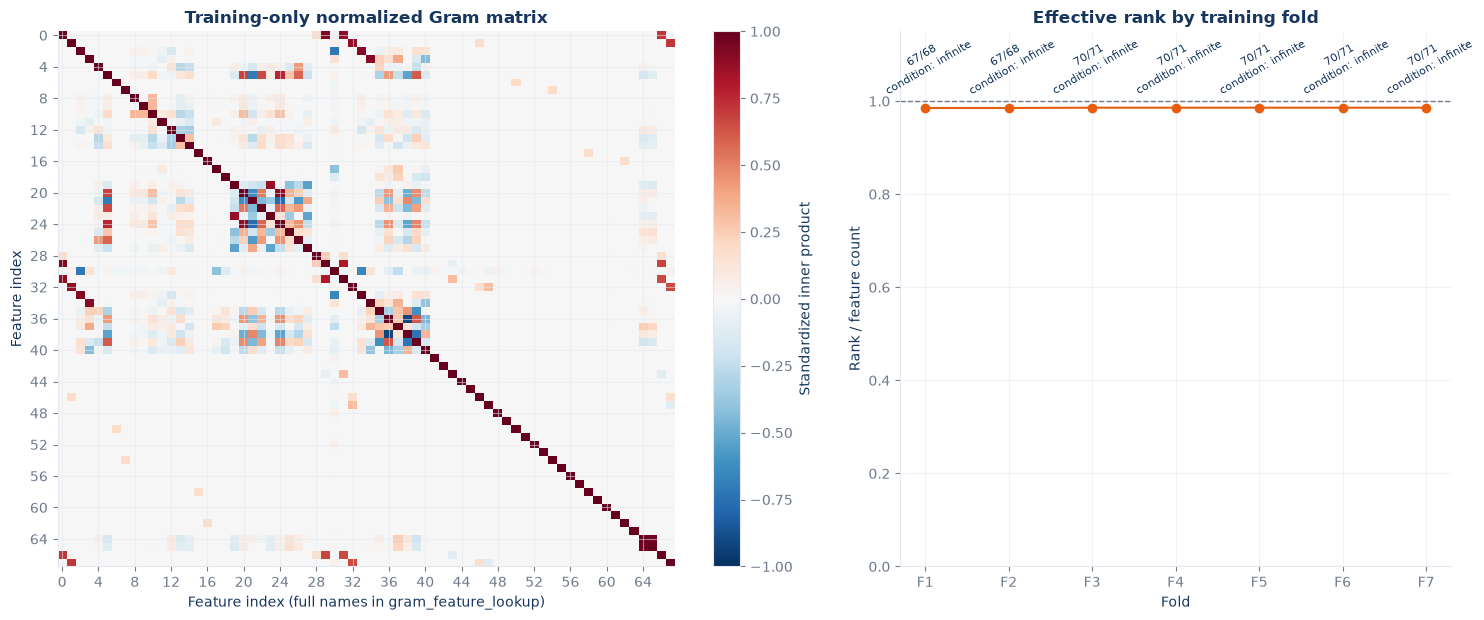

,fold_id,rows,columns,rank,condition_number,max_off_diagonal_abs
0,F1,21863,68,67,inf,0.968490
1,F2,26280,68,67,inf,0.966167
2,F3,30623,71,70,inf,0.977323
3,F4,35040,71,70,inf,0.978799
4,F5,39383,71,70,inf,0.978768
5,F6,43800,71,70,inf,0.978256
6,F7,48167,71,70,inf,0.977542


,feature_index,feature_name
0,0,calendar_slot_sin
1,1,calendar_slot_cos
2,2,calendar_dow_sin
3,3,calendar_dow_cos
4,4,calendar_doy_sin
...,...,...
63,63,interaction_calendar_hour_h3_cos_x_calendar_do...
64,64,intervention_covid_disruption_step
65,65,intervention_days_since_covid_disruption_log
66,66,interaction_covid_x_daily_sin


In [64]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------
orthogonality_rows = []
signal_audit_candidates = [
    *FEATURE_FAMILIES["F1_TEMPORAL_GEOMETRY"],
    *FEATURE_FAMILIES["S0_SCHEDULED_CALENDAR_EVENTS"],
    *FEATURE_FAMILIES["S1_DECLARED_SIGNAL_BASIS"],
    *FEATURE_FAMILIES["S2_ORIGIN_SAFE_SPECTRAL_STATE"],
    *FEATURE_FAMILIES["F10_SELECTED_INTERACTIONS"],
    *FEATURE_FAMILIES["F9_ORIGIN_CONTROL_STATE"],
    *FEATURE_FAMILIES["S4_CONTEXT_MODULATED_HARMONICS"],
    *FEATURE_FAMILIES["S3_INTERVENTION_ADAPTATION"],
]
first_gram = None
first_audit = None
for _, fold in active_fold_specification.iterrows():
    train, _ = fold_frames(feature_matrix, fold)
    kept, _ = fold_local_feature_names(train, signal_audit_candidates)
    gram, audit = standardized_design_audit(train, kept)
    orthogonality_rows.append({"fold_id": fold["fold_id"], **audit})
    if first_gram is None:
        first_gram, first_audit = gram, audit
orthogonality_by_fold = pd.DataFrame(orthogonality_rows)
gram_feature_lookup = pd.DataFrame({
    "feature_index": np.arange(len(first_gram)), "feature_name": first_gram.columns,
})
fig, axes = plt.subplots(1, 2, figsize=(15, 6.3), gridspec_kw={"width_ratios": [1.4, 1]})
image = axes[0].imshow(first_gram.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
tick_positions = np.arange(0, len(first_gram), max(1, math.ceil(len(first_gram) / 18)))
axes[0].set(xticks=tick_positions, yticks=tick_positions,
            xlabel="Feature index (full names in gram_feature_lookup)", ylabel="Feature index",
            title="Training-only normalized Gram matrix")
fig.colorbar(image, ax=axes[0], label="Standardized inner product")
rank_fraction = orthogonality_by_fold["rank"] / orthogonality_by_fold["columns"]
axes[1].plot(orthogonality_by_fold["fold_id"], rank_fraction, marker="o", color=COLORS["orange"])
axes[1].axhline(1.0, linestyle="--", color=COLORS["muted"], linewidth=1)
axes[1].set(title="Effective rank by training fold", xlabel="Fold", ylabel="Rank / feature count", ylim=(0, 1.15))
for position, row in enumerate(orthogonality_by_fold.itertuples(index=False)):
    condition_label = "infinite" if not np.isfinite(row.condition_number) else f"{row.condition_number:.1e}"
    axes[1].annotate(f"{row.rank}/{row.columns}\ncondition: {condition_label}",
                     (position, row.rank / row.columns), xytext=(0, 10),
                     textcoords="offset points", ha="center", fontsize=8, rotation=30)
finish_figure(fig, "signal_orthogonality_audit", "Are signal features still distinguishable inside each training fold?")
display(orthogonality_by_fold)
display(gram_feature_lookup)

## 7. Honest baseline ladder

- **B0** weekday × local-slot climatology, fit on training only.
- **B1** Berlin-local D-7 persistence (then D-14, then B0 fallback); event-time eligible, revision-unverified.
- **B2** official forecast only if historical issuance and vintage pass the gate.
- **B3** research Ridge on fold-local event-time candidates; historical revisions remain unverified.
- **B4** shallow histogram gradient boosting on exactly the same research candidate set.
- **B5** official forecast plus residual correction only after B2 is qualified.

B0 is the production-safe reference under the present data contract; B1 is the primary research skill
denominator. Legacy column suffixes such as `168h` mean Berlin-local D-7 profile matching and may span
167/168/169 elapsed hours across DST. All model comparisons use identical OOF keys; coverage differences
are reported rather than hidden.


**Calibrated alert models stay frozen.** Feature selection, imputation, scaling and risk-model
fitting for an alert use only the inner chronological fit period. The later calibration tail
chooses a threshold; the same fitted estimator and threshold then score the outer fold. The
code does not refit that estimator after calibration. Regression B3 remains a separately
full-outer-training model, so the C1 risk proxy is not misrepresented as its calibrated probability.
The 20% alert-day rate is a nominal calibration target, not a guaranteed quota: ties can produce
higher rates, and the observed calibration/validation rates are reported explicitly.


### Fit the baseline ladder and frozen alert models · 1/3

Outer validation dates are untouched by fitting. Alerts use a separate inner chronological calibration tail, and the calibrated estimator is not refitted afterward.

In [65]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
prediction_rows: list[pd.DataFrame] = []
classification_rows: list[pd.DataFrame] = []
ladder_rows: list[dict] = []
selected_features_by_fold: dict[str, list[str]] = {}
selection_diagnostics_by_fold: dict[str, list[dict]] = {}
ladder_features_by_fold_family: dict[str, list[str]] = {}
classification_alert_thresholds: dict[tuple[str, str], float] = {}
classification_threshold_audit_rows: list[dict] = []


# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def chronological_threshold_calibration_split(
    train: pd.DataFrame, calibration_share: float = 0.20, gap_days: int = 8
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Timestamp]:
    dates = pd.DatetimeIndex(pd.to_datetime(train["target_date_local"].unique())).sort_values()
    if len(dates) < 180:
        raise ValueError("At least 180 training days are required for nested alert calibration.")
    start_position = min(len(dates) - 60, max(120, int(len(dates) * (1 - calibration_share))))
    calibration_start = pd.Timestamp(dates[start_position])
    fit_end_exclusive = calibration_start - pd.Timedelta(days=gap_days)
    fit = train.loc[pd.to_datetime(train["target_date_local"]) < fit_end_exclusive].copy()
    calibration = train.loc[pd.to_datetime(train["target_date_local"]) >= calibration_start].copy()
    if fit["target_date_local"].nunique() < 120 or calibration["target_date_local"].nunique() < 30:
        raise ValueError("Nested chronological alert-calibration split has insufficient support.")
    return fit, calibration, calibration_start


# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def training_daily_alert_threshold(
    dates: pd.Series, risk_scores: np.ndarray, alert_day_budget: float = 0.20
) -> float:
    daily_max = pd.DataFrame({
        "target_date_local": pd.to_datetime(dates).to_numpy(),
        "risk_score": np.asarray(risk_scores, dtype=float),
    }).groupby("target_date_local")["risk_score"].max()
    return float(daily_max.quantile(1.0 - alert_day_budget))

def realized_daily_alert_rate(
    dates: pd.Series, risk_scores: np.ndarray, threshold: float
) -> float:
    daily_max = pd.DataFrame({
        "target_date_local": pd.to_datetime(dates).to_numpy(),
        "risk_score": np.asarray(risk_scores, dtype=float),
    }).groupby("target_date_local")["risk_score"].max()
    return float(daily_max.ge(threshold).mean())


# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def append_predictions(
    fold_id: str, model_id: str, valid: pd.DataFrame, prediction: np.ndarray
) -> None:
    prediction_rows.append(pd.DataFrame({
        "fold_id": fold_id,
        "model_id": model_id,
        "forecast_origin_utc": valid["forecast_origin_utc"].to_numpy(),
        "target_time_utc": valid["target_time_utc"].to_numpy(),
        "target_date_local": valid["target_date_local"].to_numpy(),
        "horizon_hours": valid["horizon_hours"].to_numpy(),
        "calendar_hour_raw": valid["calendar_hour_raw"].to_numpy(),
        "calendar_month": valid["calendar_month"].to_numpy(),
        "y_true_mw": valid["residual_load_mw"].to_numpy(float),
        "y_pred_mw": np.asarray(prediction, dtype=float),
        "stress_any": valid["stress_any"].to_numpy(bool),
        "stress_high": valid["stress_high"].to_numpy(bool),
        "stress_low": valid["stress_low"].to_numpy(bool),
        "stress_negative": valid["stress_negative"].to_numpy(bool),
        "stress_ramp_up": valid["stress_ramp_up"].to_numpy(bool),
        "stress_ramp_down": valid["stress_ramp_down"].to_numpy(bool),
    }))

### Fit the baseline ladder and frozen alert models · 2/3

Outer validation dates are untouched by fitting. Alerts use a separate inner chronological calibration tail, and the calibrated estimator is not refitted afterward.

In [66]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
for _, fold in active_fold_specification.iterrows():
    train, valid = fold_frames(feature_matrix, fold)
    fold_id = str(fold["fold_id"])
    b0 = predict_climatology(train, valid)
    b1 = valid["persistence_residual_lag_168h_mw"].to_numpy(float)
    b1 = np.where(np.isfinite(b1), b1, valid["persistence_residual_lag_336h_mw"].to_numpy(float))
    b1 = np.where(np.isfinite(b1), b1, b0)
    append_predictions(fold_id, "B0_CLIMATOLOGY", valid, b0)
    append_predictions(fold_id, "B1_SAFE_PERSISTENCE", valid, b1)

    core_candidates = accumulated_features("F6_D2_SHAPE")
    core_features, diagnostics = fold_local_feature_names(train, core_candidates)
    selected_features_by_fold[fold_id] = core_features
    selection_diagnostics_by_fold[fold_id] = diagnostics.to_dict("records")
    threshold_fit, threshold_calibration, threshold_calibration_start = (
        chronological_threshold_calibration_split(train)
    )
    calibration_features, _ = fold_local_feature_names(threshold_fit, core_candidates)
    ridge_prediction = fit_ridge_predict(train, valid, core_features)
    append_predictions(fold_id, "B3_RIDGE", valid, ridge_prediction)

    if official_forecast_status == "QUALIFIED_OFFICIAL_FORECAST":
        b2 = valid["official_forecast_mw"].to_numpy(float)
        append_predictions(fold_id, "B2_OFFICIAL_FORECAST", valid, b2)
        correction_target = (
            train["residual_load_mw"] - train["official_forecast_mw"]
        ).to_numpy(float)
        correction = fit_ridge_predict(
            train, valid, core_features, target=correction_target
        )
        append_predictions(fold_id, "B5_OFFICIAL_PLUS_RESIDUAL_CORRECTION", valid, b2 + correction)

    model_train = train
    if SMOKE_TEST and len(model_train) > 6_000:
        model_train = model_train.iloc[:: max(1, len(model_train) // 6_000)]
    tree_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("hgb", HistGradientBoostingRegressor(
            max_depth=4, learning_rate=0.06, max_iter=70 if SMOKE_TEST else 140,
            l2_regularization=1.0, early_stopping=False, random_state=RANDOM_SEED,
        )),
    ])
    tree_model.fit(model_train[core_features], model_train["residual_load_mw"])
    append_predictions(fold_id, "B4_SHALLOW_HGB", valid, tree_model.predict(valid[core_features]))

    all_family_features, all_family_diagnostics = fold_local_feature_names(train, candidate_names)
    all_family_feature_set = set(all_family_features)
    previous_prediction = None
    for family in FEATURE_FAMILIES:
        candidates = accumulated_features(family)
        family_features = [name for name in candidates if name in all_family_feature_set]
        ladder_features_by_fold_family[f"{fold_id}|{family}"] = family_features.copy()
        family_prediction = fit_ridge_predict(train, valid, family_features)
        metrics = regression_metrics(valid["residual_load_mw"], family_prediction)
        tail_mask = valid[["stress_high", "stress_low", "stress_negative"]].any(axis=1).to_numpy()
        tail_mae = (
            float(mean_absolute_error(valid.loc[tail_mask, "residual_load_mw"], family_prediction[tail_mask]))
            if tail_mask.any() else float("nan")
        )
        ladder_rows.append({
            "fold_id": fold_id, "family": family, "feature_count": len(family_features),
            **metrics, "tail_mae_mw": tail_mae,
        })
        previous_prediction = family_prediction

    prevalence = float(train["stress_any"].mean())
    inner_prevalence = float(threshold_fit["stress_any"].mean())
    c0_calibration_risk = np.full(len(threshold_calibration), inner_prevalence)
    c0_threshold = training_daily_alert_threshold(
        threshold_calibration["target_date_local"], c0_calibration_risk
    )
    classification_alert_thresholds[(fold_id, "C0_PREVALENCE")] = c0_threshold
    classification_threshold_audit_rows.append({
        "fold_id": fold_id, "model_id": "C0_PREVALENCE",
        "calibration_start_local": threshold_calibration_start,
        "calibration_days": threshold_calibration["target_date_local"].nunique(),
        "threshold": c0_threshold, "target_alert_day_fraction": 0.20,
        "calibration_alert_day_fraction": realized_daily_alert_rate(
            threshold_calibration["target_date_local"], c0_calibration_risk, c0_threshold
        ),
    })
    classification_rows.append(pd.DataFrame({
        "fold_id": fold_id, "model_id": "C0_PREVALENCE",
        "target_time_utc": valid["target_time_utc"].to_numpy(),
        "target_date_local": valid["target_date_local"].to_numpy(),
        "y_true": valid["stress_any"].astype(int).to_numpy(),
        "risk_score": np.full(len(valid), inner_prevalence),
        "alert_threshold": c0_threshold,
    }))
    scale = max(500.0, float(train["residual_load_mw"].std()) * 0.15)
    high_risk = 1 / (1 + np.exp(-(ridge_prediction - STRESS_THRESHOLDS["residual_p95_mw"]) / scale))
    low_risk = 1 / (1 + np.exp(-((STRESS_THRESHOLDS["residual_p05_mw"] - ridge_prediction) / scale)))
    calibration_scale = max(
        500.0, float(threshold_fit["residual_load_mw"].std()) * 0.15
    )

# -----------------------------------------------------------------
# Model evidence
# -----------------------------------------------------------------
    # One model supplies BOTH calibration-tail and outer-validation scores.
    # Refitting after threshold selection would change the score distribution.
    calibration_ridge_train = threshold_fit
    if SMOKE_TEST and len(calibration_ridge_train) > 6_000:
        calibration_ridge_train = calibration_ridge_train.iloc[::max(1, len(calibration_ridge_train)//6_000)]
    calibration_ridge = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()), ("ridge", Ridge(alpha=10.0)),
    ])
    calibration_ridge.fit(calibration_ridge_train[calibration_features], calibration_ridge_train["residual_load_mw"])
    ridge_calibration_prediction = calibration_ridge.predict(threshold_calibration[calibration_features])
    ridge_outer_risk_prediction = calibration_ridge.predict(valid[calibration_features])
    high_risk = 1 / (1 + np.exp(-np.clip((ridge_outer_risk_prediction-STRESS_THRESHOLDS["residual_p95_mw"])/calibration_scale, -700, 700)))
    low_risk = 1 / (1 + np.exp(-np.clip((STRESS_THRESHOLDS["residual_p05_mw"]-ridge_outer_risk_prediction)/calibration_scale, -700, 700)))
    calibration_high_risk = 1 / (1 + np.exp(-(
        ridge_calibration_prediction - STRESS_THRESHOLDS["residual_p95_mw"]
    ) / calibration_scale))
    calibration_low_risk = 1 / (1 + np.exp(-(
        STRESS_THRESHOLDS["residual_p05_mw"] - ridge_calibration_prediction
    ) / calibration_scale))
    c1_calibration_risk = np.maximum(calibration_high_risk, calibration_low_risk)
    c1_threshold = training_daily_alert_threshold(
        threshold_calibration["target_date_local"], c1_calibration_risk
    )
    classification_alert_thresholds[(fold_id, "C1_THRESHOLD_REGRESSION")] = c1_threshold
    classification_threshold_audit_rows.append({
        "fold_id": fold_id, "model_id": "C1_THRESHOLD_REGRESSION",
        "calibration_start_local": threshold_calibration_start,
        "calibration_days": threshold_calibration["target_date_local"].nunique(),
        "threshold": c1_threshold, "target_alert_day_fraction": 0.20,
        "calibration_alert_day_fraction": realized_daily_alert_rate(
            threshold_calibration["target_date_local"], c1_calibration_risk, c1_threshold
        ),
    })
    classification_rows.append(pd.DataFrame({
        "fold_id": fold_id, "model_id": "C1_THRESHOLD_REGRESSION",
        "target_time_utc": valid["target_time_utc"].to_numpy(),
        "target_date_local": valid["target_date_local"].to_numpy(),
        "y_true": valid["stress_any"].astype(int).to_numpy(),
        "risk_score": np.maximum(high_risk, low_risk),
        "alert_threshold": c1_threshold,
    }))

    calibration_classifier_train = threshold_fit
    if SMOKE_TEST and len(calibration_classifier_train) > 6_000:
        calibration_classifier_train = calibration_classifier_train.iloc[
            :: max(1, len(calibration_classifier_train) // 6_000)
        ]
    if calibration_classifier_train["stress_any"].nunique() >= 2:
        calibration_classifier = Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
            ("logistic", LogisticRegression(
                C=0.25, max_iter=300, solver="liblinear", random_state=RANDOM_SEED
            )),
        ])
        calibration_classifier.fit(
            calibration_classifier_train[calibration_features],
            calibration_classifier_train["stress_any"].astype(int),
        )
        logistic_calibration_risk = calibration_classifier.predict_proba(
            threshold_calibration[calibration_features]
        )[:, 1]
    else:
        logistic_calibration_risk = np.full(
            len(threshold_calibration),
            float(calibration_classifier_train["stress_any"].mean()),
        )
    logistic_risk = (calibration_classifier.predict_proba(valid[calibration_features])[:, 1]
                     if calibration_classifier_train["stress_any"].nunique() >= 2
                     else np.full(len(valid), float(calibration_classifier_train["stress_any"].mean())))
    c2_threshold = training_daily_alert_threshold(
        threshold_calibration["target_date_local"], logistic_calibration_risk
    )
    classification_alert_thresholds[(fold_id, "C2_LOGISTIC")] = c2_threshold
    classification_threshold_audit_rows.append({
        "fold_id": fold_id, "model_id": "C2_LOGISTIC",
        "calibration_start_local": threshold_calibration_start,
        "calibration_days": threshold_calibration["target_date_local"].nunique(),
        "threshold": c2_threshold, "target_alert_day_fraction": 0.20,
        "calibration_alert_day_fraction": realized_daily_alert_rate(
            threshold_calibration["target_date_local"], logistic_calibration_risk, c2_threshold
        ),
    })
    classification_rows.append(pd.DataFrame({
        "fold_id": fold_id, "model_id": "C2_LOGISTIC",
        "target_time_utc": valid["target_time_utc"].to_numpy(),
        "target_date_local": valid["target_date_local"].to_numpy(),
        "y_true": valid["stress_any"].astype(int).to_numpy(),
        "risk_score": logistic_risk,
        "alert_threshold": c2_threshold,
    }))

### Fit the baseline ladder and frozen alert models · 3/3

Outer validation dates are untouched by fitting. Alerts use a separate inner chronological calibration tail, and the calibrated estimator is not refitted afterward.

In [67]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------
predictions = pd.concat(prediction_rows, ignore_index=True)
classification_predictions = pd.concat(classification_rows, ignore_index=True)
classification_threshold_audit = pd.DataFrame(classification_threshold_audit_rows)
feature_family_results = pd.DataFrame(ladder_rows)
predictions["absolute_error_mw"] = (predictions["y_pred_mw"] - predictions["y_true_mw"]).abs()
predictions["signed_error_mw"] = predictions["y_pred_mw"] - predictions["y_true_mw"]
canonical_oof_keys = set(zip(
    predictions.loc[predictions["model_id"].eq("B1_SAFE_PERSISTENCE"), "fold_id"],
    predictions.loc[predictions["model_id"].eq("B1_SAFE_PERSISTENCE"), "target_time_utc"],
))
oof_alignment_checks = []
for model_id, group in predictions.groupby("model_id"):
    model_keys = list(zip(group["fold_id"], group["target_time_utc"]))
    oof_alignment_checks.append({
        "model_id": model_id, "rows": len(group), "unique_keys": len(set(model_keys)),
        "matches_canonical_keys": set(model_keys) == canonical_oof_keys,
        "no_duplicate_keys": len(model_keys) == len(set(model_keys)),
    })
oof_alignment_audit = pd.DataFrame(oof_alignment_checks)
oof_alignment_pass = bool(
    oof_alignment_audit[["matches_canonical_keys", "no_duplicate_keys"]].all(axis=None)
)
if not oof_alignment_pass:
    raise AssertionError(oof_alignment_audit.to_dict("records"))
classification_alignment_checks = []
for model_id, group in classification_predictions.groupby("model_id"):
    model_keys = list(zip(group["fold_id"], group["target_time_utc"]))
    classification_alignment_checks.append({
        "model_id": model_id, "rows": len(group), "unique_keys": len(set(model_keys)),
        "matches_regression_canonical_keys": set(model_keys) == canonical_oof_keys,
        "no_duplicate_keys": len(model_keys) == len(set(model_keys)),
    })
classification_oof_alignment_audit = pd.DataFrame(classification_alignment_checks)
classification_oof_alignment_pass = bool(
    np.asarray(
        classification_oof_alignment_audit[[
            "matches_regression_canonical_keys", "no_duplicate_keys"
        ]], dtype=bool
    ).all()
)
if not classification_oof_alignment_pass:
    raise AssertionError(classification_oof_alignment_audit.to_dict("records"))
print("OOF prediction rows:", f"{len(predictions):,}")

OOF prediction rows: 117,508


## 8. Regression and stress metrics

Regression headline metrics are MAE, RMSE, bias, P95 absolute error, and skill versus safe
persistence. Tail and profile metrics cover high/low/negative residual load, peak/trough magnitude and
timing, one-hour ramps, daily profile error, and exceedance area. **We do not use MAPE** because
residual load can be zero or negative.

The first classification baseline predicts broad binary **any-stress** for continuity with the EDA.
A later extension fits two distinct fold-local heads for upper-tail and lower/negative-tail stress;
the remaining component labels stay diagnostic slices. The broad head is evaluated primarily with
PR-AUC, then Brier, log loss, diagnostic OOF calibration intercept/slope, risk-decile enrichment,
precision/recall/F2, false alerts per day, and the **realized alert-day fraction**. Its threshold is
the 80th percentile of daily maximum
risk on a nested chronological calibration tail, separated from its fit period by eight days, then
frozen on outer validation. Ties are not broken with future ranks, so the realized rate is reported and
may differ from the 20% target (especially for constant C0). Accordingly, `recall_at_alert_budget` is
not presented as budget-exact. ROC AUC is secondary.


### Compare matched OOF regression metrics

Inspect the stated units, time range and support before interpreting the resulting table or figure.

In [68]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------
fold_metric_rows = []
for (fold_id, model_id), group in predictions.groupby(["fold_id", "model_id"]):
    fold_metric_rows.append({"fold_id": fold_id, "model_id": model_id, **regression_metrics(group["y_true_mw"], group["y_pred_mw"]), "n": len(group)})
fold_metrics = pd.DataFrame(fold_metric_rows)
persistence_rmse = fold_metrics.loc[
    fold_metrics["model_id"].eq("B1_SAFE_PERSISTENCE"), ["fold_id", "rmse_mw"]
].rename(columns={"rmse_mw": "persistence_rmse_mw"})
fold_metrics = fold_metrics.merge(persistence_rmse, on="fold_id", how="left")
fold_metrics["skill_vs_persistence"] = 1 - fold_metrics["rmse_mw"] / fold_metrics["persistence_rmse_mw"]

model_summary = fold_metrics.groupby("model_id", as_index=False).agg(
    median_mae_mw=("mae_mw", "median"), median_rmse_mw=("rmse_mw", "median"),
    worst_rmse_mw=("rmse_mw", "max"), median_bias_mw=("bias_mw", "median"),
    median_skill=("skill_vs_persistence", "median"), folds=("fold_id", "nunique"),
).sort_values("median_rmse_mw")
model_evidence_tier = {
    "B0_CLIMATOLOGY": "CALENDAR_INPUTS_ONLY_TRAINING_LABEL_REVISIONS_UNVERIFIED",
    "B1_SAFE_PERSISTENCE": "RESEARCH_REVISION_UNVERIFIED",
    "B3_RIDGE": "RESEARCH_REVISION_UNVERIFIED",
    "B4_SHALLOW_HGB": "RESEARCH_REVISION_UNVERIFIED",
    "B2_OFFICIAL_FORECAST": "QUALIFIED_VERIFIED_ARCHIVE",
    "B5_OFFICIAL_PLUS_RESIDUAL_CORRECTION": "QUALIFIED_ARCHIVE_PLUS_RESEARCH_CORRECTION",
}
model_summary["evidence_tier"] = model_summary["model_id"].map(model_evidence_tier)
display(model_summary)

common_keys = canonical_oof_keys.copy()
for _, group in predictions.groupby("model_id"):
    common_keys = common_keys.intersection(set(zip(group["fold_id"], group["target_time_utc"])))
coverage_audit = oof_alignment_audit.assign(
    canonical_oof_keys=len(canonical_oof_keys), common_oof_keys=len(common_keys)
)
display(coverage_audit)

,model_id,median_mae_mw,median_rmse_mw,worst_rmse_mw,median_bias_mw,median_skill,folds,evidence_tier
2,B3_RIDGE,7498.664989,9158.004392,9959.877079,-94.766672,0.323545,7,RESEARCH_REVISION_UNVERIFIED
3,B4_SHALLOW_HGB,7376.571879,9231.002889,9974.447421,354.321790,0.338958,7,RESEARCH_REVISION_UNVERIFIED
0,B0_CLIMATOLOGY,9463.939713,11974.049404,13917.543397,3358.310474,0.109016,7,CALENDAR_INPUTS_ONLY_TRAINING_LABEL_REVISIONS_...
1,B1_SAFE_PERSISTENCE,10699.067569,14168.057607,14547.965507,16.530719,0.000000,7,RESEARCH_REVISION_UNVERIFIED


,model_id,rows,unique_keys,matches_canonical_keys,no_duplicate_keys,canonical_oof_keys,common_oof_keys
0,B0_CLIMATOLOGY,29377,29377,True,True,29377,29377
1,B1_SAFE_PERSISTENCE,29377,29377,True,True,29377,29377
2,B3_RIDGE,29377,29377,True,True,29377,29377
3,B4_SHALLOW_HGB,29377,29377,True,True,29377,29377


### Measure classification and calibration · 1/2

Inspect the stated units, time range and support before interpreting the resulting table or figure.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [69]:
# -----------------------------------------------------------------
# Grid-stress thresholds and regime construction
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def calibration_parameters(y_true: np.ndarray, probabilities: np.ndarray) -> tuple[float, float]:
    clipped = np.clip(np.asarray(probabilities, float), 1e-6, 1 - 1e-6)
    truth = np.asarray(y_true, int)
    if np.unique(truth).size < 2:
        return float("nan"), float("nan")
    logits = np.log(clipped / (1 - clipped)).reshape(-1, 1)
    calibrator = LogisticRegression(C=1e6, solver="lbfgs", max_iter=250)
    calibrator.fit(logits, truth)
    return float(calibrator.intercept_[0]), float(calibrator.coef_[0, 0])

def frozen_threshold_operating_metrics(
    group: pd.DataFrame
) -> tuple[float, float, float, float, float]:
    daily = group.groupby("target_date_local", as_index=False).agg(
        y_true=("y_true", "max"), risk_score=("risk_score", "max"),
        alert_threshold=("alert_threshold", "first"),
    )
    alerts = daily["risk_score"].ge(daily["alert_threshold"]).to_numpy(bool)
    truth = daily["y_true"].to_numpy(bool)
    true_positives = int((alerts & truth).sum())
    false_positives = int((alerts & ~truth).sum())
    positives = int(truth.sum())
    precision = true_positives / max(1, int(alerts.sum()))
    recall = true_positives / max(1, positives)
    f2 = 5 * precision * recall / max(1e-12, 4 * precision + recall)
    false_alerts_per_day = false_positives / max(1, len(daily))
    realized_alert_day_fraction = float(alerts.mean())
    return precision, recall, f2, false_alerts_per_day, realized_alert_day_fraction

### Measure classification and calibration · 2/2

Inspect the stated units, time range and support before interpreting the resulting table or figure.

In [70]:
# -----------------------------------------------------------------
# Grid-stress thresholds and regime construction
# -----------------------------------------------------------------
classification_metric_rows = []
for (fold_id, model_id), group in classification_predictions.groupby(["fold_id", "model_id"]):
    group = group.reset_index(drop=True)
    truth = group["y_true"].to_numpy(int)
    risk = np.clip(group["risk_score"].to_numpy(float), 1e-6, 1 - 1e-6)
    intercept, slope = calibration_parameters(truth, risk)
    precision, recall, f2, false_alert_rate, realized_alert_fraction = (
        frozen_threshold_operating_metrics(group)
    )
    has_positive = bool(truth.sum() > 0)
    has_two_classes = bool(np.unique(truth).size == 2)
    classification_metric_rows.append({
        "fold_id": fold_id, "model_id": model_id,
        "PR-AUC": float(average_precision_score(truth, risk)) if has_positive else float("nan"),
        "Brier": float(brier_score_loss(truth, risk)),
        "log_loss": float(log_loss(truth, risk, labels=[0, 1])),
        "ROC-AUC": float(roc_auc_score(truth, risk)) if has_two_classes else float("nan"),
        "calibration_intercept": intercept, "calibration_slope": slope,
        "precision_at_frozen_threshold": precision,
        "recall_at_frozen_threshold": recall,
        "F2_at_frozen_threshold": f2,
        "false_alerts_per_day": false_alert_rate,
        "target_alert_day_fraction": 0.20,
        "realized_alert_day_fraction": realized_alert_fraction,
    })
classification_metrics = pd.DataFrame(classification_metric_rows)
classification_summary = classification_metrics.groupby("model_id", as_index=False).median(numeric_only=True)
display(classification_summary)
display(classification_threshold_audit)

,model_id,PR-AUC,Brier,log_loss,ROC-AUC,calibration_intercept,...,precision_at_frozen_threshold,recall_at_frozen_threshold,F2_at_frozen_threshold,false_alerts_per_day,target_alert_day_fraction,realized_alert_day_fraction
0,C0_PREVALENCE,0.275837,0.205612,0.605878,0.500000,-0.328942,...,0.913295,1.000000,0.981366,0.086705,0.2,1.000000
1,C1_THRESHOLD_REGRESSION,0.470568,0.235969,1.494414,0.643905,0.142648,...,0.937500,0.266667,0.312057,0.011561,0.2,0.258621
2,C2_LOGISTIC,0.376548,0.195220,0.572941,0.630380,0.060277,...,0.979167,0.250000,0.294118,0.005780,0.2,0.232955


,fold_id,model_id,calibration_start_local,calibration_days,threshold,target_alert_day_fraction,calibration_alert_day_fraction
0,F1,C0_PREVALENCE,2020-12-30,183,0.194907,0.2,1.000000
1,F1,C1_THRESHOLD_REGRESSION,2020-12-30,183,0.441165,0.2,0.202186
2,F1,C2_LOGISTIC,2020-12-30,183,0.462402,0.2,0.202186
3,F2,C0_PREVALENCE,2021-05-27,219,0.198790,0.2,1.000000
4,F2,C1_THRESHOLD_REGRESSION,2021-05-27,219,0.290355,0.2,0.200913
...,...,...,...,...,...,...,...
16,F6,C1_THRESHOLD_REGRESSION,2023-01-01,365,0.638652,0.2,0.200000
17,F6,C2_LOGISTIC,2023-01-01,365,0.419619,0.2,0.200000
18,F7,C0_PREVALENCE,2023-05-26,402,0.210765,0.2,1.000000
19,F7,C1_THRESHOLD_REGRESSION,2023-05-26,402,0.826948,0.2,0.201493


### Compute target-day shape and tail metrics · 1/2

Inspect the stated units, time range and support before interpreting the resulting table or figure.

In [71]:
# -----------------------------------------------------------------
# Time semantics and forecast-origin integrity
# -----------------------------------------------------------------
daily_metric_rows = []
for (fold_id, model_id, target_day), group in predictions.sort_values("target_time_utc").groupby(
    ["fold_id", "model_id", "target_date_local"]
):
    actual = group["y_true_mw"].to_numpy(float)
    predicted = group["y_pred_mw"].to_numpy(float)
    actual_ramp = actual[PERIODS_PER_HOUR:] - actual[:-PERIODS_PER_HOUR]
    predicted_ramp = predicted[PERIODS_PER_HOUR:] - predicted[:-PERIODS_PER_HOUR]
    actual_exceedance = (
        np.maximum(actual - STRESS_THRESHOLDS["residual_p95_mw"], 0)
        + np.maximum(STRESS_THRESHOLDS["residual_p05_mw"] - actual, 0)
    )
    predicted_exceedance = (
        np.maximum(predicted - STRESS_THRESHOLDS["residual_p95_mw"], 0)
        + np.maximum(STRESS_THRESHOLDS["residual_p05_mw"] - predicted, 0)
    )
    daily_metric_rows.append({
        "fold_id": fold_id, "model_id": model_id, "target_date_local": target_day,
        "daily_mae_mw": float(np.mean(np.abs(predicted - actual))),
        "profile_rmse_mw": float(np.sqrt(np.mean((predicted - actual) ** 2))),
        "profile_correlation": safe_correlation(actual, predicted),
        "energy_error_mwh": float((predicted - actual).sum() * CADENCE_MINUTES / 60),
        "peak_magnitude_error_mw": float(predicted.max() - actual.max()),
        "peak_timing_error_intervals": int(np.argmax(predicted) - np.argmax(actual)),
        "trough_magnitude_error_mw": float(predicted.min() - actual.min()),
        "trough_timing_error_intervals": int(np.argmin(predicted) - np.argmin(actual)),
        "ramp_mae_mw_per_h": float(np.mean(np.abs(predicted_ramp - actual_ramp))) if len(actual_ramp) else np.nan,
        "exceedance_area_error_mwh": float(
            (predicted_exceedance - actual_exceedance).sum() * CADENCE_MINUTES / 60
        ),
    })
daily_metrics = pd.DataFrame(daily_metric_rows)

### Compute target-day shape and tail metrics · 2/2

Inspect the stated units, time range and support before interpreting the resulting table or figure.

In [72]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------
horizon_profile = predictions.groupby(["model_id", "horizon_hours"], as_index=False).agg(
    mae_mw=("absolute_error_mw", "mean"), support=("absolute_error_mw", "size")
)
stress_error_burden = []
slices = {
    "all": np.ones(len(predictions), dtype=bool),
    "high": predictions["stress_high"].to_numpy(bool),
    "low": predictions["stress_low"].to_numpy(bool),
    "negative": predictions["stress_negative"].to_numpy(bool),
    "ramp_up": predictions["stress_ramp_up"].to_numpy(bool),
    "ramp_down": predictions["stress_ramp_down"].to_numpy(bool),
}
for label, mask in slices.items():
    for model_id, group in predictions.loc[mask].groupby("model_id"):
        stress_error_burden.append({
            "slice": label, "model_id": model_id,
            "mae_mw": float(group["absolute_error_mw"].mean()), "support": len(group),
        })
stress_error_burden = pd.DataFrame(stress_error_burden)
display(daily_metrics.groupby("model_id").median(numeric_only=True).round(2))

,daily_mae_mw,profile_rmse_mw,profile_correlation,energy_error_mwh,peak_magnitude_error_mw,peak_timing_error_intervals,trough_magnitude_error_mw,trough_timing_error_intervals,ramp_mae_mw_per_h,exceedance_area_error_mwh
model_id,,,,,,,,,,
B0_CLIMATOLOGY,7975.56,9427.95,0.71,85095.30,-852.83,1.0,8699.44,-1.0,1467.66,0.0
B1_SAFE_PERSISTENCE,8336.97,9535.56,0.82,-2887.38,-34.88,0.0,-154.50,0.0,1377.76,0.0
B3_RIDGE,6226.91,7203.14,0.89,-20488.52,-3645.03,0.0,2639.32,0.0,1159.82,0.0
B4_SHALLOW_HGB,5984.20,6831.79,0.89,-3693.19,-3000.62,0.0,4609.24,0.0,1367.56,0.0


### Plot forecast and stress performance

Inspect the stated units, time range and support before interpreting the resulting table or figure.

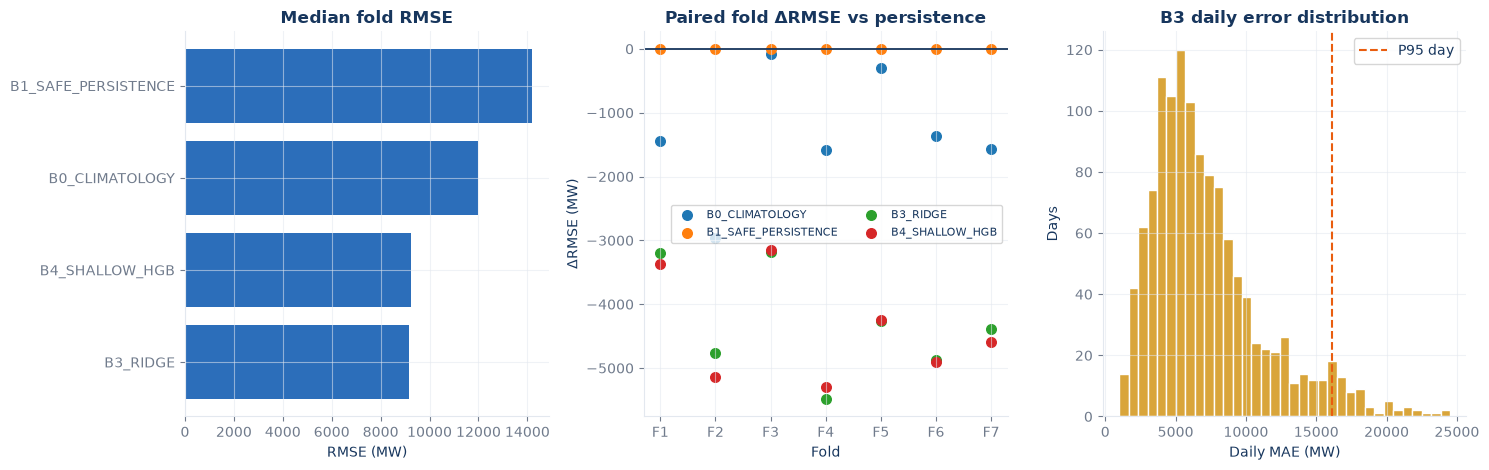

In [73]:
# -----------------------------------------------------------------
# Grid-stress thresholds and regime construction
# -----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
order = model_summary.sort_values("median_rmse_mw")["model_id"].tolist()
axes[0].barh(order, model_summary.set_index("model_id").loc[order, "median_rmse_mw"], color=COLORS["blue"])
axes[0].set(title="Median fold RMSE", xlabel="RMSE (MW)")
for model_id, group in fold_metrics.groupby("model_id"):
    axes[1].scatter(group["fold_id"], group["rmse_mw"] - group["persistence_rmse_mw"], label=model_id, s=48)
axes[1].axhline(0, color=COLORS["ink"], linewidth=1.3)
axes[1].set(title="Paired fold ΔRMSE vs persistence", xlabel="Fold", ylabel="ΔRMSE (MW)")
axes[1].legend(fontsize=8, ncol=2)
b3_daily = daily_metrics.loc[daily_metrics["model_id"].eq("B3_RIDGE"), "daily_mae_mw"]
axes[2].hist(b3_daily, bins=35, color=COLORS["gold"], edgecolor="white")
axes[2].axvline(b3_daily.quantile(.95), color=COLORS["orange"], linestyle="--", label="P95 day")
axes[2].set(title="B3 daily error distribution", xlabel="Daily MAE (MW)", ylabel="Days")
axes[2].legend()
finish_figure(fig, "baseline_comparison", "Which honest baseline or model wins, fold by fold and day by day?")

### Inspect horizon and profile behavior

Inspect the stated units, time range and support before interpreting the resulting table or figure.

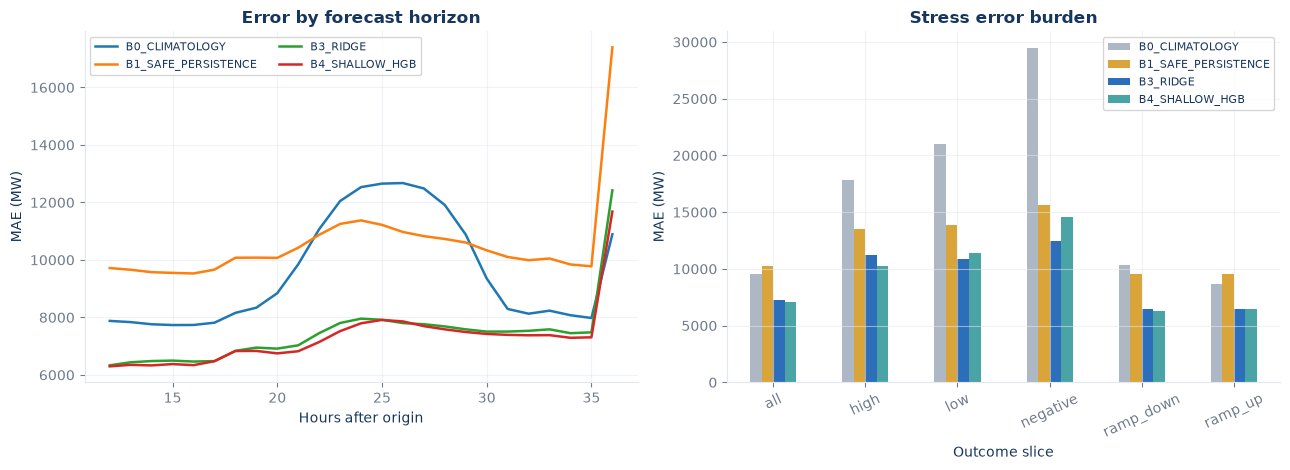

In [74]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for model_id, group in horizon_profile.groupby("model_id"):
    axes[0].plot(group["horizon_hours"], group["mae_mw"], label=model_id, linewidth=1.8)
axes[0].set(title="Error by forecast horizon", xlabel="Hours after origin", ylabel="MAE (MW)")
axes[0].legend(fontsize=8, ncol=2)
burden_pivot = stress_error_burden.pivot(index="slice", columns="model_id", values="mae_mw")
burden_pivot.plot(kind="bar", ax=axes[1], color=[COLORS["blocked"], COLORS["gold"], COLORS["blue"], COLORS["teal"]][:len(burden_pivot.columns)])
axes[1].set(title="Stress error burden", xlabel="Outcome slice", ylabel="MAE (MW)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(fontsize=8)
finish_figure(fig, "horizon_and_stress_burden", "Where in the horizon and stress tails does the model fail?")

### Separate positive and negative residual-load tasks

Inspect the stated units, time range and support before interpreting the resulting table or figure.

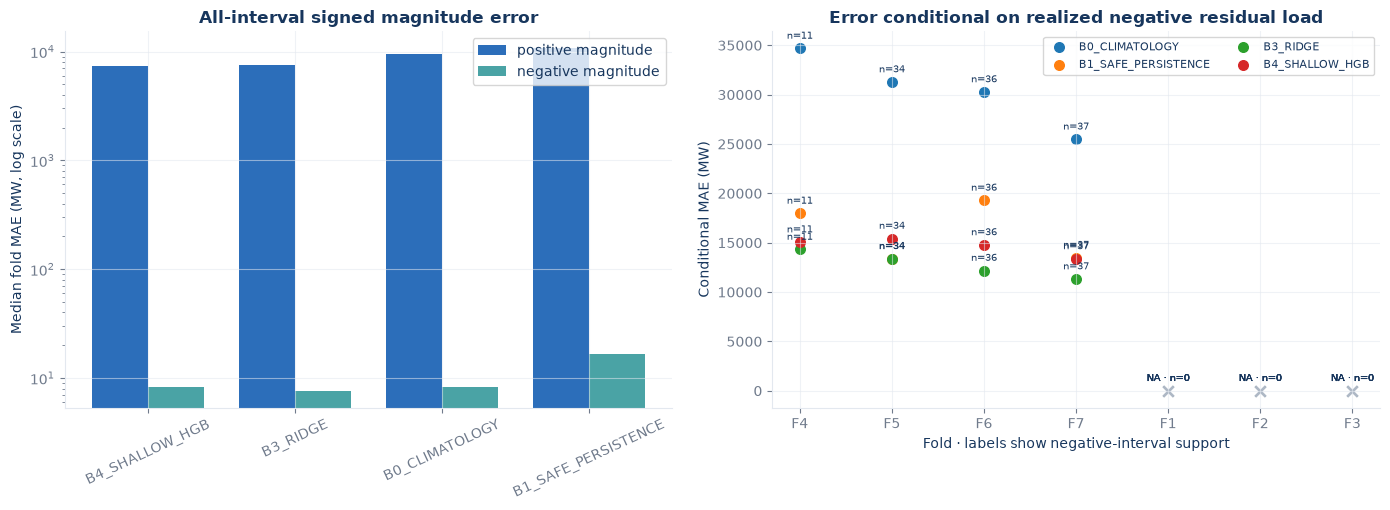

,model_id,positive_magnitude_mae_all_mw,negative_magnitude_mae_all_mw,positive_conditional_mae_mw,negative_conditional_mae_mw,positive_support,negative_support,negative_prevalence,sign_accuracy
0,B0_CLIMATOLOGY,9440.451370,8.258552,9322.476084,30771.948146,4188.0,11.0,0.00265,0.997350
1,B1_SAFE_PERSISTENCE,10672.362836,16.517104,10677.498265,15726.652027,4188.0,11.0,0.00265,0.994700
2,B3_RIDGE,7475.074471,7.631554,7464.950960,12779.539467,4188.0,11.0,0.00265,0.997591
3,B4_SHALLOW_HGB,7376.571879,8.258552,7376.571879,14914.389999,4188.0,11.0,0.00265,0.997350


In [75]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
# Question: does forecast quality hold for both positive demand-left and negative VRE-surplus states?
signed_task_rows = []
for (fold_id, model_id), group in predictions.groupby(["fold_id", "model_id"]):
    actual = group["y_true_mw"].to_numpy(float)
    predicted = group["y_pred_mw"].to_numpy(float)
    actual_positive = np.maximum(actual, 0.0)
    predicted_positive = np.maximum(predicted, 0.0)
    actual_negative_magnitude = np.maximum(-actual, 0.0)
    predicted_negative_magnitude = np.maximum(-predicted, 0.0)
    positive_mask = actual > 0
    negative_mask = actual < 0
    signed_task_rows.append({
        "fold_id": fold_id, "model_id": model_id,
        "positive_magnitude_mae_all_mw": float(np.mean(np.abs(predicted_positive - actual_positive))),
        "negative_magnitude_mae_all_mw": float(np.mean(np.abs(predicted_negative_magnitude - actual_negative_magnitude))),
        "positive_conditional_mae_mw": float(np.mean(np.abs(predicted[positive_mask] - actual[positive_mask]))) if positive_mask.any() else np.nan,
        "negative_conditional_mae_mw": float(np.mean(np.abs(predicted[negative_mask] - actual[negative_mask]))) if negative_mask.any() else np.nan,
        "positive_support": int(positive_mask.sum()),
        "negative_support": int(negative_mask.sum()),
        "negative_prevalence": float(negative_mask.mean()),
        "sign_accuracy": float(np.mean((predicted < 0) == negative_mask)),
    })
signed_task_metrics = pd.DataFrame(signed_task_rows)
signed_task_summary = signed_task_metrics.groupby("model_id", as_index=False).median(numeric_only=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
model_order = signed_task_summary.sort_values("positive_magnitude_mae_all_mw")["model_id"]
plot_summary = signed_task_summary.set_index("model_id").loc[model_order]
x = np.arange(len(plot_summary))
width = .38
axes[0].bar(x - width / 2, plot_summary["positive_magnitude_mae_all_mw"], width,
            label="positive magnitude", color=COLORS["blue"])
axes[0].bar(x + width / 2, plot_summary["negative_magnitude_mae_all_mw"], width,
            label="negative magnitude", color=COLORS["teal"])
axes[0].set(xticks=x, xticklabels=model_order, title="All-interval signed magnitude error",
            ylabel="Median fold MAE (MW, log scale)")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend()
for model_id, group in signed_task_metrics.groupby("model_id"):
    finite = group["negative_conditional_mae_mw"].notna()
    axes[1].scatter(group.loc[finite, "fold_id"], group.loc[finite, "negative_conditional_mae_mw"],
                    label=model_id, s=48)
    for row in group.itertuples(index=False):
        if np.isfinite(row.negative_conditional_mae_mw):
            axes[1].annotate(f"n={row.negative_support}",
                             (row.fold_id, row.negative_conditional_mae_mw),
                             xytext=(0, 7), textcoords="offset points", ha="center", fontsize=7)
        else:
            axes[1].scatter([row.fold_id], [0], marker="x", s=55, color=COLORS["blocked"])
            axes[1].annotate("NA · n=0", (row.fold_id, 0), xytext=(0, 7),
                             textcoords="offset points", ha="center", fontsize=7)
axes[1].set(title="Error conditional on realized negative residual load",
            xlabel="Fold · labels show negative-interval support", ylabel="Conditional MAE (MW)")
axes[1].legend(fontsize=8, ncol=2)
finish_figure(fig, "signed_residual_tasks", "Does forecast quality survive both positive demand and negative surplus regimes?")
display(signed_task_summary)

## 8A. Separate upper and lower/negative stress heads

**Question:** can the feature system rank high-demand-left stress separately from
low/negative VRE-surplus stress?

Two fold-local logistic heads use the same B3 information set. They are not collapsed
into one label: upper stress predicts the frozen P95 event; lower/negative stress
predicts either the frozen P05 event or a negative residual. Metrics remain
probability-aware (PR-AUC, ROC-AUC, Brier and log loss).


### Fit the upper and lower stress heads · 1/2

Each head answers a different event question. Zero support and single-class folds are not hidden by pooled averages.

In [76]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------
tail_head_rows = []
tail_head_metric_rows = []
tail_tasks = OrderedDict([
    ("upper_tail", lambda frame: frame["stress_high"].astype(int)),
    (
        "lower_or_negative_tail",
        lambda frame: (
            frame["stress_low"].astype(bool)
            | frame["stress_negative"].astype(bool)
        ).astype(int),
    ),
])
for _, fold in active_fold_specification.iterrows():
    train, valid = fold_frames(feature_matrix, fold)
    fold_id = str(fold["fold_id"])
    core_features = selected_features_by_fold[fold_id]
    for task_id, target_builder in tail_tasks.items():
        y_train = target_builder(train)
        y_valid = target_builder(valid)
        model_train = train
        if SMOKE_TEST and len(model_train) > 6_000:
            positions = np.arange(
                0, len(model_train),
                max(1, len(model_train) // 6_000),
            )
            model_train = model_train.iloc[positions]
            y_train = y_train.iloc[positions]
        prevalence = float(y_train.mean())
        if y_train.nunique() >= 2:
            model = Pipeline([
                ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                ("scale", StandardScaler()),
                ("logistic", LogisticRegression(
                    C=.25, max_iter=400, solver="liblinear",
                    random_state=RANDOM_SEED,
                )),
            ])
            model.fit(model_train[core_features], y_train)
            risk = model.predict_proba(valid[core_features])[:, 1]
        else:
            risk = np.full(len(valid), prevalence)
        risk = np.clip(np.asarray(risk, dtype=float), 1e-7, 1 - 1e-7)
        y_array = y_valid.to_numpy(int)
        tail_head_rows.append(pd.DataFrame({
            "fold_id": fold_id,
            "task_id": task_id,
            "target_time_utc": valid["target_time_utc"].to_numpy(),
            "target_date_local": valid["target_date_local"].to_numpy(),
            "y_true": y_array,
            "risk_score": risk,
        }))
        tail_head_metric_rows.append({
            "fold_id": fold_id,
            "task_id": task_id,
            "support": len(y_array),
            "positive_support": int(y_array.sum()),
            "prevalence": float(y_array.mean()),
            "average_precision": (
                float(average_precision_score(y_array, risk))
                if y_array.sum() else np.nan
            ),
            "roc_auc": (
                float(roc_auc_score(y_array, risk))
                if np.unique(y_array).size == 2 else np.nan
            ),
            "brier": float(brier_score_loss(y_array, risk)),
            "log_loss": float(log_loss(y_array, risk, labels=[0, 1])),
        })
tail_head_predictions = pd.concat(tail_head_rows, ignore_index=True)

### Fit the upper and lower stress heads · 2/2

Each head answers a different event question. Zero support and single-class folds are not hidden by pooled averages.

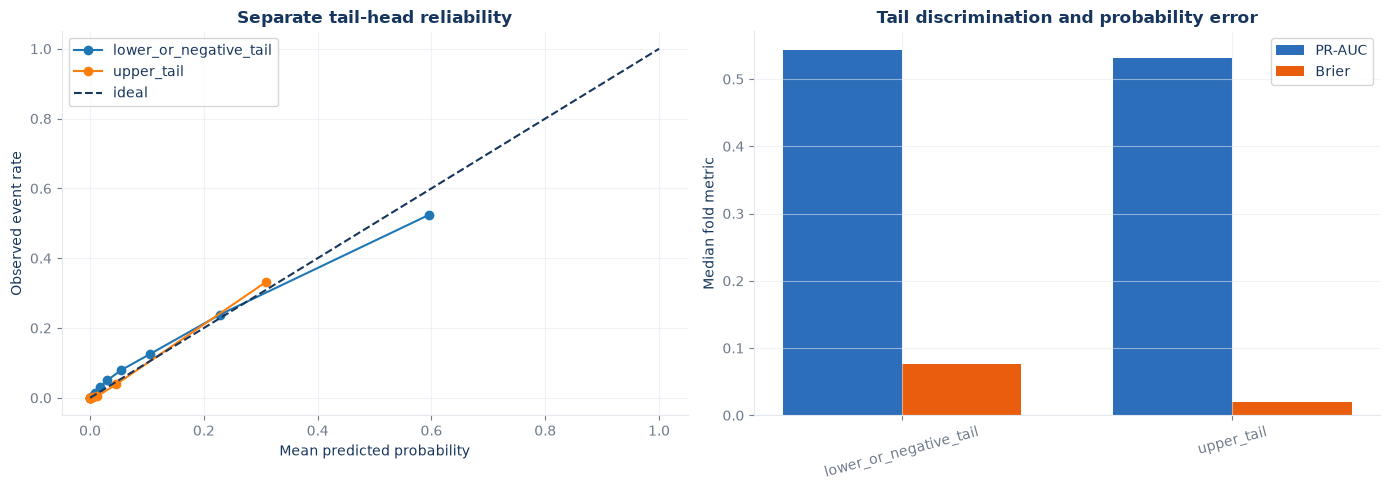

,task_id,support,positive_support,prevalence,average_precision,roc_auc,brier,log_loss
0,lower_or_negative_tail,4225.0,490.0,0.118044,0.543744,0.880142,0.075554,0.248257
1,upper_tail,4225.0,129.0,0.030533,0.530783,0.969787,0.020355,0.064214


In [77]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
tail_head_metrics = pd.DataFrame(tail_head_metric_rows)
tail_head_summary = tail_head_metrics.groupby("task_id", as_index=False).median(
    numeric_only=True
)

tail_calibration_rows = []
for task_id, group in tail_head_predictions.groupby("task_id"):
    group = group.copy()
    quantile_count = min(10, max(2, group["risk_score"].nunique()))
    group["risk_bin"] = pd.qcut(
        group["risk_score"].rank(method="first"),
        quantile_count, labels=False,
    )
    calibration = group.groupby("risk_bin", as_index=False).agg(
        mean_risk=("risk_score", "mean"),
        observed_rate=("y_true", "mean"),
        support=("y_true", "size"),
    )
    calibration["task_id"] = task_id
    tail_calibration_rows.append(calibration)
tail_head_calibration = pd.concat(tail_calibration_rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
for task_id, group in tail_head_calibration.groupby("task_id"):
    axes[0].plot(
        group["mean_risk"], group["observed_rate"], marker="o", label=task_id
    )
axes[0].plot([0, 1], [0, 1], linestyle="--", color=COLORS["ink"], label="ideal")
axes[0].set(
    title="Separate tail-head reliability",
    xlabel="Mean predicted probability",
    ylabel="Observed event rate",
)
axes[0].legend()
x = np.arange(len(tail_head_summary))
axes[1].bar(
    x - .18, tail_head_summary["average_precision"], .36,
    label="PR-AUC", color=COLORS["blue"],
)
axes[1].bar(
    x + .18, tail_head_summary["brier"], .36,
    label="Brier", color=COLORS["orange"],
)
axes[1].set(
    xticks=x, xticklabels=tail_head_summary["task_id"],
    title="Tail discrimination and probability error",
    ylabel="Median fold metric",
)
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend()
finish_figure(
    fig, "separate_tail_heads",
    "Can upper and lower/negative residual-load stress be ranked separately?"
)
display(tail_head_summary)

## 8B. Grouped OOF importance and exact Ridge attribution

**Question:** which B3 family matters when its entire local-day geometry is displaced,
and which family pushes each individual prediction?

This is deliberately separate from the cumulative feature ladder. For each outer
validation fold, a family is permuted as complete Berlin-local day profiles within
equal-length (23/24/25-hour) strata. The resulting ΔRMSE, ΔMAE and Δtail-MAE are
out-of-fold. The linear attribution uses the fitted imputer, scaler and Ridge
coefficients and asserts that intercept plus all transformed contributions exactly
reconstructs every prediction.


**Scope:** grouped permutation and exact signed attribution here explain the **B3 core
F0–F6 Ridge model**. Later signal/control/interaction families are assessed by the cumulative
ladder; they are not assigned invented B3 importance scores. One seeded block permutation per
fold is descriptive; its fold spread is not a repeated-permutation confidence interval.
Derived features can share information across families, so importance is not physical causality.


### Explain B3 with grouped OOF importance · 1/3

Permutation preserves each complete local-day profile within its DST-length stratum. Signed Ridge contributions plus the intercept must reconstruct the saved prediction.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [78]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def fit_explainable_ridge(
    train: pd.DataFrame, features: list[str]
) -> Pipeline:
    model_train = train
    if SMOKE_TEST and len(model_train) > 6_000:
        stride = max(1, len(model_train) // 6_000)
        model_train = model_train.iloc[np.arange(0, len(model_train), stride)]
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
        ("ridge", Ridge(alpha=10.0)),
    ])
    model.fit(model_train[features], model_train["residual_load_mw"].to_numpy(float))
    return model



# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def permute_complete_local_day_blocks(
    frame: pd.DataFrame,
    columns: list[str],
    seed: int,
) -> pd.DataFrame:
    result = frame.copy()
    groups = [
        (day, group.sort_values("target_time_utc").index.to_numpy())
        for day, group in frame.groupby("target_date_local", sort=True)
    ]
    rng = np.random.default_rng(seed)
    by_size: dict[int, list[np.ndarray]] = {}
    for _, positions in groups:
        by_size.setdefault(len(positions), []).append(positions)
    for block_size, blocks in by_size.items():
        donor_order = rng.permutation(len(blocks))
        if len(blocks) > 1 and np.array_equal(donor_order, np.arange(len(blocks))):
            donor_order = np.roll(donor_order, 1)
        source_values = [frame.loc[index, columns].to_numpy() for index in blocks]
        for receiver_index, donor_index in enumerate(donor_order):
            result.loc[blocks[receiver_index], columns] = source_values[donor_index]
    return result

### Explain B3 with grouped OOF importance · 2/3

Permutation preserves each complete local-day profile within its DST-length stratum. Signed Ridge contributions plus the intercept must reconstruct the saved prediction.

In [79]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
feature_to_family = {
    feature: family
    for family, features in FEATURE_FAMILIES.items()
    for feature in features
}
grouped_importance_rows = []
attribution_parts = []
attribution_reconstruction_rows = []
for fold_number, (_, fold) in enumerate(active_fold_specification.iterrows()):
    train, valid = fold_frames(feature_matrix, fold)
    fold_id = str(fold["fold_id"])
    core_features = selected_features_by_fold[fold_id]
    model = fit_explainable_ridge(train, core_features)
    baseline_prediction = model.predict(valid[core_features])
    saved_b3 = (
        predictions.loc[
            predictions["fold_id"].eq(fold_id)
            & predictions["model_id"].eq("B3_RIDGE")
        ]
        .sort_values("target_time_utc")
    )
    valid_sorted = valid.sort_values("target_time_utc")
    refit_sorted = model.predict(valid_sorted[core_features])
    max_refit_difference = float(
        np.max(np.abs(saved_b3["y_pred_mw"].to_numpy(float) - refit_sorted))
    )
    if max_refit_difference > 1e-8:
        raise AssertionError(
            f"Refitted attribution model does not reproduce B3 in {fold_id}: "
            f"{max_refit_difference}"
        )

    baseline = regression_metrics(valid["residual_load_mw"], baseline_prediction)
    tail_mask = valid[["stress_high", "stress_low", "stress_negative"]].any(
        axis=1
    ).to_numpy()
    baseline_tail = (
        float(mean_absolute_error(
            valid.loc[tail_mask, "residual_load_mw"],
            baseline_prediction[tail_mask],
        ))
        if tail_mask.any() else np.nan
    )
    for family in FEATURE_FAMILIES:
        family_features = [
            feature for feature in core_features
            if feature_to_family.get(feature) == family
        ]
        if not family_features:
            continue
        shuffled = permute_complete_local_day_blocks(
            valid,
            family_features,
            seed=RANDOM_SEED + 100 * fold_number + list(FEATURE_FAMILIES).index(family),
        )
        permuted_prediction = model.predict(shuffled[core_features])
        permuted = regression_metrics(
            valid["residual_load_mw"], permuted_prediction
        )
        permuted_tail = (
            float(mean_absolute_error(
                valid.loc[tail_mask, "residual_load_mw"],
                permuted_prediction[tail_mask],
            ))
            if tail_mask.any() else np.nan
        )
        grouped_importance_rows.append({
            "fold_id": fold_id,
            "family": family,
            "feature_count": len(family_features),
            "support": len(valid),
            "delta_rmse_mw": permuted["rmse_mw"] - baseline["rmse_mw"],
            "delta_mae_mw": permuted["mae_mw"] - baseline["mae_mw"],
            "delta_tail_mae_mw": permuted_tail - baseline_tail,
            "permutation_unit": "complete Berlin-local day within DST-length stratum",
        })

    imputer = model.named_steps["imputer"]
    scaler = model.named_steps["scale"]
    ridge = model.named_steps["ridge"]
    imputed = imputer.transform(valid[core_features])
    transformed = scaler.transform(imputed)
    transformed_names = list(imputer.get_feature_names_out(core_features))
    transformed_to_family = {}
    for transformed_name in transformed_names:
        if transformed_name in feature_to_family:
            parent = transformed_name
        elif transformed_name.startswith("missingindicator_"):
            parent = transformed_name.removeprefix("missingindicator_")
        else:
            matches = [
                name for name in core_features if transformed_name.endswith(name)
            ]
            if len(matches) != 1:
                raise KeyError(
                    f"Cannot map transformed feature {transformed_name!r}"
                )
            parent = matches[0]
        transformed_to_family[transformed_name] = feature_to_family[parent]
    grouped_signed, grouped_absolute = grouped_linear_contributions(
        transformed,
        ridge.coef_,
        transformed_names,
        transformed_to_family,
    )
    reconstructed = float(ridge.intercept_) + grouped_signed.sum(axis=1)
    model_prediction = model.predict(valid[core_features])
    reconstruction_error = float(
        np.max(np.abs(reconstructed.to_numpy(float) - model_prediction))
    )
    if reconstruction_error > 1e-8:
        raise AssertionError(
            f"Grouped contributions fail to reconstruct {fold_id}: "
            f"{reconstruction_error}"
        )
    dominant_family = grouped_absolute.idxmax(axis=1)
    dominant_position = [
        grouped_signed.columns.get_loc(name) for name in dominant_family
    ]
    dominant_signed = grouped_signed.to_numpy()[
        np.arange(len(grouped_signed)), dominant_position
    ]
    part = valid[[
        "target_time_utc", "target_date_local", "forecast_origin_utc",
        "residual_load_mw",
    ]].reset_index(drop=True)
    part["fold_id"] = fold_id
    part["model_id"] = "B3_RIDGE"
    part["y_pred_mw"] = model_prediction
    part["dominant_feature_family"] = dominant_family.to_numpy()
    part["dominant_family_contribution_mw"] = dominant_signed
    part["ridge_intercept_mw"] = float(ridge.intercept_)
    for family in grouped_signed.columns:
        part[f"contribution_signed__{family}"] = grouped_signed[family].to_numpy()
        part[f"contribution_absolute__{family}"] = grouped_absolute[family].to_numpy()
    attribution_parts.append(part)
    attribution_reconstruction_rows.append({
        "fold_id": fold_id,
        "rows": len(valid),
        "max_abs_reconstruction_error_mw": reconstruction_error,
        "max_abs_refit_vs_saved_b3_mw": max_refit_difference,
        "transformed_feature_count": len(transformed_names),
    })

### Explain B3 with grouped OOF importance · 3/3

Permutation preserves each complete local-day profile within its DST-length stratum. Signed Ridge contributions plus the intercept must reconstruct the saved prediction.

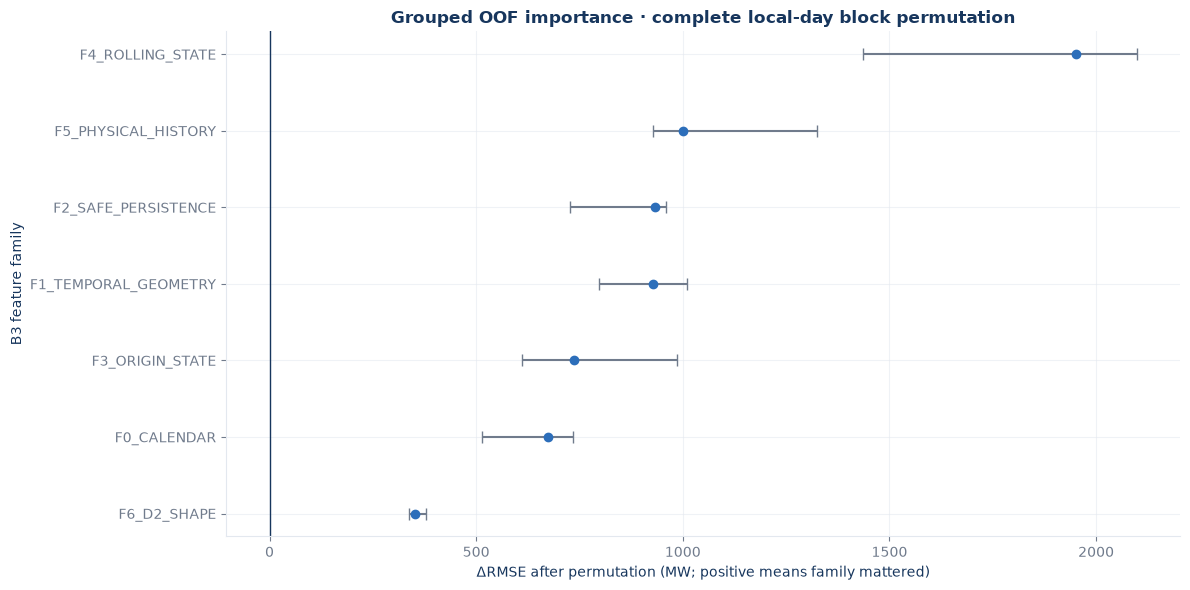

,family,folds,median_delta_rmse_mw,q25_delta_rmse_mw,q75_delta_rmse_mw,median_delta_mae_mw,median_delta_tail_mae_mw,median_feature_count
6,F6_D2_SHAPE,7,351.409753,336.439421,378.742614,310.867235,682.242008,2.0
0,F0_CALENDAR,7,674.410762,513.046973,733.104257,536.670075,1425.832900,8.0
3,F3_ORIGIN_STATE,7,736.059355,611.170455,986.183039,651.073349,2147.738518,4.0
1,F1_TEMPORAL_GEOMETRY,7,928.217867,796.114228,1009.203424,831.004867,-14.929744,8.0
2,F2_SAFE_PERSISTENCE,7,933.120314,726.706183,960.381287,637.993406,1739.341056,5.0
5,F5_PHYSICAL_HISTORY,7,1001.289035,928.795496,1323.947069,798.091329,1782.703084,8.0
4,F4_ROLLING_STATE,7,1950.899172,1435.720463,2098.059085,1308.097979,2829.400739,7.0


,fold_id,rows,max_abs_reconstruction_error_mw,max_abs_refit_vs_saved_b3_mw,transformed_feature_count
0,F1,4225,1.455192e-11,0.0,61
1,F2,4151,1.818989e-11,0.0,61
2,F3,4225,2.182787e-11,0.0,61
3,F4,4151,2.910383e-11,0.0,61
4,F5,4225,2.546585e-11,0.0,61
5,F6,4175,2.182787e-11,0.0,61
6,F7,4225,1.818989e-11,0.0,61


In [80]:
# -----------------------------------------------------------------
# Grid-stress thresholds and regime construction
# -----------------------------------------------------------------
grouped_oof_importance = pd.DataFrame(grouped_importance_rows)
grouped_importance_summary = grouped_oof_importance.groupby(
    "family", as_index=False
).agg(
    folds=("fold_id", "nunique"),
    median_delta_rmse_mw=("delta_rmse_mw", "median"),
    q25_delta_rmse_mw=("delta_rmse_mw", lambda values: values.quantile(.25)),
    q75_delta_rmse_mw=("delta_rmse_mw", lambda values: values.quantile(.75)),
    median_delta_mae_mw=("delta_mae_mw", "median"),
    median_delta_tail_mae_mw=("delta_tail_mae_mw", "median"),
    median_feature_count=("feature_count", "median"),
).sort_values("median_delta_rmse_mw")
attribution_oof = pd.concat(attribution_parts, ignore_index=True)
attribution_reconstruction_audit = pd.DataFrame(
    attribution_reconstruction_rows
)

fig, ax = plt.subplots(figsize=(12, 6.0))
ordered = grouped_importance_summary.sort_values("median_delta_rmse_mw")
lower = ordered["median_delta_rmse_mw"] - ordered["q25_delta_rmse_mw"]
upper = ordered["q75_delta_rmse_mw"] - ordered["median_delta_rmse_mw"]
ax.errorbar(
    ordered["median_delta_rmse_mw"], ordered["family"],
    xerr=np.vstack([lower, upper]), fmt="o", capsize=4,
    color=COLORS["blue"], ecolor=COLORS["muted"],
)
ax.axvline(0, color=COLORS["ink"], linewidth=1)
ax.set(
    title="Grouped OOF importance · complete local-day block permutation",
    xlabel="ΔRMSE after permutation (MW; positive means family mattered)",
    ylabel="B3 feature family",
)
finish_figure(
    fig, "grouped_oof_feature_importance",
    "Which feature family matters beyond cumulative ladder order?"
)
display(grouped_importance_summary)
display(attribution_reconstruction_audit)

## 9. Feature-family promotion

Promotion is based on paired fold evidence, never a pooled leaderboard. A family is statistically
eligible only when full execution wins at least five of seven folds, improves median RMSE and MAE,
avoids a worst-fold degradation above 2%, and does not worsen tail MAE. Calendar is core. Any family
derived from today's realized-history extract remains `RESEARCH_ONLY_REVISION_UNVERIFIED` regardless
of score until historical source vintages prove what was available then. Official forecasts and
forecast-error histories stay blocked until source qualification. Interactions are tested last and one
family at a time.


### Apply family-promotion gates and paired uncertainty · 1/3

Promotion is conditional on seven-fold evidence AND provenance. The paired bootstrap never stitches across a calendar gap or a fold boundary.

**Definition cell:** execute this before the calculation that follows; it does not by itself fit a model or validate data.

In [81]:
# -----------------------------------------------------------------
# Grid-stress thresholds and regime construction
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def fold_aware_moving_block_bootstrap(
    frame: pd.DataFrame, fold_col: str, date_col: str, value_col: str,
    block_length: int = 14, n_bootstrap: int = 500, seed: int = RANDOM_SEED
) -> tuple[float, float, float]:
    clean = frame[[fold_col, date_col, value_col]].copy()
    clean[date_col] = pd.to_datetime(clean[date_col])
    clean[value_col] = pd.to_numeric(clean[value_col], errors="coerce")
    clean = clean.loc[clean[value_col].notna()].sort_values([fold_col, date_col])
    contiguous_arrays = []
    for _, fold_group in clean.groupby(fold_col, sort=False):
        fold_group = fold_group.sort_values(date_col)
        run_id = fold_group[date_col].diff().dt.days.ne(1).cumsum()
        contiguous_arrays.extend(
            run[value_col].to_numpy(float)
            for _, run in fold_group.groupby(run_id, sort=False)
            if len(run)
        )
    if not contiguous_arrays:
        return float("nan"), float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    estimates = []
    for _ in range(n_bootstrap):
        sampled_runs = []
        for array in contiguous_arrays:
            run_block_length = max(1, min(block_length, array.size))
            starts = np.arange(0, max(1, array.size - run_block_length + 1))
            pieces = []
            while sum(len(piece) for piece in pieces) < array.size:
                start = int(rng.choice(starts))
                pieces.append(array[start:start + run_block_length])
            sampled_runs.append(np.concatenate(pieces)[:array.size])
        estimates.append(float(np.concatenate(sampled_runs).mean()))
    observed = float(np.concatenate(contiguous_arrays).mean())
    return observed, float(np.quantile(estimates, .025)), float(np.quantile(estimates, .975))

### Apply family-promotion gates and paired uncertainty · 2/3

Promotion is conditional on seven-fold evidence AND provenance. The paired bootstrap never stitches across a calendar gap or a fold boundary.

In [82]:
# -----------------------------------------------------------------
# Feature construction, lineage, and scientific evidence
# -----------------------------------------------------------------
families = list(FEATURE_FAMILIES)
promotion_rows = []
for index, family in enumerate(families):
    current = feature_family_results.loc[feature_family_results["family"].eq(family)].set_index("fold_id")
    if index == 0:
        promotion_rows.append({
            "family": family, "folds": len(current), "wins": len(current),
            "median_delta_rmse_mw": 0.0, "median_delta_mae_mw": 0.0,
            "worst_degradation_pct": 0.0, "median_tail_delta_mw": 0.0,
            "promotion_decision": "CORE",
        })
        continue
    previous = feature_family_results.loc[
        feature_family_results["family"].eq(families[index - 1])
    ].set_index("fold_id")
    shared = current.index.intersection(previous.index)
    delta_rmse = current.loc[shared, "rmse_mw"] - previous.loc[shared, "rmse_mw"]
    delta_mae = current.loc[shared, "mae_mw"] - previous.loc[shared, "mae_mw"]
    delta_tail = current.loc[shared, "tail_mae_mw"] - previous.loc[shared, "tail_mae_mw"]
    worst_pct = float((delta_rmse / previous.loc[shared, "rmse_mw"] * 100).max())
    full_gate = (
        len(shared) == 7 and int((delta_rmse < 0).sum()) >= 5
        and float(delta_rmse.median()) < 0 and float(delta_mae.median()) < 0
        and worst_pct <= 2.0 and float(delta_tail.median()) <= 0
    )
    family_catalog = feature_catalog.loc[feature_catalog["family"].eq(family)]
    revision_unverified = bool(
        family_catalog["revision_policy"].astype(str).str.contains("UNVERIFIED_CURRENT_EXTRACT").any()
    )
    single_event_adaptation = family == "S3_INTERVENTION_ADAPTATION"
    if VALIDATION_FIXTURE:
        decision = "SOFTWARE_TEST_ONLY"
    elif single_event_adaptation:
        decision = "RESEARCH_ONLY_SINGLE_EVENT_ADAPTATION"
    elif revision_unverified and REVISION_VINTAGE_GATE != "VERIFIED_HISTORICAL_VINTAGES":
        decision = "RESEARCH_ONLY_REVISION_UNVERIFIED"
    elif SMOKE_TEST:
        decision = "SMOKE_ONLY"
    elif full_gate:
        decision = "PROMOTED"
    elif float(delta_rmse.median()) < 0 and int((delta_rmse < 0).sum()) >= 4:
        decision = "CONDITIONAL"
    elif delta_rmse.min() < 0:
        decision = "FOLD_SPECIFIC"
    else:
        decision = "REJECTED"
    promotion_rows.append({
        "family": family, "folds": len(shared), "wins": int((delta_rmse < 0).sum()),
        "median_delta_rmse_mw": float(delta_rmse.median()),
        "median_delta_mae_mw": float(delta_mae.median()),
        "worst_degradation_pct": worst_pct,
        "median_tail_delta_mw": float(delta_tail.median()),
        "promotion_decision": decision,
    })
promotion_table = pd.DataFrame(promotion_rows)
display(promotion_table)

,family,folds,wins,median_delta_rmse_mw,median_delta_mae_mw,worst_degradation_pct,median_tail_delta_mw,promotion_decision
0,F0_CALENDAR,7,7,0.000000,0.000000,0.000000,0.000000,CORE
1,F1_TEMPORAL_GEOMETRY,7,7,-683.649465,-562.855141,-3.158059,-2002.327619,PROMOTED
2,F2_SAFE_PERSISTENCE,7,7,-2067.672896,-1671.848840,-7.198678,-5937.645413,RESEARCH_ONLY_REVISION_UNVERIFIED
3,F3_ORIGIN_STATE,7,7,-619.025712,-385.457653,-3.705125,-2637.008426,RESEARCH_ONLY_REVISION_UNVERIFIED
4,F4_ROLLING_STATE,7,6,-98.137737,-121.010311,0.979919,-20.634142,RESEARCH_ONLY_REVISION_UNVERIFIED
5,F5_PHYSICAL_HISTORY,7,7,-194.574521,-138.794333,-0.130363,-612.211357,RESEARCH_ONLY_REVISION_UNVERIFIED
6,F6_D2_SHAPE,7,6,-21.006832,-37.789833,0.562933,-0.140086,RESEARCH_ONLY_REVISION_UNVERIFIED
7,S0_SCHEDULED_CALENDAR_EVENTS,7,3,31.562878,18.556068,1.046748,-62.738725,FOLD_SPECIFIC
8,S1_DECLARED_SIGNAL_BASIS,7,2,6.864481,6.011386,0.125842,-14.488910,FOLD_SPECIFIC
9,S2_ORIGIN_SAFE_SPECTRAL_STATE,7,1,55.878479,48.181610,2.200609,129.832635,RESEARCH_ONLY_REVISION_UNVERIFIED


### Apply family-promotion gates and paired uncertainty · 3/3

Promotion is conditional on seven-fold evidence AND provenance. The paired bootstrap never stitches across a calendar gap or a fold boundary.

In [83]:
# -----------------------------------------------------------------
# Leakage-safe chronological validation
# -----------------------------------------------------------------
b3_days = daily_metrics.loc[daily_metrics["model_id"].eq("B3_RIDGE"), ["fold_id", "target_date_local", "daily_mae_mw"]]
b1_days = daily_metrics.loc[daily_metrics["model_id"].eq("B1_SAFE_PERSISTENCE"), ["fold_id", "target_date_local", "daily_mae_mw"]]
paired_keys = ["fold_id", "target_date_local"]
if b3_days.duplicated(paired_keys).any() or b1_days.duplicated(paired_keys).any():
    raise AssertionError("Daily comparison keys must be unique within each model.")
b3_key_set = set(map(tuple, b3_days[paired_keys].to_numpy()))
b1_key_set = set(map(tuple, b1_days[paired_keys].to_numpy()))
if b3_key_set != b1_key_set:
    raise AssertionError("B3 and B1 daily OOF keys differ; paired inference is invalid.")
paired_days = b3_days.merge(
    b1_days, on=paired_keys, suffixes=("_b3", "_b1"), validate="one_to_one"
).sort_values(paired_keys).reset_index(drop=True)
paired_days["delta_mae_mw"] = paired_days["daily_mae_mw_b3"] - paired_days["daily_mae_mw_b1"]
bootstrap_iterations = 120 if SMOKE_TEST else 1000
paired_daily_bootstrap = fold_aware_moving_block_bootstrap(
    paired_days, fold_col="fold_id", date_col="target_date_local", value_col="delta_mae_mw",
    block_length=14, n_bootstrap=bootstrap_iterations
)
print(
    "Research-only paired daily B3−B1 ΔMAE mean and 95% "
    "gap-aware moving-block interval:", paired_daily_bootstrap
)

Research-only paired daily B3−B1 ΔMAE mean and 95% gap-aware moving-block interval: (-3035.168149048182, -3482.3342700493304, -2575.5401256695654)


### Final feature-level promotion register

**Question:** what is the final disposition of every feature—not only its family?

The register merges provenance and availability, fold-local keep rate, B3 grouped
importance, family promotion evidence and the archive gate. A blocked input cannot be
promoted by a good score, and a visually strong diagnostic does not become a feature
without an origin-safe timestamp.


### Build the feature-level disposition register · 1/2

A missing importance entry means that family was not part of B3, not that its measured importance was zero.

In [84]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------
final_family = list(FEATURE_FAMILIES)[-1]
keep_counts = {feature: 0 for feature in candidate_names}
for fold_id in active_fold_specification["fold_id"].astype(str):
    kept = set(
        ladder_features_by_fold_family.get(
            f"{fold_id}|{final_family}", []
        )
    )
    for feature in keep_counts:
        keep_counts[feature] += int(feature in kept)
keep_rate = pd.DataFrame({
    "feature": list(keep_counts),
    "fold_keep_count": list(keep_counts.values()),
})
keep_rate["fold_keep_rate"] = (
    keep_rate["fold_keep_count"] / len(active_fold_specification)
)
final_feature_register = (
    feature_catalog
    .merge(keep_rate, on="feature", how="left", validate="one_to_one")
    .merge(
        promotion_table[[
            "family", "wins", "median_delta_rmse_mw",
            "median_tail_delta_mw", "promotion_decision",
        ]],
        on="family", how="left", validate="many_to_one",
    )
    .merge(
        grouped_importance_summary[[
            "family", "median_delta_rmse_mw",
            "median_delta_mae_mw", "median_delta_tail_mae_mw",
        ]].rename(columns={
            "median_delta_rmse_mw": "grouped_permutation_delta_rmse_mw",
            "median_delta_mae_mw": "grouped_permutation_delta_mae_mw",
            "median_delta_tail_mae_mw": "grouped_permutation_delta_tail_mae_mw",
        }),
        on="family", how="left", validate="many_to_one",
    )
)
final_feature_register["fold_keep_count"] = (
    final_feature_register["fold_keep_count"].fillna(0).astype(int)
)
final_feature_register["fold_keep_rate"] = (
    final_feature_register["fold_keep_rate"].fillna(0.0)
)

### Build the feature-level disposition register · 2/2

A missing importance entry means that family was not part of B3, not that its measured importance was zero.

In [85]:
# -----------------------------------------------------------------
# Missingness and data-quality controls
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# Reusable research logic
# -----------------------------------------------------------------
def final_feature_disposition(row: pd.Series) -> tuple[str, str]:
    initial = str(row["initial_decision"])
    if initial.startswith(("REJECT", "BLOCKED", "RESEARCH")):
        return initial, "provenance / timing gate dominates model score"
    decision = str(row.get("promotion_decision", "UNASSESSED"))
    if VALIDATION_FIXTURE:
        return "SOFTWARE_TEST_ONLY", "synthetic fixture cannot establish scientific utility"
    if initial == "CORE":
        return "CORE", "predeclared calendar representation; not an empirical promotion"
    if decision == "PROMOTED":
        return "PROMOTED", "family passed seven-fold promotion gates"
    if decision in {"CONDITIONAL", "FOLD_SPECIFIC"}:
        return decision, "benefit is not uniformly stable across time"
    if decision.startswith("RESEARCH"):
        return decision, "revision or single-event evidence remains insufficient"
    if decision == "SMOKE_ONLY":
        return "PENDING_FULL_RUN", "smoke execution cannot promote a feature"
    return "NOT_PROMOTED", "family did not pass the declared promotion gates"

dispositions = final_feature_register.apply(
    final_feature_disposition, axis=1
)
final_feature_register["final_disposition"] = [
    value[0] for value in dispositions
]
final_feature_register["final_reason"] = [
    value[1] for value in dispositions
]
promotion_receipt = (
    final_feature_register.groupby(
        ["family", "final_disposition", "final_reason"],
        dropna=False, as_index=False,
    )
    .agg(
        feature_count=("feature", "size"),
        median_fold_keep_rate=("fold_keep_rate", "median"),
        support_min=("support", "min"),
    )
    .sort_values(["family", "final_disposition"])
)
display(final_feature_register)
display(promotion_receipt)

,feature,family,source,event_or_valid_time,available_at_utc,revision_policy,...,promotion_decision,grouped_permutation_delta_rmse_mw,grouped_permutation_delta_mae_mw,grouped_permutation_delta_tail_mae_mw,final_disposition,final_reason
0,calendar_slot_index,F0_CALENDAR,calendar,target interval or historical source interval,known at schedule creation,not revised,...,CORE,674.410762,536.670075,1425.8329,CORE,predeclared calendar representation; not an em...
1,calendar_hour_raw,F0_CALENDAR,calendar,target interval or historical source interval,known at schedule creation,not revised,...,CORE,674.410762,536.670075,1425.8329,CORE,predeclared calendar representation; not an em...
2,calendar_dow_raw,F0_CALENDAR,calendar,target interval or historical source interval,known at schedule creation,not revised,...,CORE,674.410762,536.670075,1425.8329,CORE,predeclared calendar representation; not an em...
3,calendar_doy_raw,F0_CALENDAR,calendar,target interval or historical source interval,known at schedule creation,not revised,...,CORE,674.410762,536.670075,1425.8329,CORE,predeclared calendar representation; not an em...
4,calendar_month,F0_CALENDAR,calendar,target interval or historical source interval,known at schedule creation,not revised,...,CORE,674.410762,536.670075,1425.8329,CORE,predeclared calendar representation; not an em...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,football_match_schedule,F11_REGIME_RESEARCH,blocked or diagnostic,"unknown, target-derived, or analysis-only",five upstream matches are too sparse,not qualified,...,NaN,NaN,NaN,NaN,RESEARCH_ONLY,provenance / timing gate dominates model score
121,realized_weather_event,TARGET_OUTCOME,blocked or diagnostic,"unknown, target-derived, or analysis-only",future realized meteorology,not qualified,...,NaN,NaN,NaN,NaN,REJECT_LEAKAGE,provenance / timing gate dominates model score
122,weather_forecast_without_vintage,F7_OFFICIAL_FORECAST,blocked or diagnostic,"unknown, target-derived, or analysis-only",issued-at archive unavailable,not qualified,...,NaN,NaN,NaN,NaN,BLOCKED_OFFICIAL_FORECAST,provenance / timing gate dominates model score
123,who_covid_pheic_context,F11_REGIME_RESEARCH,blocked or diagnostic,"unknown, target-derived, or analysis-only",global context only,not qualified,...,NaN,NaN,NaN,NaN,RESEARCH_ONLY,provenance / timing gate dominates model score


,family,final_disposition,final_reason,feature_count,median_fold_keep_rate,support_min
0,F0_CALENDAR,CORE,predeclared calendar representation; not an em...,10,1.0,1.000000
1,F10_SELECTED_INTERACTIONS,RESEARCH_ONLY_REVISION_UNVERIFIED,revision or single-event evidence remains insu...,7,1.0,0.990028
2,F11_REGIME_RESEARCH,RESEARCH_ONLY,provenance / timing gate dominates model score,4,0.0,NaN
3,F1_TEMPORAL_GEOMETRY,CORE,predeclared calendar representation; not an em...,8,1.0,1.000000
4,F2_SAFE_PERSISTENCE,RESEARCH_ONLY_REVISION_UNVERIFIED,revision or single-event evidence remains insu...,5,1.0,0.995148
...,...,...,...,...,...,...
14,S1_DECLARED_SIGNAL_BASIS,FOLD_SPECIFIC,benefit is not uniformly stable across time,4,1.0,1.000000
15,S2_ORIGIN_SAFE_SPECTRAL_STATE,RESEARCH_ONLY_REVISION_UNVERIFIED,revision or single-event evidence remains insu...,9,1.0,0.990028
16,S3_INTERVENTION_ADAPTATION,RESEARCH_ONLY_SINGLE_EVENT_ADAPTATION,revision or single-event evidence remains insu...,7,1.0,0.999303
17,S4_CONTEXT_MODULATED_HARMONICS,PROMOTED,family passed seven-fold promotion gates,24,1.0,1.000000


### Plot feature-family changes

Inspect the stated units, time range and support before interpreting the resulting table or figure.

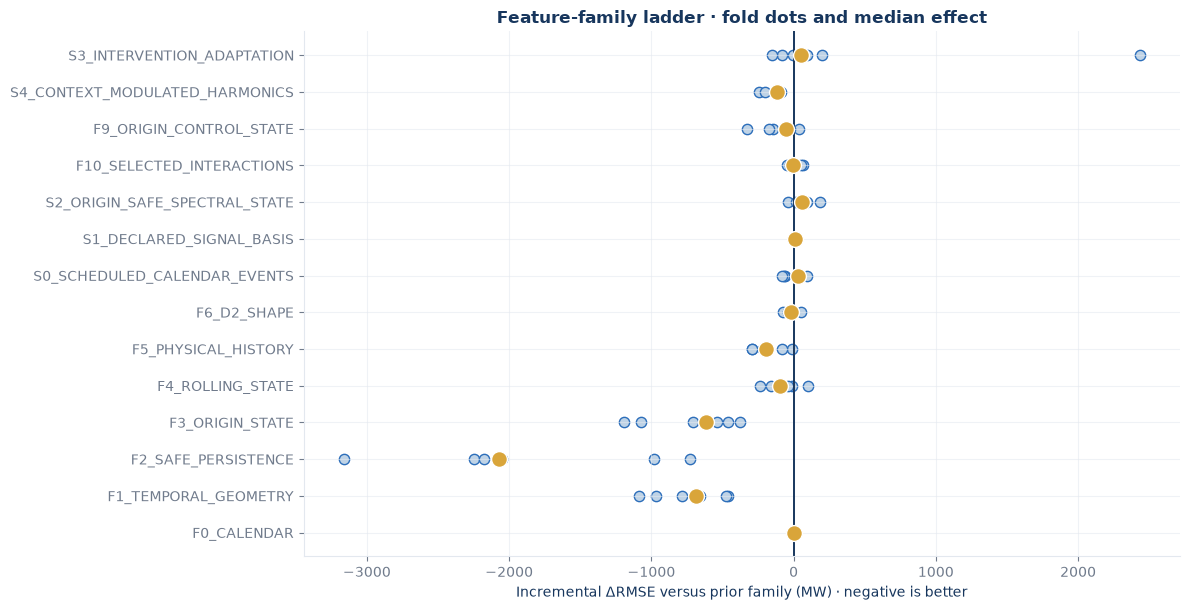

In [86]:
# -----------------------------------------------------------------
# Input schema and structural validation
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6.2))
for y, family in enumerate(families):
    current = feature_family_results.loc[feature_family_results["family"].eq(family)]
    if y == 0:
        deltas = np.zeros(len(current))
    else:
        previous = feature_family_results.loc[
            feature_family_results["family"].eq(families[y - 1]), ["fold_id", "rmse_mw"]
        ].rename(columns={"rmse_mw": "previous_rmse_mw"})
        deltas = current.merge(previous, on="fold_id")["rmse_mw"] - current.merge(previous, on="fold_id")["previous_rmse_mw"]
    ax.scatter(deltas, np.full(len(deltas), y), s=55, facecolor="#BFD3E6", edgecolor=COLORS["blue"])
    ax.scatter([np.median(deltas)], [y], s=130, color=COLORS["gold"], edgecolor="white", zorder=3)
ax.axvline(0, color=COLORS["ink"], linewidth=1.4)
ax.set(yticks=range(len(families)), yticklabels=families,
       xlabel="Incremental ΔRMSE versus prior family (MW) · negative is better",
       title="Feature-family ladder · fold dots and median effect")
finish_figure(fig, "feature_family_ladder", "Which family adds stable incremental value?")

### Summarize admitted core feature support

Inspect the stated units, time range and support before interpreting the resulting table or figure.

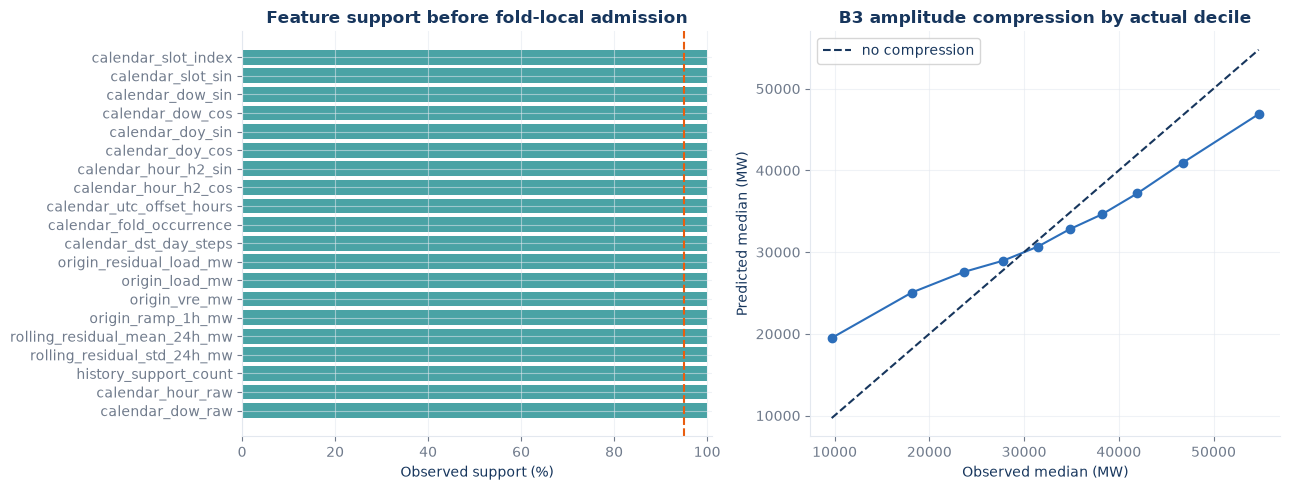

In [87]:
# -----------------------------------------------------------------
# Missingness and data-quality controls
# -----------------------------------------------------------------
core_support = feature_catalog.loc[feature_catalog["feature"].isin(accumulated_features("F6_D2_SHAPE"))].copy()
b3 = predictions.loc[predictions["model_id"].eq("B3_RIDGE")].copy()
compression = b3.assign(
    actual_decile=pd.qcut(b3["y_true_mw"], 10, labels=False, duplicates="drop")
).groupby("actual_decile", as_index=False).agg(
    observed_median_mw=("y_true_mw", "median"), predicted_median_mw=("y_pred_mw", "median"),
    support=("y_true_mw", "size"),
)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
support_plot = core_support.dropna(subset=["support"]).sort_values("support").tail(20)
axes[0].barh(support_plot["feature"], support_plot["support"] * 100, color=COLORS["teal"])
axes[0].axvline(95, color=COLORS["orange"], linestyle="--")
axes[0].set(title="Feature support before fold-local admission", xlabel="Observed support (%)", xlim=(0, 101))
axes[1].plot(compression["observed_median_mw"], compression["predicted_median_mw"], marker="o", color=COLORS["blue"])
limits = [min(compression[["observed_median_mw", "predicted_median_mw"]].min()),
          max(compression[["observed_median_mw", "predicted_median_mw"]].max())]
axes[1].plot(limits, limits, linestyle="--", color=COLORS["ink"], label="no compression")
axes[1].set(title="B3 amplitude compression by actual decile", xlabel="Observed median (MW)", ylabel="Predicted median (MW)")
axes[1].legend()
finish_figure(fig, "support_and_compression", "Do missingness or shrinkage erase the extreme cases?")

## 10. Calibration and failure observatory

Ranking rare events is not enough. Calibration is inspected by risk bin, alongside PR-AUC and Brier.
The failure observatory keeps distinct panels for chronology, local-hour/season concentration, target
amplitude compression, and the worst complete day. It does not mix residual-load MW, probability,
interval count, or day count on one scale.


### Inspect calibration and failures

Inspect the stated units, time range and support before interpreting the resulting table or figure.

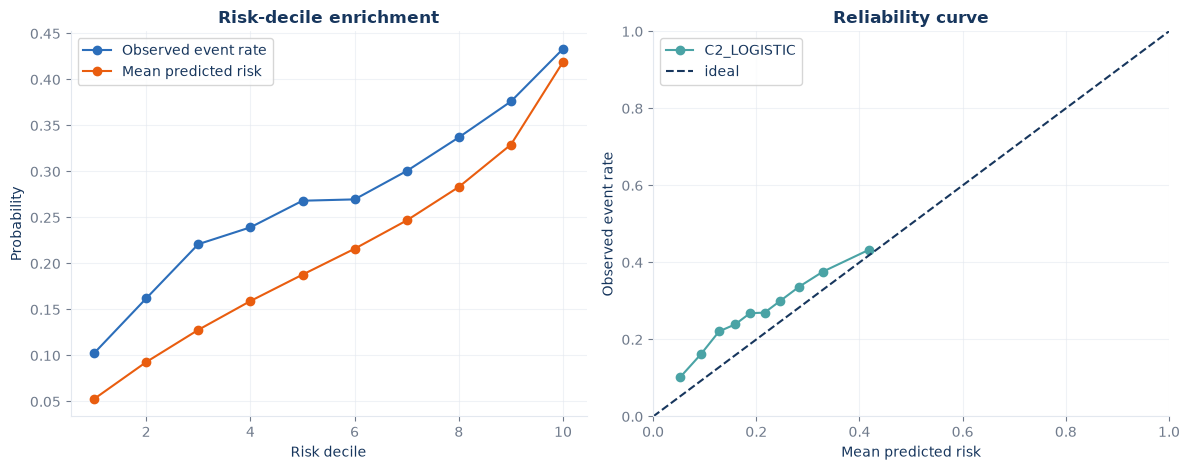

In [88]:
# -----------------------------------------------------------------
# Grid-stress thresholds and regime construction
# -----------------------------------------------------------------
logistic_oof = classification_predictions.loc[
    classification_predictions["model_id"].eq("C2_LOGISTIC")
].copy()
logistic_oof["risk_decile"] = pd.qcut(
    logistic_oof["risk_score"].rank(method="first"), 10, labels=False
)
risk_deciles = logistic_oof.groupby("risk_decile", as_index=False).agg(
    observed_event_rate=("y_true", "mean"), mean_predicted_risk=("risk_score", "mean"),
    support=("y_true", "size"),
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(risk_deciles["risk_decile"] + 1, risk_deciles["observed_event_rate"], marker="o", label="Observed event rate", color=COLORS["blue"])
axes[0].plot(risk_deciles["risk_decile"] + 1, risk_deciles["mean_predicted_risk"], marker="o", label="Mean predicted risk", color=COLORS["orange"])
axes[0].set(title="Risk-decile enrichment", xlabel="Risk decile", ylabel="Probability")
axes[0].legend()
fraction_positive, mean_predicted = calibration_curve(
    logistic_oof["y_true"], logistic_oof["risk_score"], n_bins=10, strategy="quantile"
)
axes[1].plot(mean_predicted, fraction_positive, marker="o", color=COLORS["teal"], label="C2_LOGISTIC")
axes[1].plot([0, 1], [0, 1], linestyle="--", color=COLORS["ink"], label="ideal")
axes[1].set(title="Reliability curve", xlabel="Mean predicted risk", ylabel="Observed event rate", xlim=(0, 1), ylim=(0, 1))
axes[1].legend()
finish_figure(fig, "classification_calibration", "Are stress probabilities useful as probabilities, not only ranks?")

### Locate the most difficult target profiles

Inspect the stated units, time range and support before interpreting the resulting table or figure.

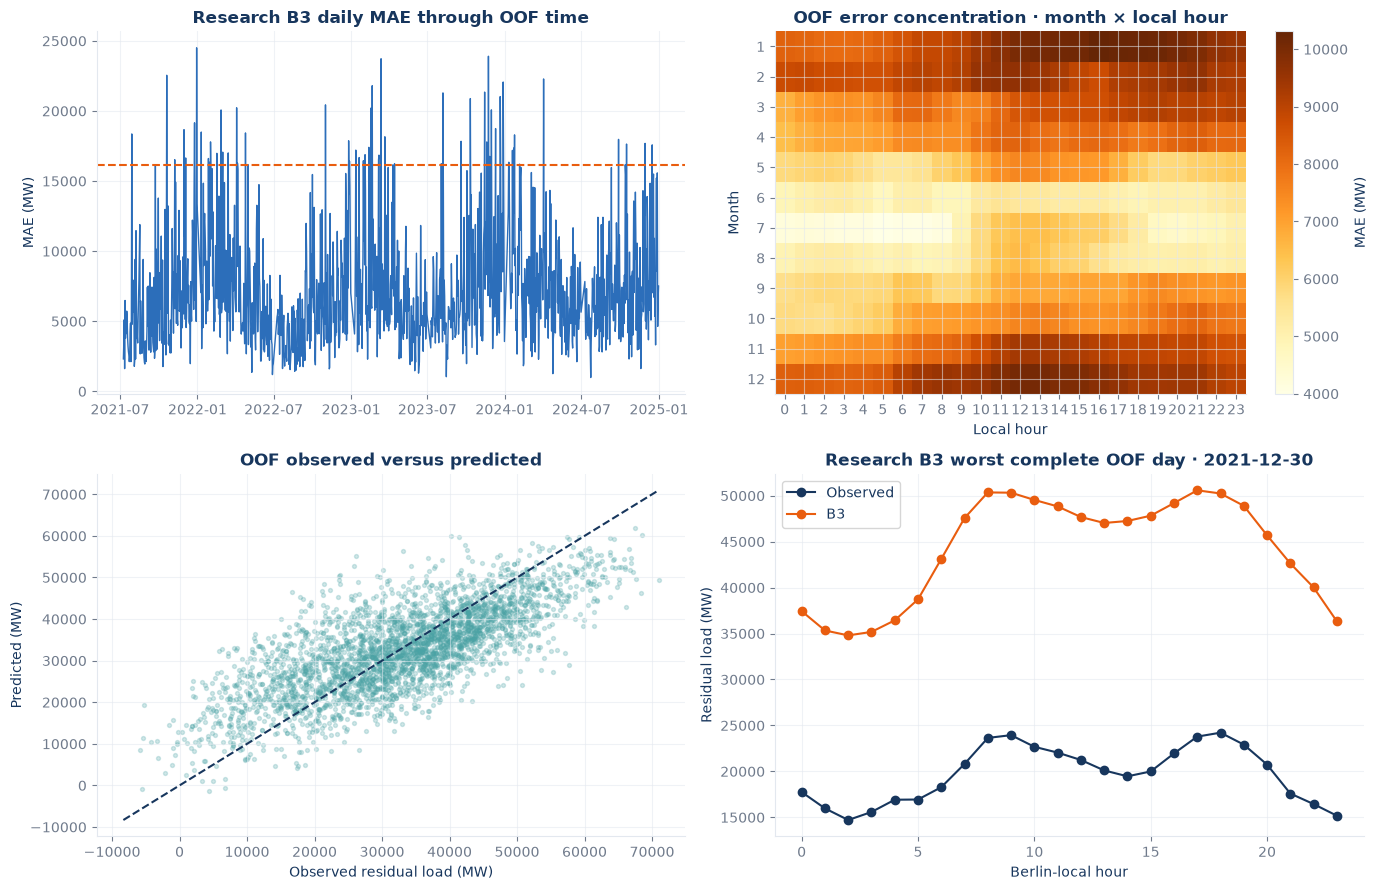

In [89]:
# -----------------------------------------------------------------
# Data provenance and loading
# -----------------------------------------------------------------
b3 = predictions.loc[predictions["model_id"].eq("B3_RIDGE")].copy()
b3["local_hour"] = b3["calendar_hour_raw"].astype(int)
month_hour_error = b3.pivot_table(
    index="calendar_month", columns="local_hour", values="absolute_error_mw", aggfunc="mean"
)
worst_day = daily_metrics.loc[
    daily_metrics["model_id"].eq("B3_RIDGE")
].sort_values("daily_mae_mw", ascending=False).iloc[0]
worst_profile = b3.loc[
    (b3["fold_id"].eq(worst_day["fold_id"]))
    & (pd.to_datetime(b3["target_date_local"]).eq(pd.Timestamp(worst_day["target_date_local"])))
].sort_values("target_time_utc")

fig, axes = plt.subplots(2, 2, figsize=(14, 9.0))
daily_b3 = daily_metrics.loc[daily_metrics["model_id"].eq("B3_RIDGE")].sort_values("target_date_local")
axes[0, 0].plot(daily_b3["target_date_local"], daily_b3["daily_mae_mw"], color=COLORS["blue"], linewidth=1)
axes[0, 0].axhline(daily_b3["daily_mae_mw"].quantile(.95), color=COLORS["orange"], linestyle="--")
axes[0, 0].set(title="Research B3 daily MAE through OOF time", ylabel="MAE (MW)")
image = axes[0, 1].imshow(month_hour_error.to_numpy(), aspect="auto", cmap="YlOrBr")
axes[0, 1].set(title="OOF error concentration · month × local hour", xlabel="Local hour", ylabel="Month",
               xticks=range(len(month_hour_error.columns)), xticklabels=month_hour_error.columns,
               yticks=range(len(month_hour_error.index)), yticklabels=month_hour_error.index)
fig.colorbar(image, ax=axes[0, 1], label="MAE (MW)")
axes[1, 0].scatter(b3["y_true_mw"].iloc[::max(1, len(b3)//3000)], b3["y_pred_mw"].iloc[::max(1, len(b3)//3000)],
                   s=8, alpha=.25, color=COLORS["teal"])
limits = [min(b3["y_true_mw"].min(), b3["y_pred_mw"].min()), max(b3["y_true_mw"].max(), b3["y_pred_mw"].max())]
axes[1, 0].plot(limits, limits, linestyle="--", color=COLORS["ink"])
axes[1, 0].set(title="OOF observed versus predicted", xlabel="Observed residual load (MW)", ylabel="Predicted (MW)")
axes[1, 1].plot(worst_profile["calendar_hour_raw"], worst_profile["y_true_mw"], marker="o", label="Observed", color=COLORS["ink"])
axes[1, 1].plot(worst_profile["calendar_hour_raw"], worst_profile["y_pred_mw"], marker="o", label="B3", color=COLORS["orange"])
axes[1, 1].set(title=f"Research B3 worst complete OOF day · {pd.Timestamp(worst_day['target_date_local']).date()}", xlabel="Berlin-local hour", ylabel="Residual load (MW)")
axes[1, 1].legend()
finish_figure(fig, "failure_observatory", "When, where, and how does the baseline fail?")

### Report official-forecast availability honestly

Inspect the stated units, time range and support before interpreting the resulting table or figure.

In [90]:
# -----------------------------------------------------------------
# Leakage-safe chronological validation
# -----------------------------------------------------------------
official_forecast_value_add = pd.DataFrame([
    {
        "benchmark": "B2_OFFICIAL_FORECAST",
        "status": official_forecast_status,
        "required": "valid_time + issued_at + vintage + immutable archive snapshot + external verification",
        "result": "not scored" if official_forecast_status != "QUALIFIED_OFFICIAL_FORECAST" else "qualified for OOF scoring",
    },
    {
        "benchmark": "B5_OFFICIAL_PLUS_RESIDUAL_CORRECTION",
        "status": official_forecast_status,
        "required": "B2 qualified; correction trained inside fold only",
        "result": "not scored" if official_forecast_status != "QUALIFIED_OFFICIAL_FORECAST" else "eligible",
    },
])
display(official_forecast_value_add)

,benchmark,status,required,result
0,B2_OFFICIAL_FORECAST,BLOCKED_OFFICIAL_FORECAST,valid_time + issued_at + vintage + immutable a...,not scored
1,B5_OFFICIAL_PLUS_RESIDUAL_CORRECTION,BLOCKED_OFFICIAL_FORECAST,B2 qualified; correction trained inside fold only,not scored


## Takeaways and interpretation checklist

This notebook is an **analysis workflow, not a prewritten finding**. Conclusions should be drawn from the executed fold tables, diagnostics, figures, and scientific audits.

The final section summarizes the evidence produced upstream; it does not recompute models, features, folds, thresholds, or scientific results.

| Evidence                                    | Permitted interpretation                                                                    | Not established                                                             |
| ------------------------------------------- | ------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------- |
| **Calendar representation race**            | Relative transfer performance under the declared chronological folds                        | A universally best time encoding                                            |
| **FFT / Welch / harmonic reconstruction**   | Periodic structure observed within past-data windows, including fitted amplitude and phase  | A forecast, causal mechanism, or automatically admitted predictive feature  |
| **Strict spectral / control timing tests**  | Event-time eligibility under the stated information and latency assumptions                 | Historically archived vintages or independently verified true release times |
| **B3–B1 paired daily comparison**           | Fold-specific forecast improvement with block-bootstrap uncertainty                         | Generalization to unscored 2025–2026 data or an untouched confirmatory test |
| **C0 / C1 / C2 and separate tail heads**    | Discrimination, calibration, and frozen-threshold operating behaviour                       | A guaranteed alert budget or a grid-security intervention                   |
| **Feature-family ladder and B3 importance** | Conditional predictive value under the named model, validation design, and feature ordering | Physical, mechanistic, or interventional causality                          |

### How to interpret a failed gate

If a scientific gate fails, inspect the **first failing section** and its associated source, timing, coverage, support, and availability audit.

**Do not relax scientific checks merely to make the notebook green.**

A smoke run cannot promote a feature. A synthetic verification run establishes **software behaviour only**; it does not constitute empirical GridStress evidence.

A real-data research run should be regarded as completed only when the executed notebook identifies the real input provenance and hash, reports the completed chronological folds, and preserves the relevant validation and leakage evidence.

### Reading the final summary

The final research-summary cell is intentionally **descriptive rather than computational**. Use it to confirm:

* which data mode and run were executed;
* the observation count and temporal coverage;
* the forecast-origin contract;
* which chronological folds were executed;
* whether the event-time leakage checks passed;
* the revision-vintage status;
* the amount of feature/model evidence produced;
* regression and classification out-of-fold alignment;
* and which figures or explanatory animations were registered.

The detailed scientific evidence remains in the corresponding upstream sections of the notebook.

### API references checked during this rework

The supplied notebook remains the source for the scientific scope and feature-family definitions. The external references below support **API compatibility, numerical implementation, or estimator usage only**; they do not provide empirical evidence for the GridStress conclusions.

* **pandas time-series guide** — datetime/time-series behaviour and compatibility:
  https://pandas.pydata.org/docs/user_guide/timeseries.html

* **pandas `DatetimeIndex.as_unit`** — datetime unit conversion:
  https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.as_unit.html

* **NumPy `rfft`** — real-input discrete Fourier transform:
  https://numpy.org/doc/stable/reference/generated/numpy.fft.rfft.html

* **SciPy `median_abs_deviation`** — robust dispersion estimator:
  https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.median_abs_deviation.html

* **scikit-learn common pitfalls** — preprocessing, pipelines, and data-leakage guidance:
  https://scikit-learn.org/stable/common_pitfalls.html

Existing source URLs in the intervention ledger are retained from the supplied notebook. Exact historical announcement times, release times, and vintage metadata have **not been independently verified by this rework**.

### Interpretation boundary

Treat observations, reconstructions, forecasts, classifications, and interventions as distinct forms of evidence.

A visually strong pattern is not automatically predictive. Predictive improvement is not automatically causal. Classification performance is not an operational intervention. Feature importance is conditional on the model and experimental design.

The notebook should therefore be read from **evidence → validation → interpretation**, rather than from an expected conclusion backward.
